Here, you develop the 

In [2]:
import os.path
from scipy import *
import numpy as np
from numpy import *
from numpy import linalg as LA
from scipy import linalg as LA2
import sympy as sympy
import sys as sys
import time
import matplotlib.pyplot as plt
import itertools as it
from IPython.core.display import HTML


sys.path.append('/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/')
from Modules import BasicTools as BT
from Modules import WaveTools as WT
from Modules import PlotTools as PT
from Modules import FFTTools as FFTT
from Modules import OperatorTools as OT
from Modules import GridTransferTools as GTT
from Modules import TestTools as TT
from Modules import SolverTools as ST
from Modules import WaveformTools as WFT

display(HTML("<style>pre { white-space: pre !important; }</style>"))
np.set_printoptions( linewidth = 10000, threshold = 100000)

In [3]:
ceqSwitch = 'c1neqc2'
contSwitch = 'cont'
IRT = 'IRT'
derivative = False
BooleAve = False
field = 'EB'
WaveFunc = WFT.Gauss
appendage = '-' + ceqSwitch + '-' + contSwitch + '-' + IRT

if (ceqSwitch == 'c1eqc2'):
    val2 = 1
else:
    val2 = 0.25

if (contSwitch == 'cont'):
    plotCont = True
else:
    plotCont = False

In [4]:
nh_min = 64
refRatio = 2
CFL = np.sqrt(0.5)
x_0 = 0.
x_1 = 0.5
Hans = False

deriv = 'UD'
RK = 1
order = 1

L = 1.
locs = [x_1]
epsilons = [1, val2]# 11.68]
mus = [1, 1]#0.99837]



Inititialize `Grid` objects on coarse, fine, and AMR grid.

In [6]:
omegaAMR = BT.Grid(nh_min)
refCells = nh_min // 2
finepart = list(np.arange(refCells) + int(nh_min // 4))
omegaAMR.AddPatch(refRatio, finepart)
degFreed = omegaAMR.degFreed
nh_max = omegaAMR.nh_max

omegaF = BT.Grid(nh_max)
omegaC = BT.Grid(nh_min)

Inititialize `PhysProps` objects on coarse, fine, and AMR grid.

In [8]:
physicsAMR = BT.PhysProps(omegaAMR, epsilons, mus, locs, L)
cVecAMR = physicsAMR.cVec
cMatAMR = physicsAMR.cMat
csAMR = physicsAMR.cs

physicsC = BT.PhysProps(omegaC, epsilons, mus, locs, L)
cVecC = physicsC.cVec
cMatC = physicsC.cMat
csC = physicsC.cs

physicsF = BT.PhysProps(omegaF, epsilons, mus, locs, L)
cVecF = physicsF.cVec
cMatF = physicsF.cMat
csF = physicsF.cs

c1 = csAMR[0]
c2 = csAMR[-1]

Harvesting values and creating operators.

In [10]:
# c = ConvertParams(permitivity, permeability, L)
# t, nt = ST.CalcTime(omegaC, CFL, csAMR[0], nt = nt) # CHANGE BACK TO OMEGAAMR!!!
sigma, mu = WFT.GaussParams(x_0, x_1)
wavesAMR = WT.MakeWaves(omegaAMR)
nullspace = OT.FindNullspace(omegaAMR, wavesAMR, Hans = Hans)
restrictOp = GTT.CoarsenOp(omegaAMR)

wavesF = WT.MakeWaves(omegaF)
wavesC = WT.MakeWaves(omegaC)

if (field == 'EB'):
    wavesC = OT.Block(wavesC, var = 2)
    wavesF = OT.Block(wavesF, var = 2)
    wavesAMR = OT.Block(wavesAMR, var = 2)
    nullspace = OT.Block(nullspace, var = 2)
    restrictOp = OT.Block(restrictOp, var = 2)


# derivMat = TT.ExactSpatOp(omegaAMR)
# spatOp = -cMatF @ derivMat
# timePropOp = LA2.expm(t * spatOp)

# derivMatC = TT.ExactSpatOp(omegaC)
# spatOpC = -cMatC @ derivMatC
# timePropOpC = LA2.expm(t * spatOpC)

# opC = -cMatC @ OT.SpaceDeriv(omegaC, order, diff)
# opF = -cMatF @ OT.SpaceDeriv(omegaF, order, diff)
# opAMR = -cMatAMR @ OT.SpaceDeriv(omegaAMR, order, diff)

hC = np.concatenate((omegaC.h, omegaC.h))
hF = np.concatenate((omegaF.h, omegaF.h))
hAMR = np.concatenate((omegaAMR.h, omegaAMR.h))

degHalfC = int(nh_min / 2)
degHalfAMR = int(degFreed / 2)
degHalfF = int(nh_max / 2)

epsVecC = np.ones(nh_min, float)
epsVecAMR = np.ones(degFreed, float)
epsVecF = np.ones(nh_max, float)

epsVecC[:degHalfC] = epsilons[0]
epsVecC[degHalfC:] = epsilons[1]
epsVecF[:degHalfF] = epsilons[0]
epsVecF[degHalfF:] = epsilons[1]
epsVecAMR[:degHalfAMR] = epsilons[0]
epsVecAMR[degHalfAMR:] = epsilons[1]

muVecC = np.ones(nh_min, float)
muVecAMR = np.ones(degFreed, float)
muVecF = np.ones(nh_max, float)

muVecC[:degHalfC] = 1. / mus[0]
muVecC[degHalfC:] = 1. / mus[1]
muVecF[:degHalfF] = 1. / mus[0]
muVecF[degHalfF:] = 1. / mus[1]
muVecAMR[:degHalfAMR] = 1. / mus[0]
muVecAMR[degHalfAMR:] = 1. / mus[1]

muepsC = np.concatenate((epsVecC, muVecC))
muepsF = np.concatenate((epsVecF, muVecF))
muepsAMR = np.concatenate((epsVecAMR, muVecAMR))



print(muepsC)
print('')


[1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.  ]



Initialize waveform.

In [12]:
# # For Gaussian:
# waveInitC = WFT.Gauss(omegaC, physicsC, sigma, mu, BooleAve = False, deriv = False, cellAve = True)
# waveInitF = WFT.Gauss(omegaF, physicsF, sigma, mu)
args = [sigma, mu] # , 40]
waveInitC = WFT.InitCond(omegaC, physicsC, WaveFunc, args, deriv = derivative, BooleAve = BooleAve, field = field)
waveInitF = WFT.InitCond(omegaF, physicsF, WaveFunc, args, deriv = derivative, BooleAve = BooleAve, field = field)
waveInitAMR = WFT.InitCond(omegaAMR, physicsAMR, WaveFunc, args, deriv = derivative, BooleAve = BooleAve, field = field)
print(waveInitC)
print(len(waveInitC))
print('')
# waveInitF = np.append(waveInitF, waveInitF)
FCoefsC = FFTT.FourierCoefs(wavesC, waveInitC)
FCoefsF = FFTT.FourierCoefs(wavesF, waveInitF)
FCoefsC1 = np.asarray(np.append(FCoefsC, FCoefsC))


YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False

[1.26435239e-13 5.18717204e-12 1.65713344e-10 4.12869559e-09 8.02376578e-08 1.21658742e-06 1.43945561e-05 1.32932952e-04 9.58371531e-04 5.39493064e-03 2.37173981e-02 8.14420884e-02 2.18471186e-01 4.57883740e-01 7.49847100e-01 9.59565043e-01 9.59565043e-01 7.49847100e-01 4.57883740e-01 2.18471186e-01 8.14420884e-02 2.37173981e-02 5.39493064e-03 9.58371531e-04 1.32932952e-04 1.43945561e-05 1.21658742e-06 8.02376578e-08 4.12869559e-09 1.65713344e-10 5.18717204e-12 1.26435239e-13 2.49543235e-15 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.0000

If\
$u (x, 0) = \sum_{k = 0} a_{k} e^{2 \pi i k x}$,\
then the propagated incoming part of the wave is\
$u_{I} (x, t) = \sum_{k = 0} a_{k} e^{2 \pi i k (x - c_{1} t)} \Theta (x_{s} - x)$,\
and the reflected part of the wave is\
$u_{R} (x, t) = \frac{c_{2} - c_{1}}{c_{1} + c_{2}} \sum_{k = 0} a_{k} e^{2 \pi i k (2 x_{s} - x - c_{1} t)} \Theta (x_{s} - x)$.\
Thus, we can just multiply the original coefficients by an operator which contains the waves $e^{2 \pi i k (x - c_{1} t)}$ in the region of the first medium for the propagated wave and the waves $e^{2 \pi i k (2 x_{s} - x - c_{1} t)}$ in the region of the first medium for the reflected wave. This operator is zero in the region of the second medium.\
\
For the transmitted portion, I used $x'$ derived from the Method of Characteristics,\
$x'(x, t) = (x - c_{1} t) \Theta (x_{s} - x) + \frac{c_{1} (x - c_{2} t) + (c_{2} - c_{1}) x_{s}}{c_{2}} \Theta (x - x_{s}) \Theta (x_{s} + c_{2} t - x) + (x - c_{2} t) \Theta [x - (x_{s} + c_{2} t)]$,\
and plugged it into the initial wave like so:\
$u_{T} (x, t) = \frac{2 c_{1}}{c_{1} + c_{2}} u [x' (x, t), 0] \Theta (x - x_{s})$.\
The scaling factor out front is semi-derived, semi-guess. The value I derived that it should have been was $\frac{2 c_{2}}{c_{1} + c_{2}}$, but changing the numerator to $c_{1}$ made the wave look more continuous for some reason.


In [14]:
cs = physicsF.cs
t_snaps = 8
t_f = (0.25 / cs[0]) + (0.25 / cs[1])
t = 0
i = 0

ntVec = []#np.arange(iters) + 1
EVecCAnal = []#np.zeros(iters, float)
EVecAMRAnal = []#np.zeros(iters, float)
EVecFAnal = []#np.zeros(iters, float)
EVecCSolv = []#np.zeros(iters, float)
EVecAMRSolv = []#np.zeros(iters, float)
EVecFSolv = []


This is what's happening.
BEFORE: t = 0.0

YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False

AFTER: t = 0.0

BEFORE: t = 0.0027621358640099515

YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False

You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
AFTER: t = 0.0027621358640099515

BEFORE: t = 0.005524271728019903

YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False

You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
AFTER: t = 0.005524271728019903

BEFORE:

/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Modules/PlotTools.py:699: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize = size)


AFTER: t = 0.16572815184059708

BEFORE: t = 0.16849028770460703

YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False

You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqR

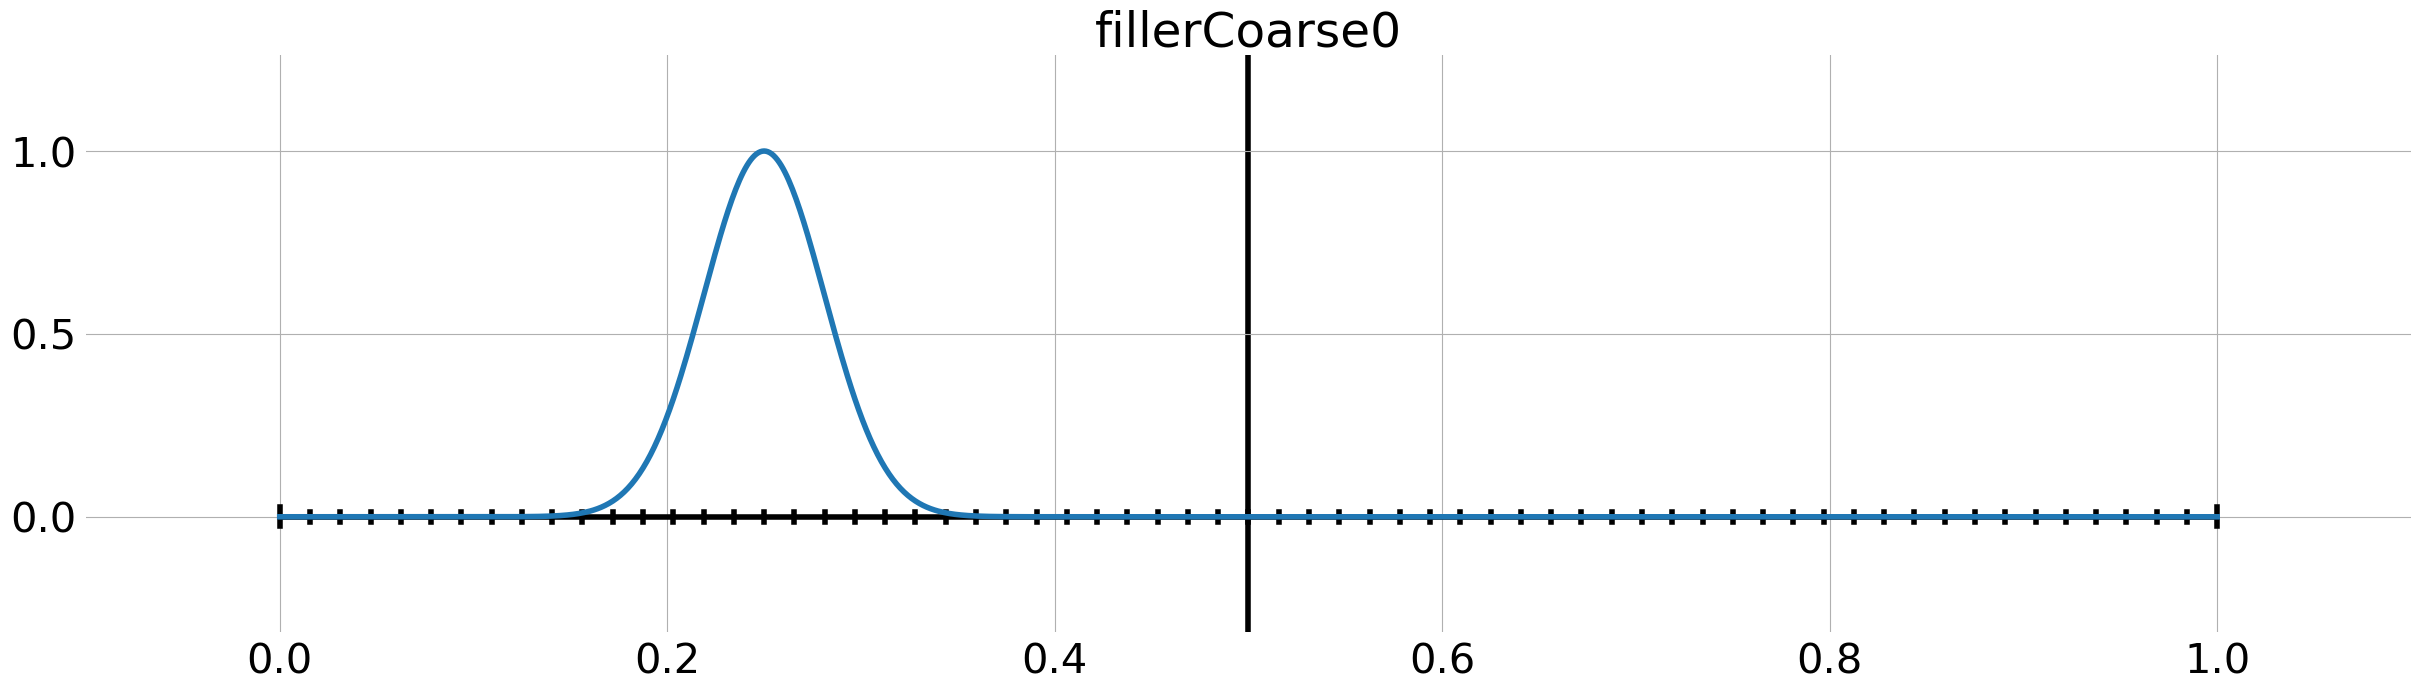

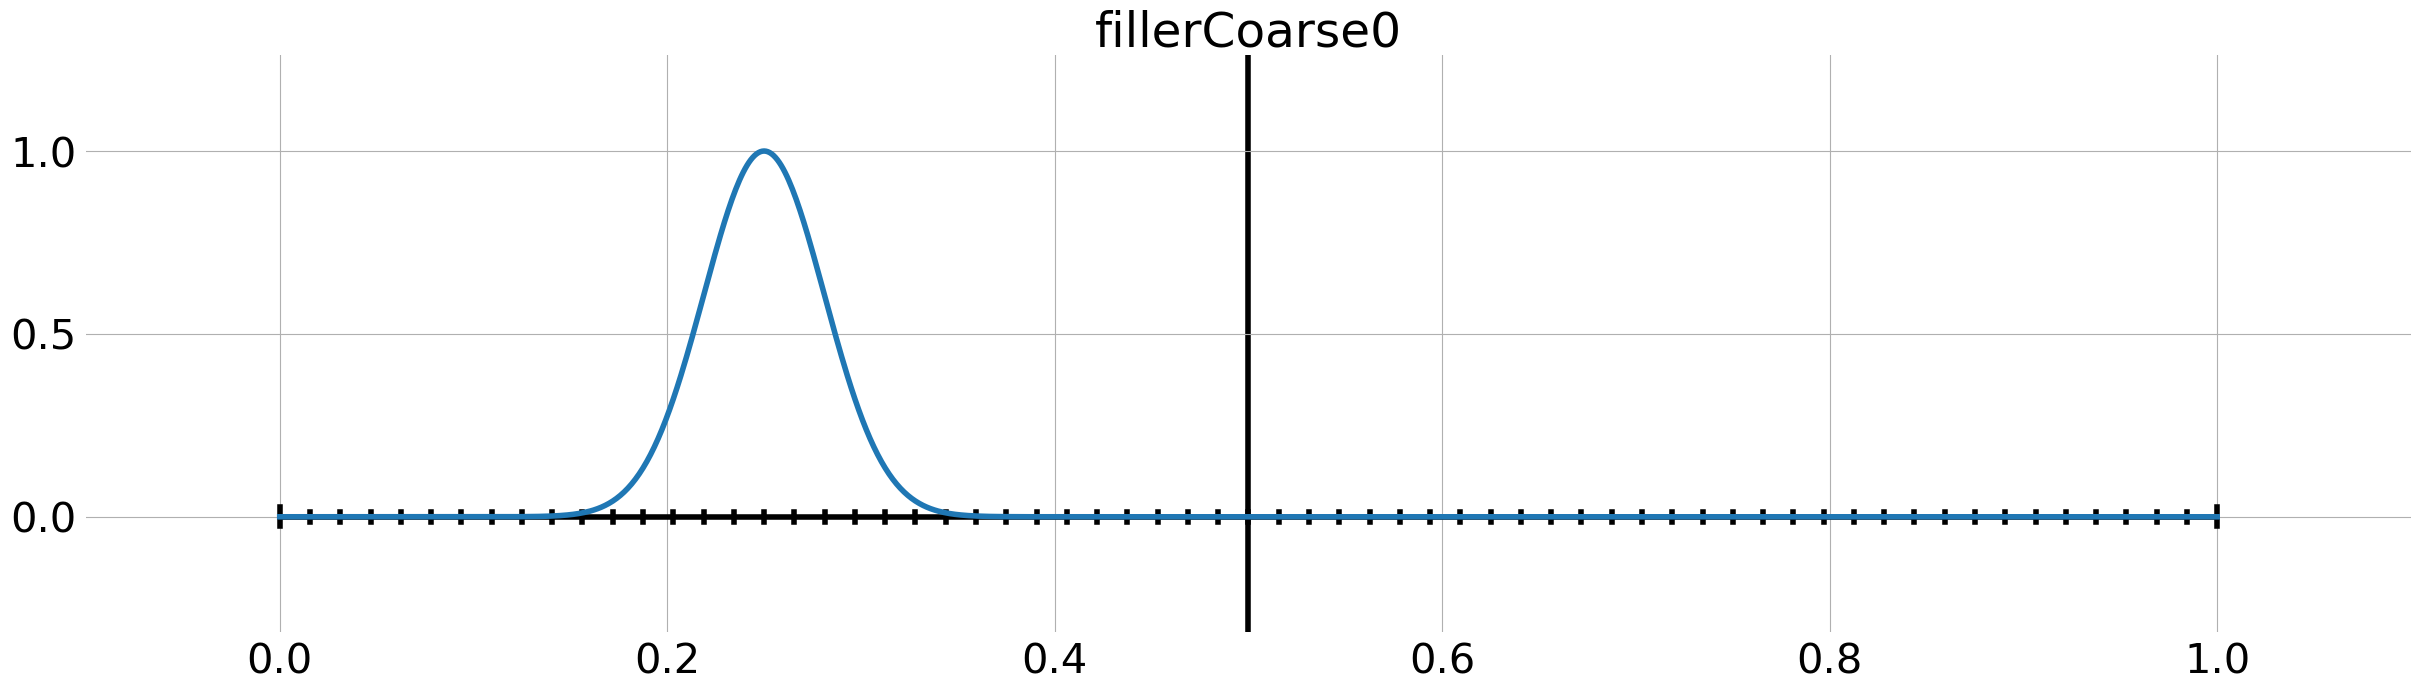

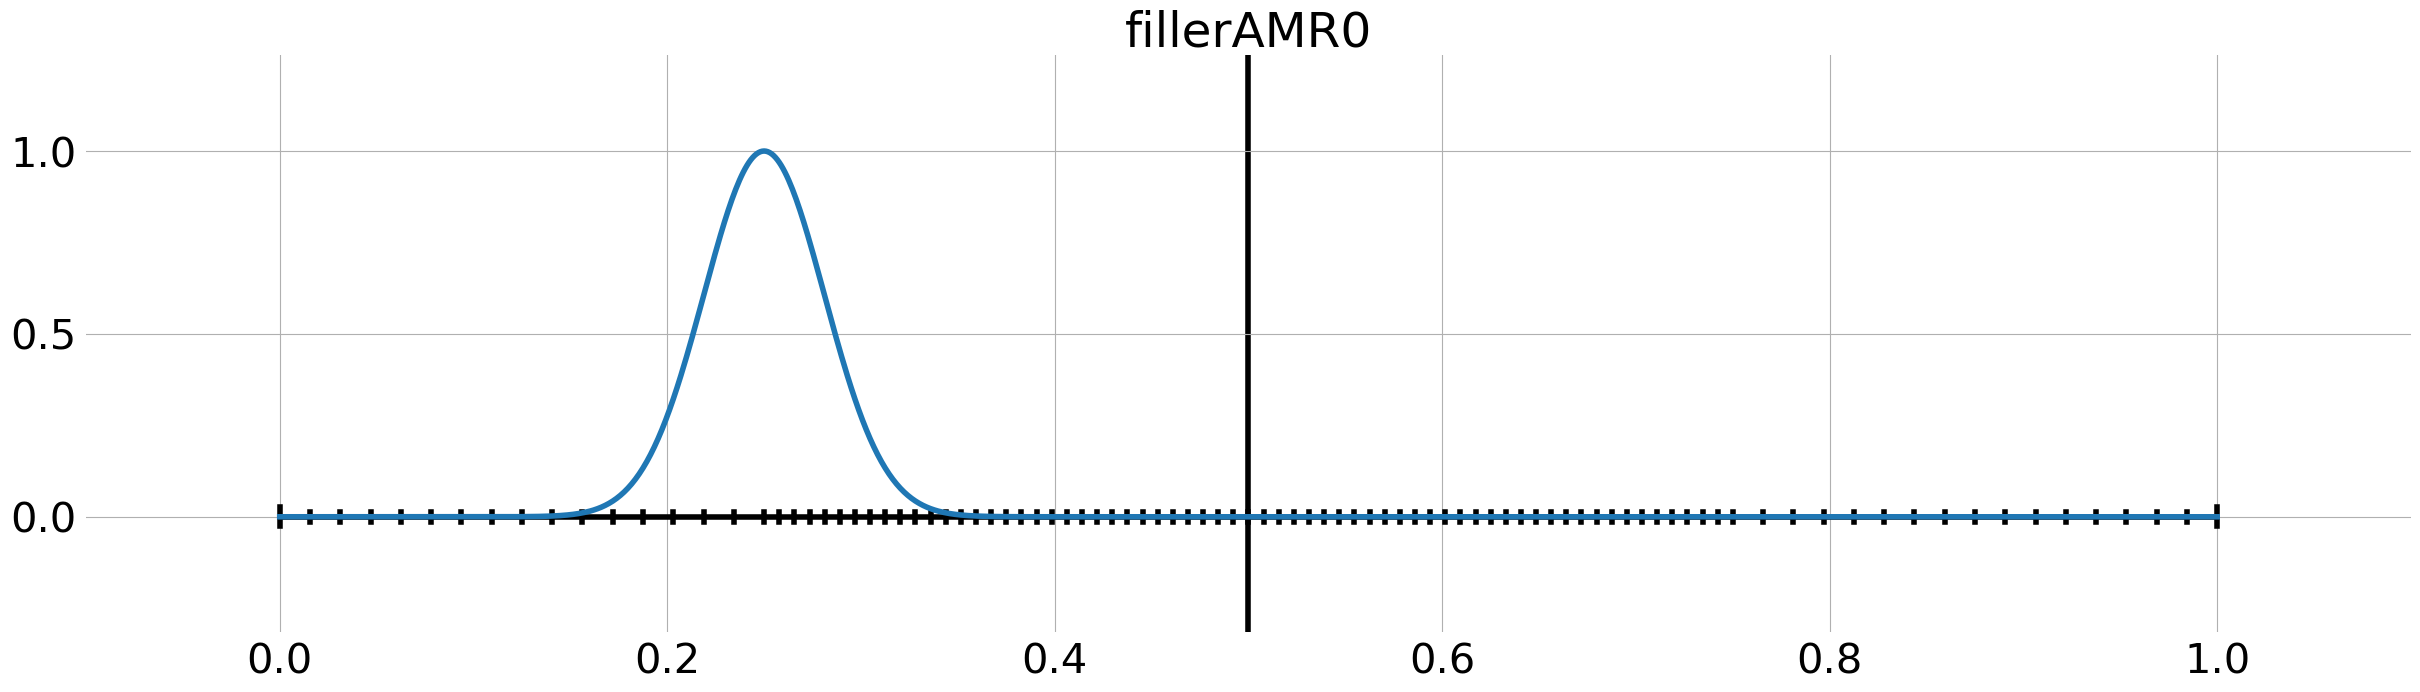

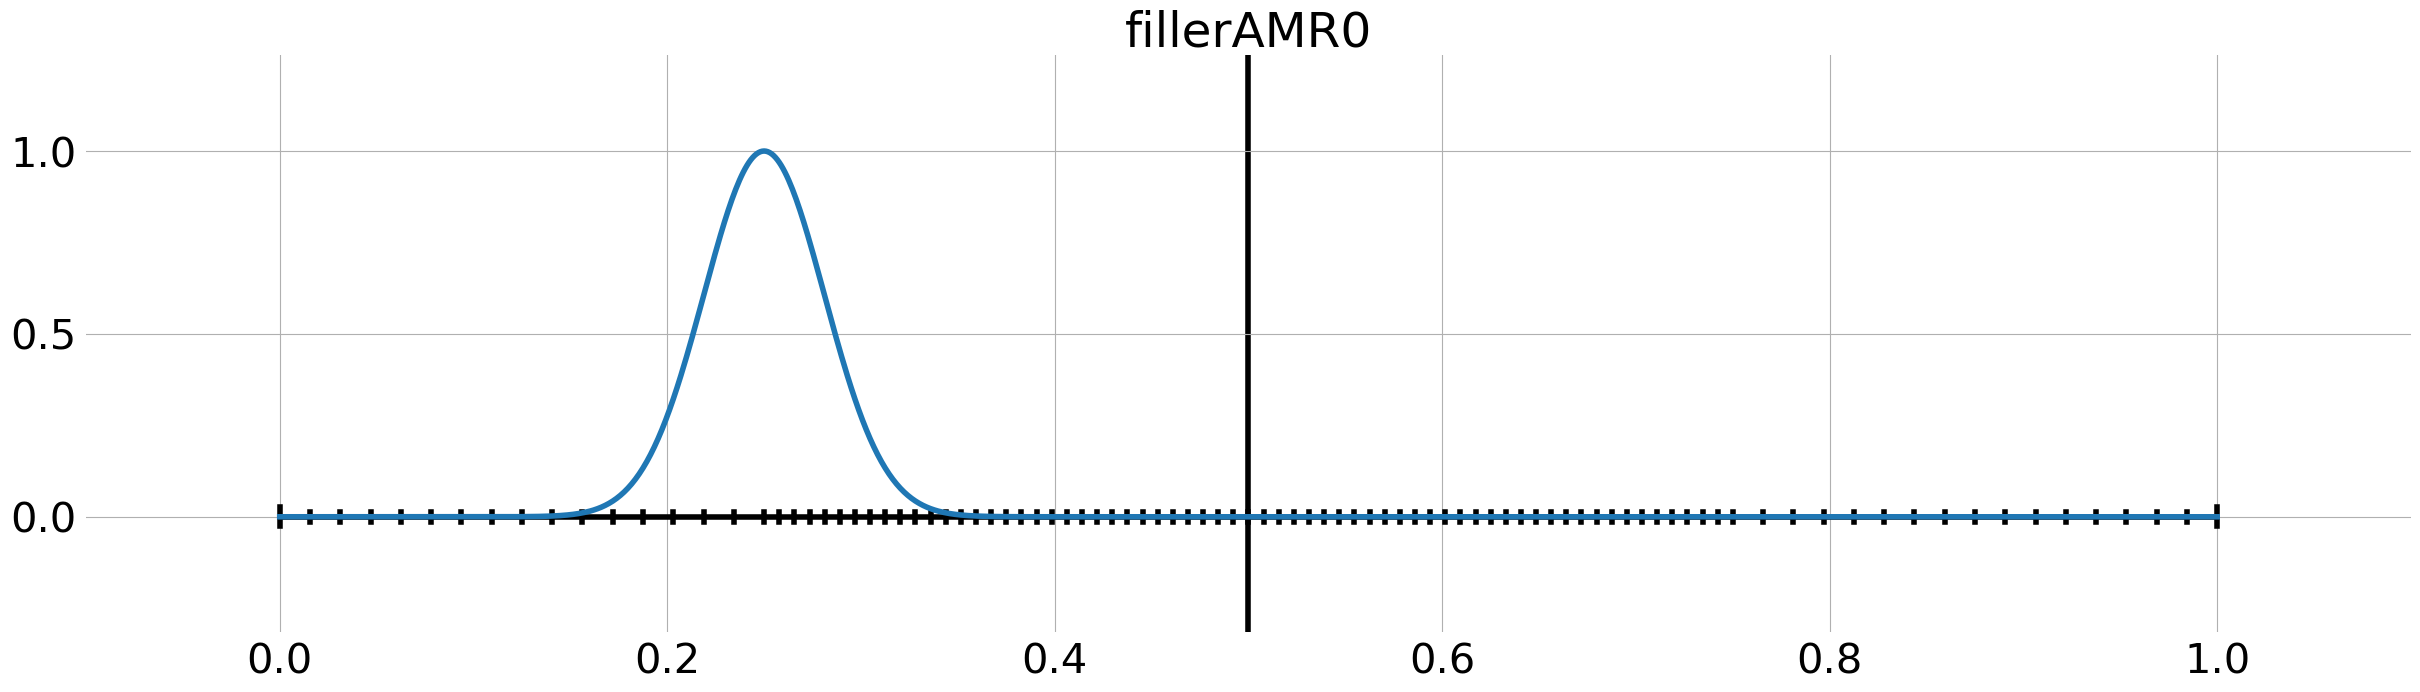

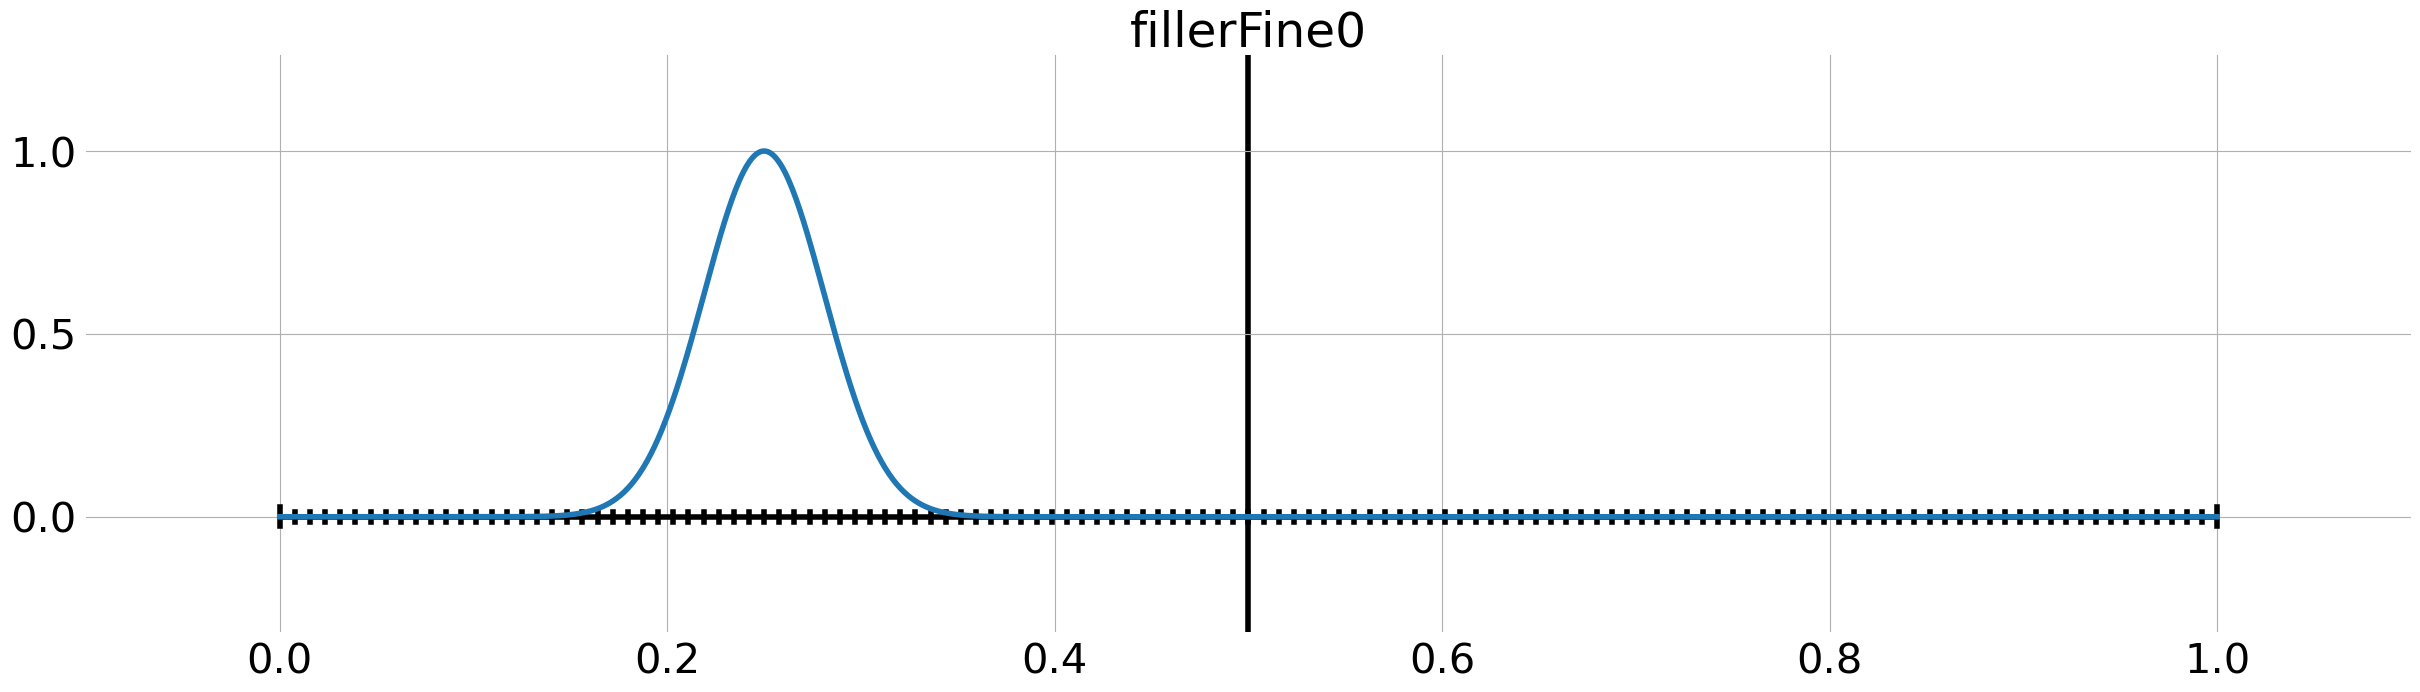

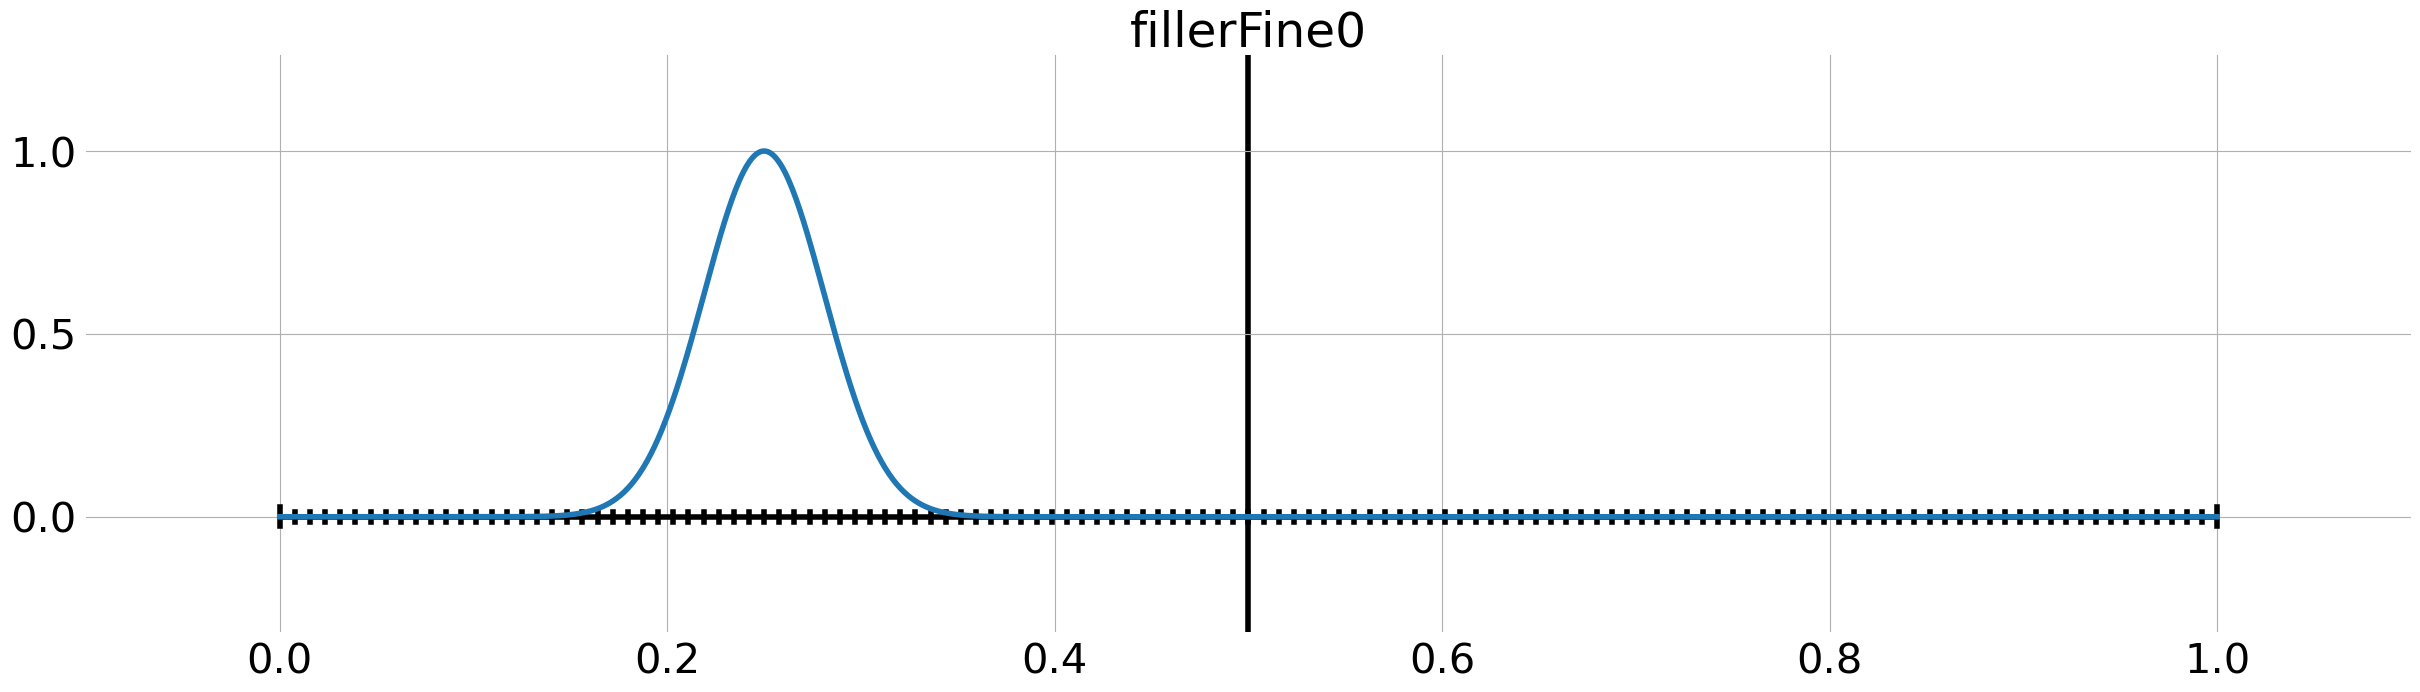

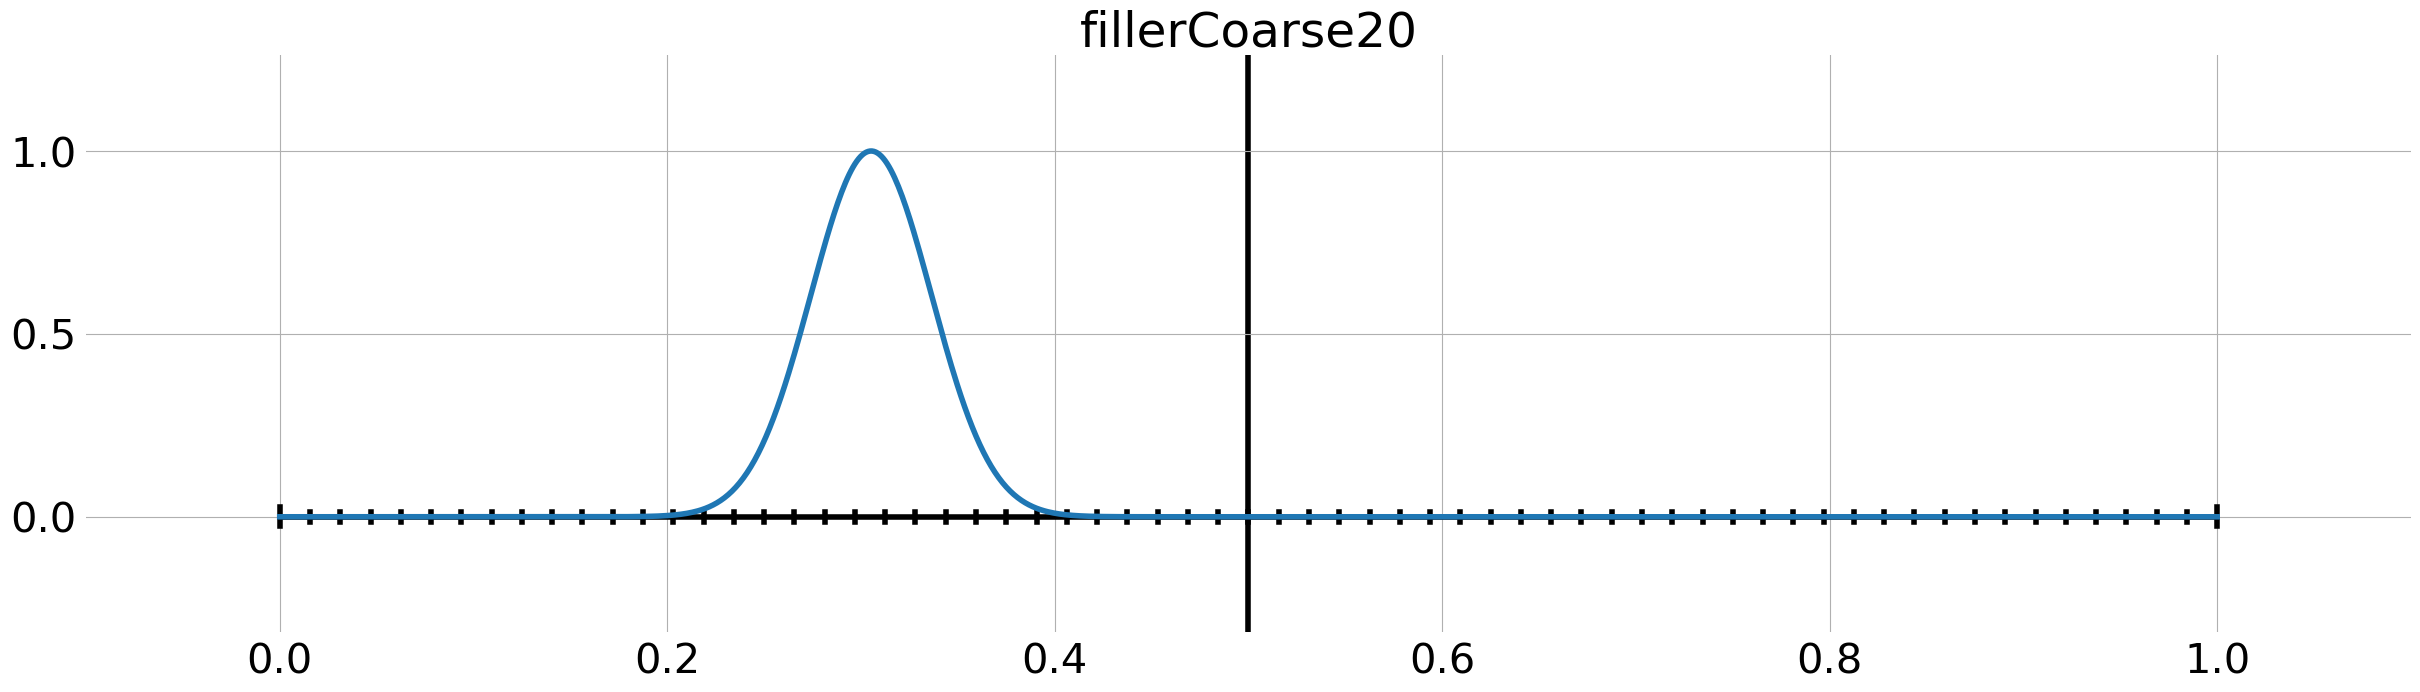

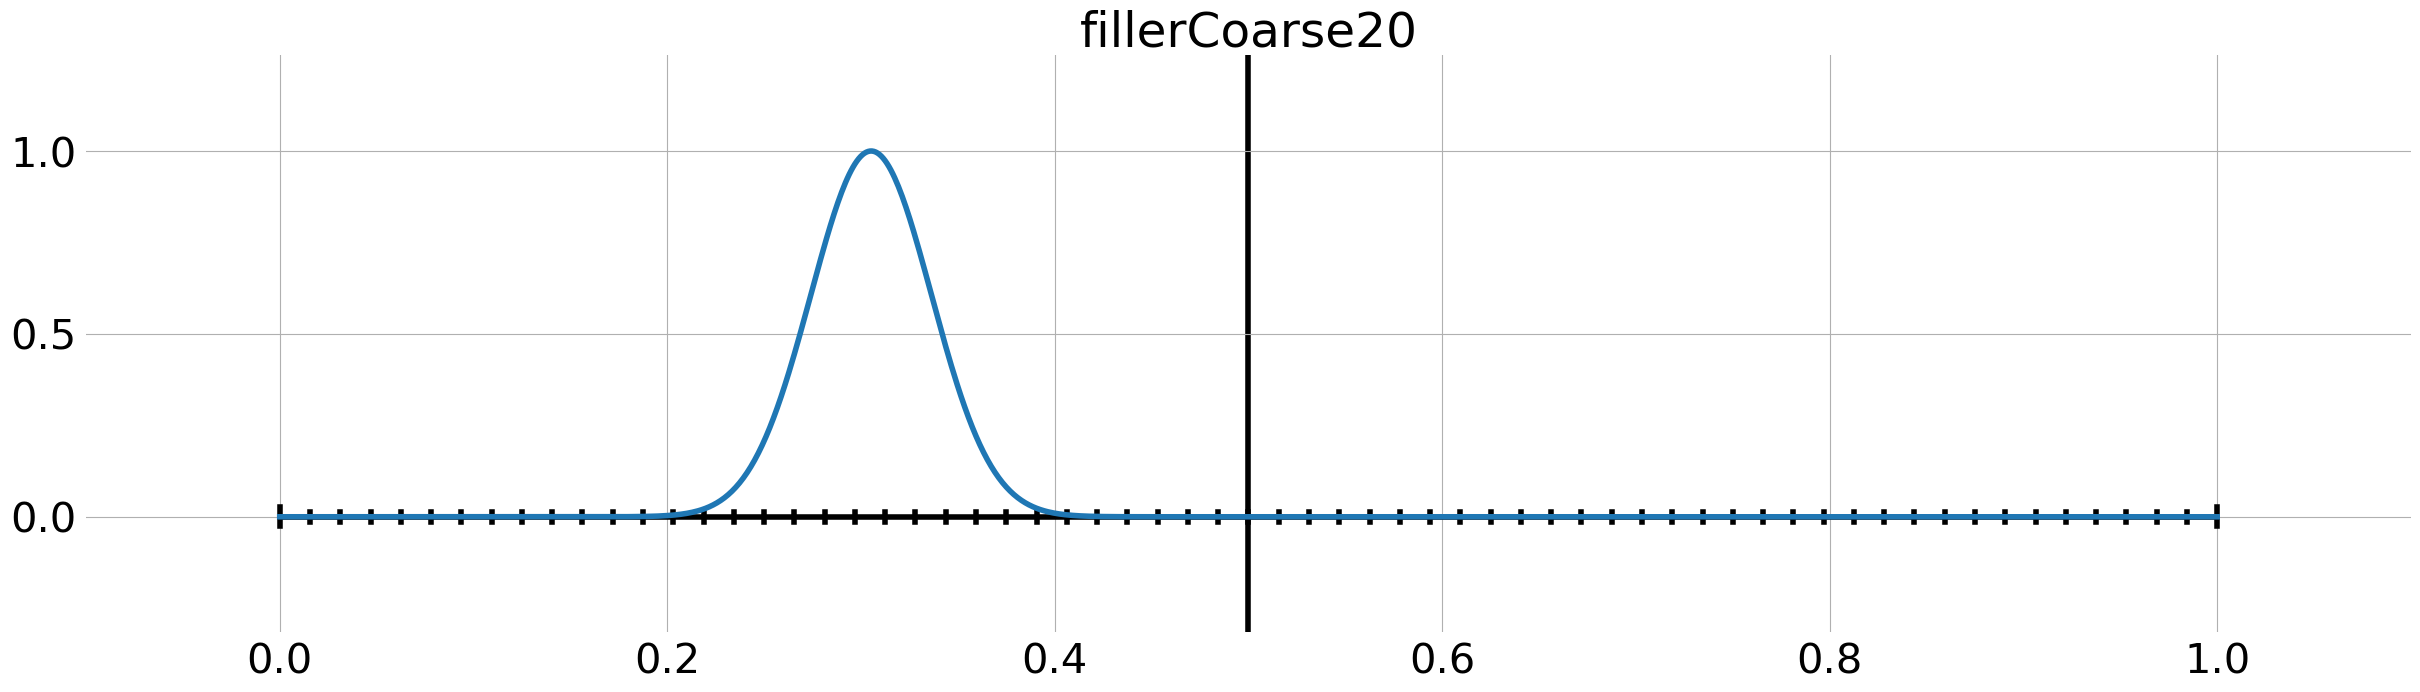

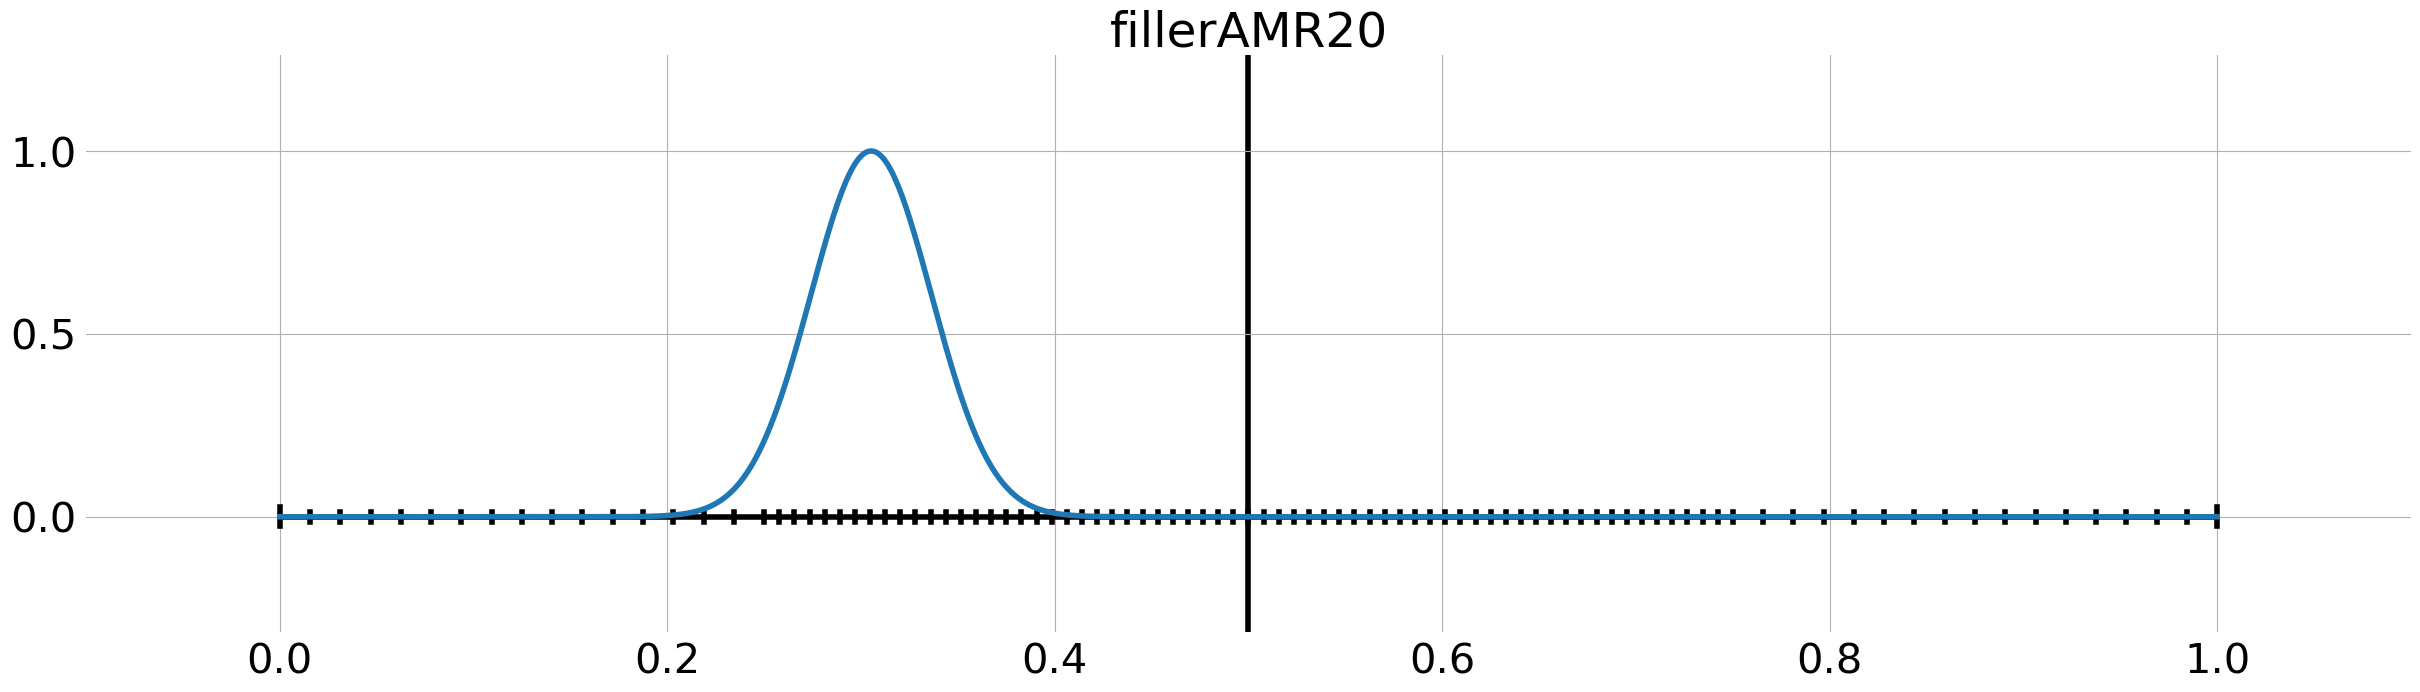

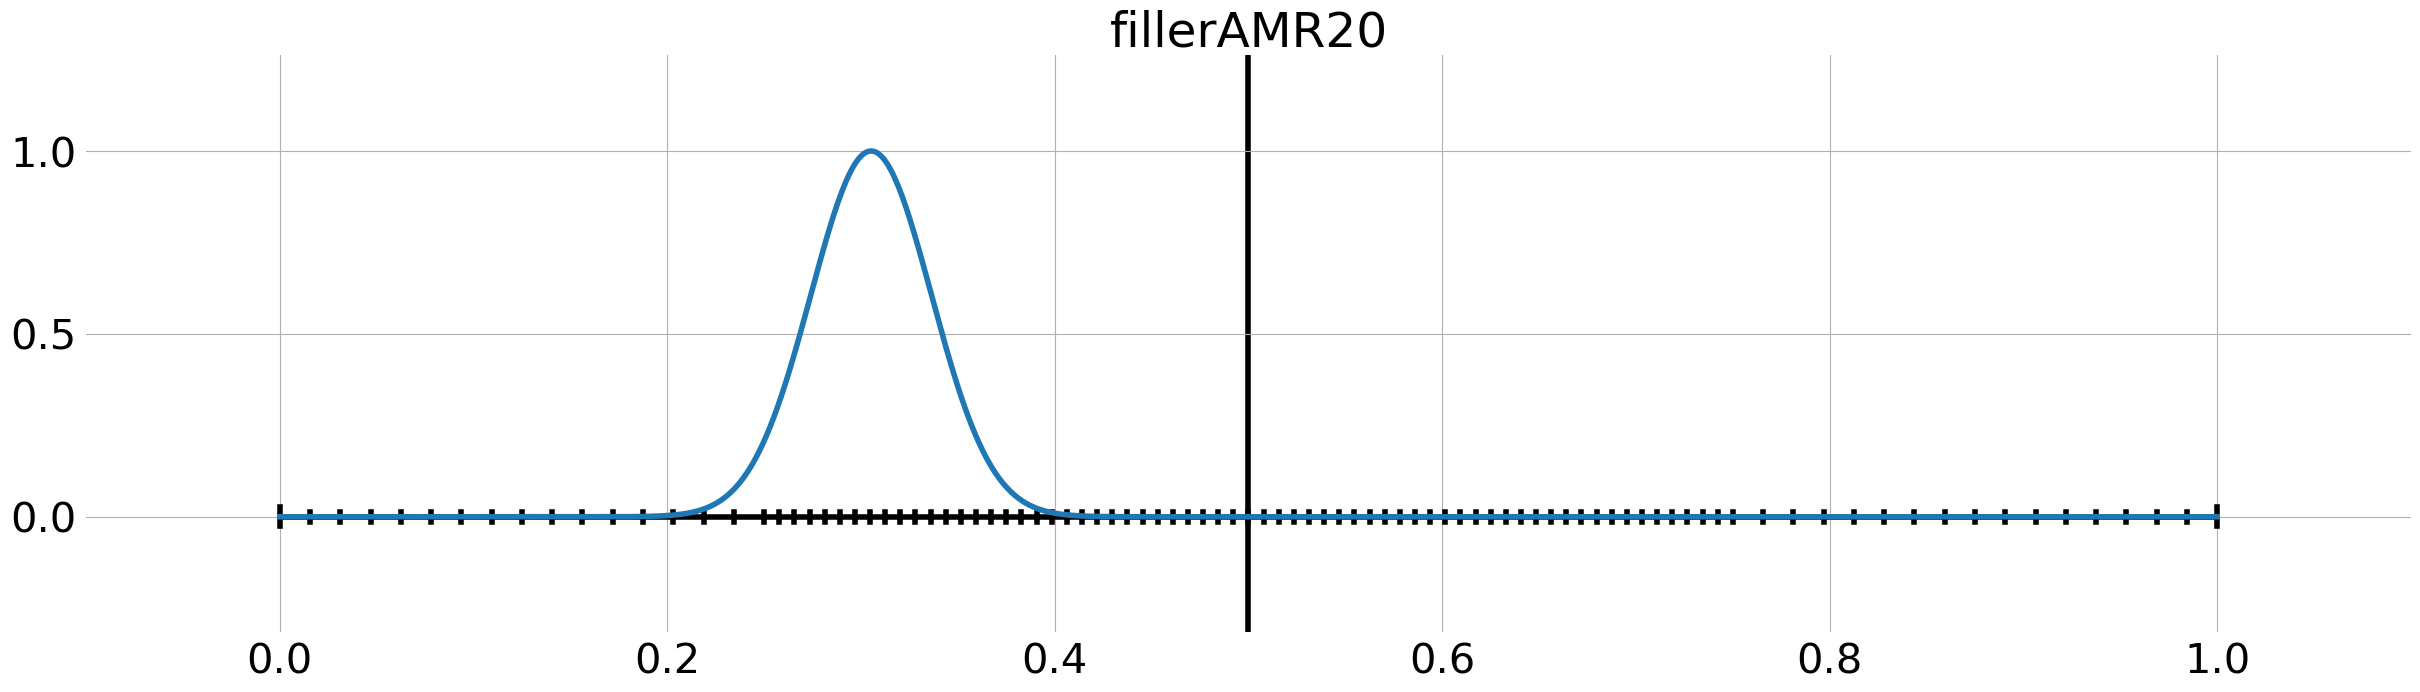

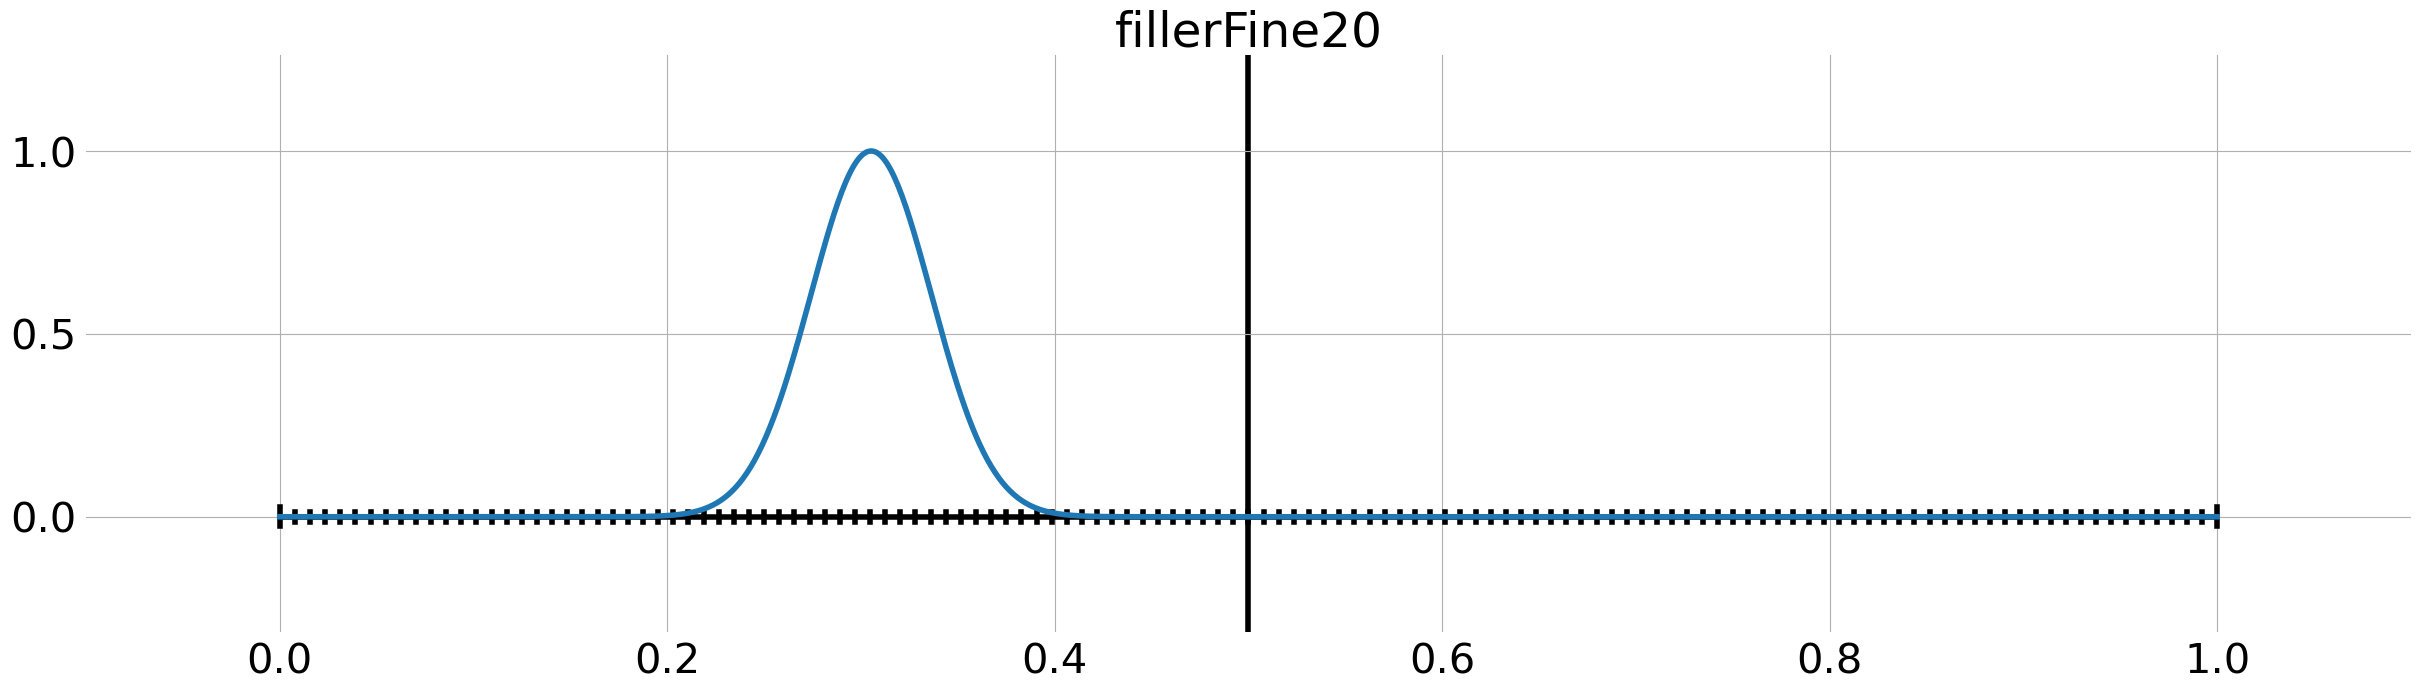

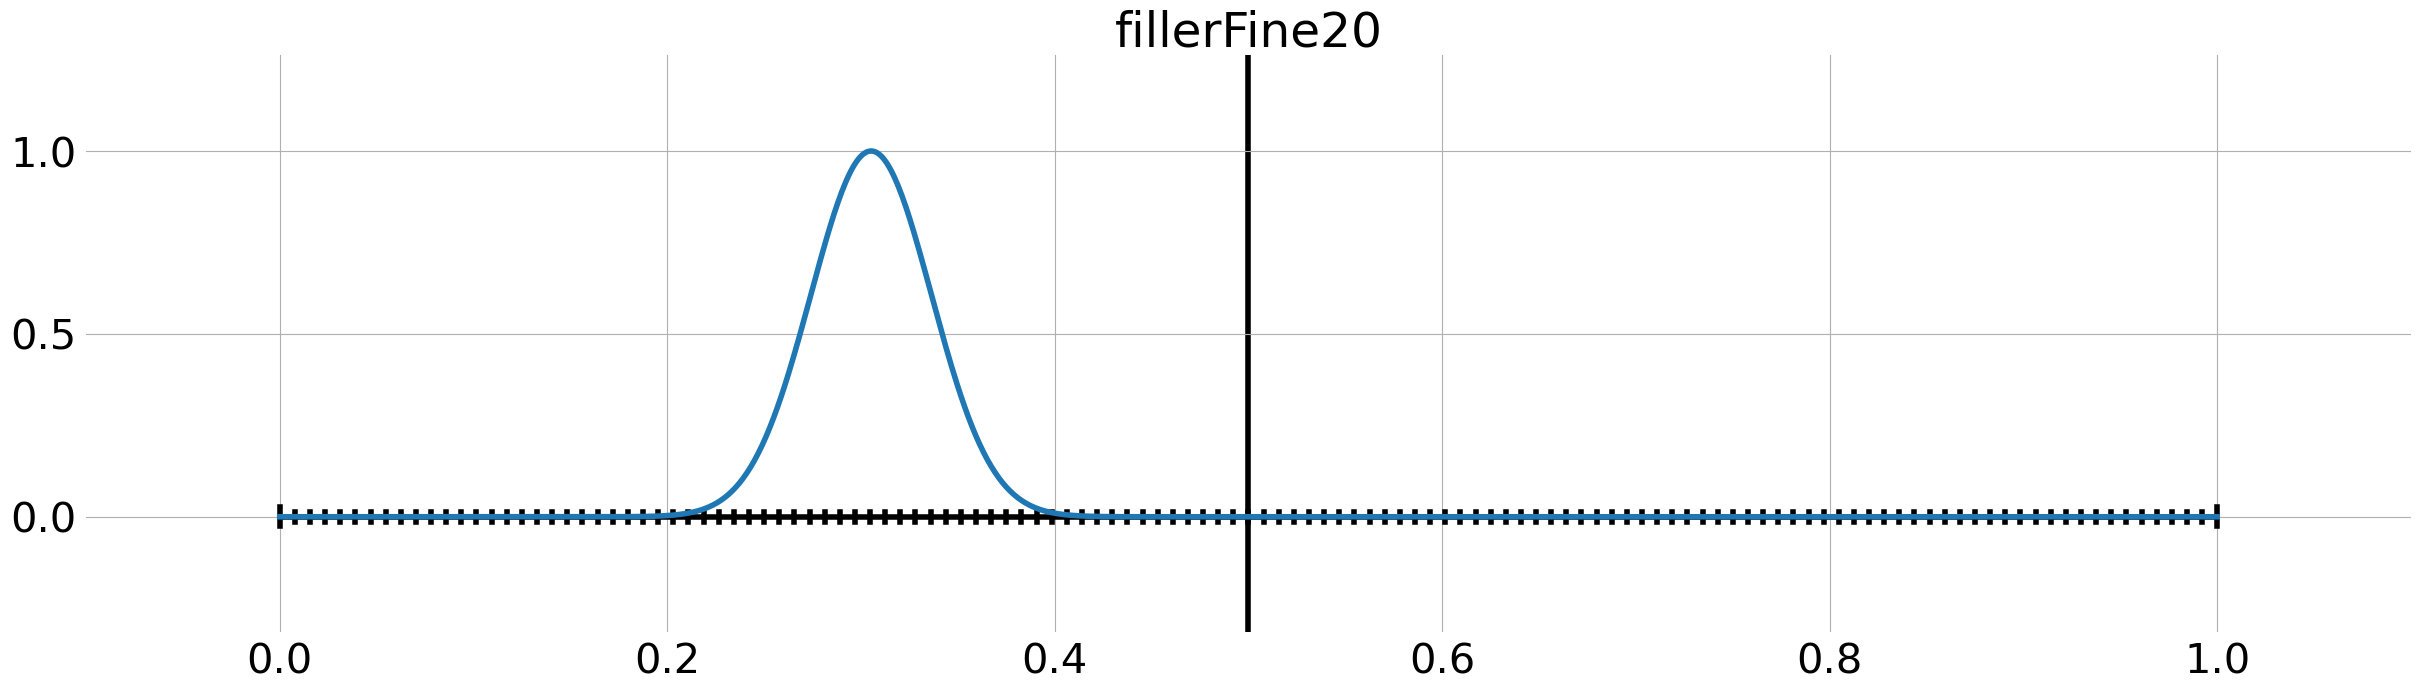

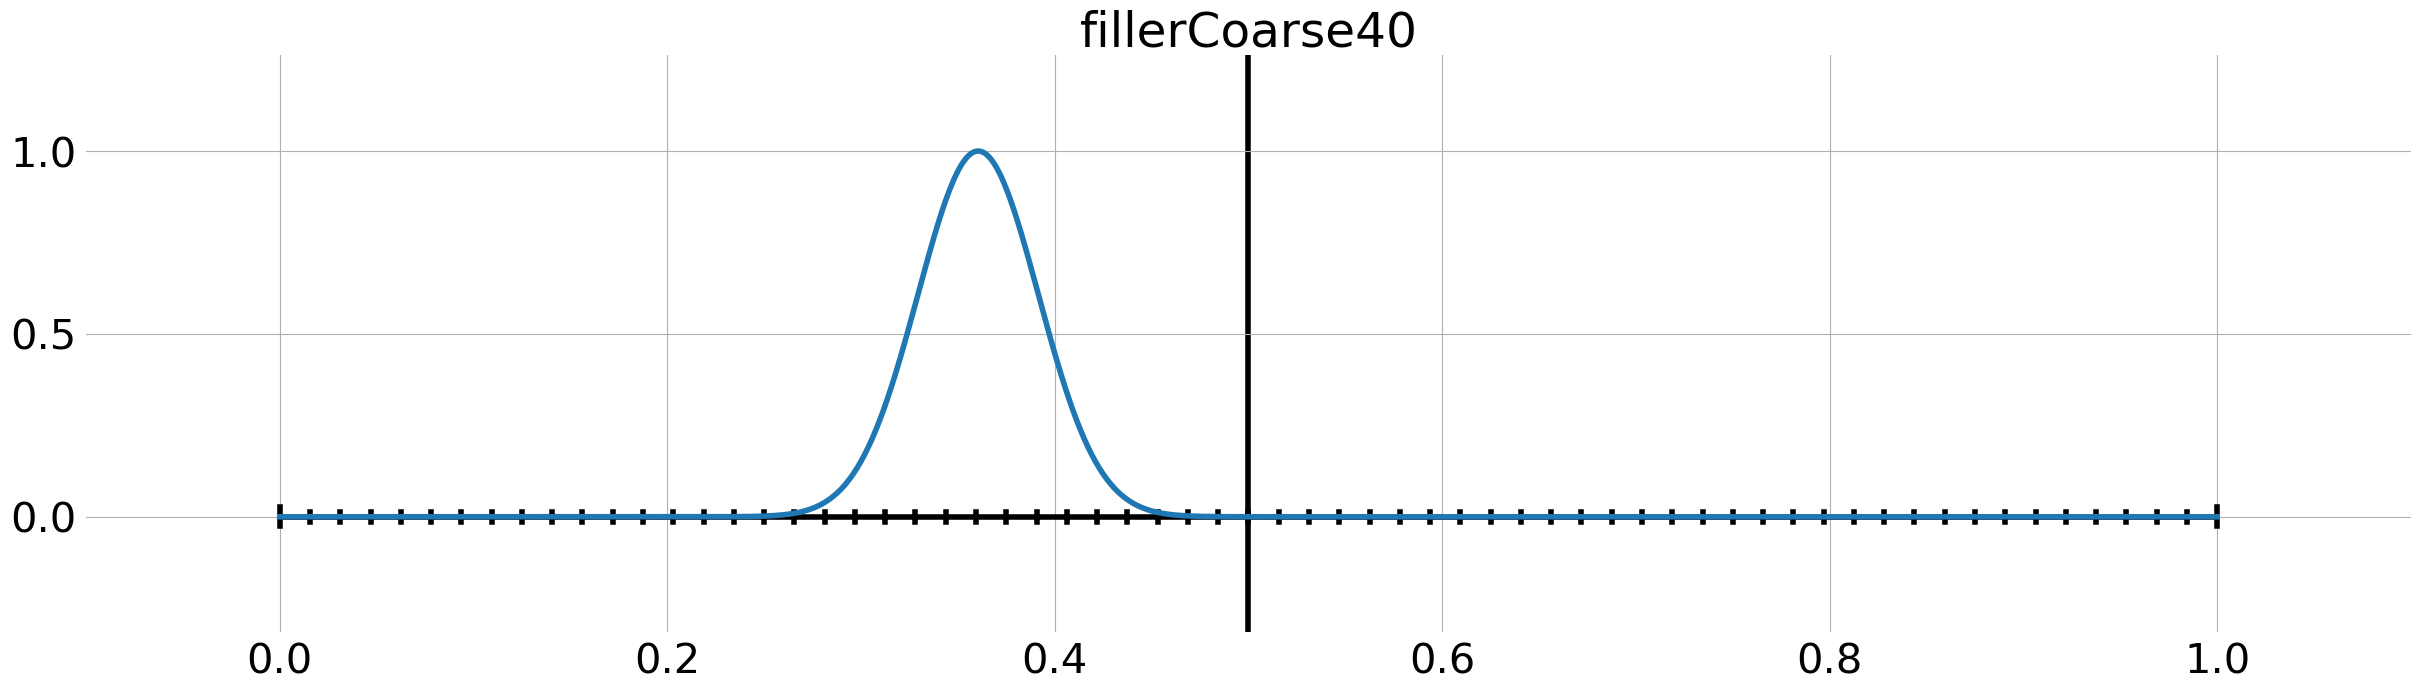

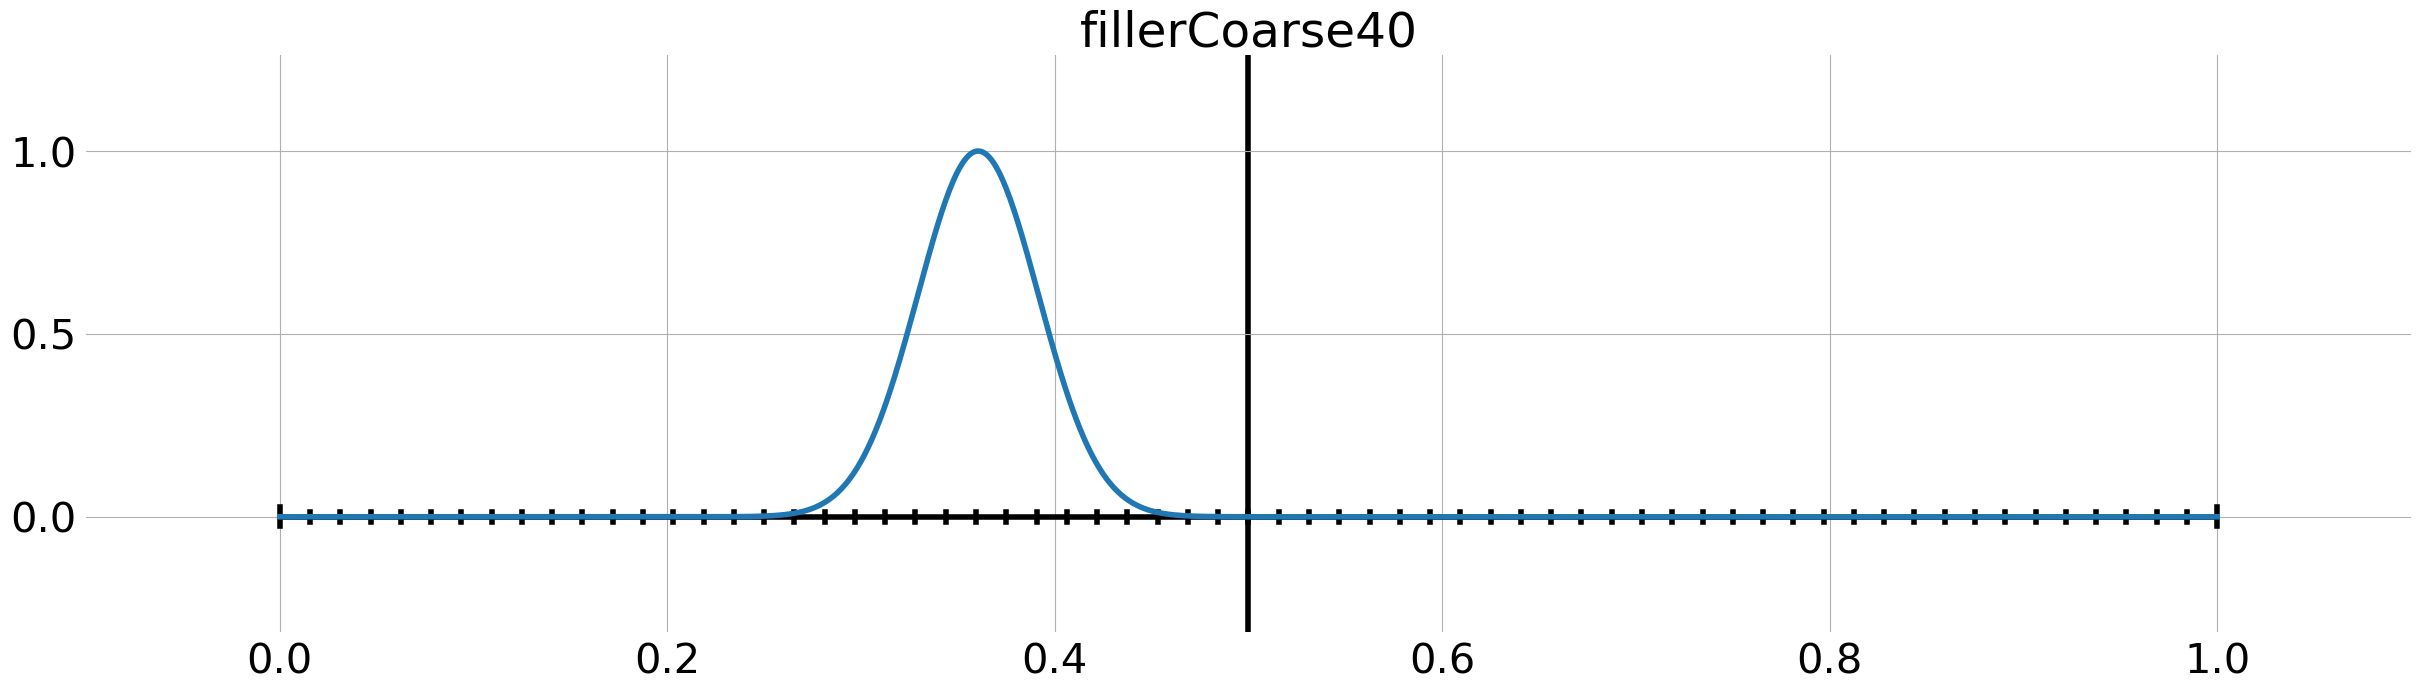

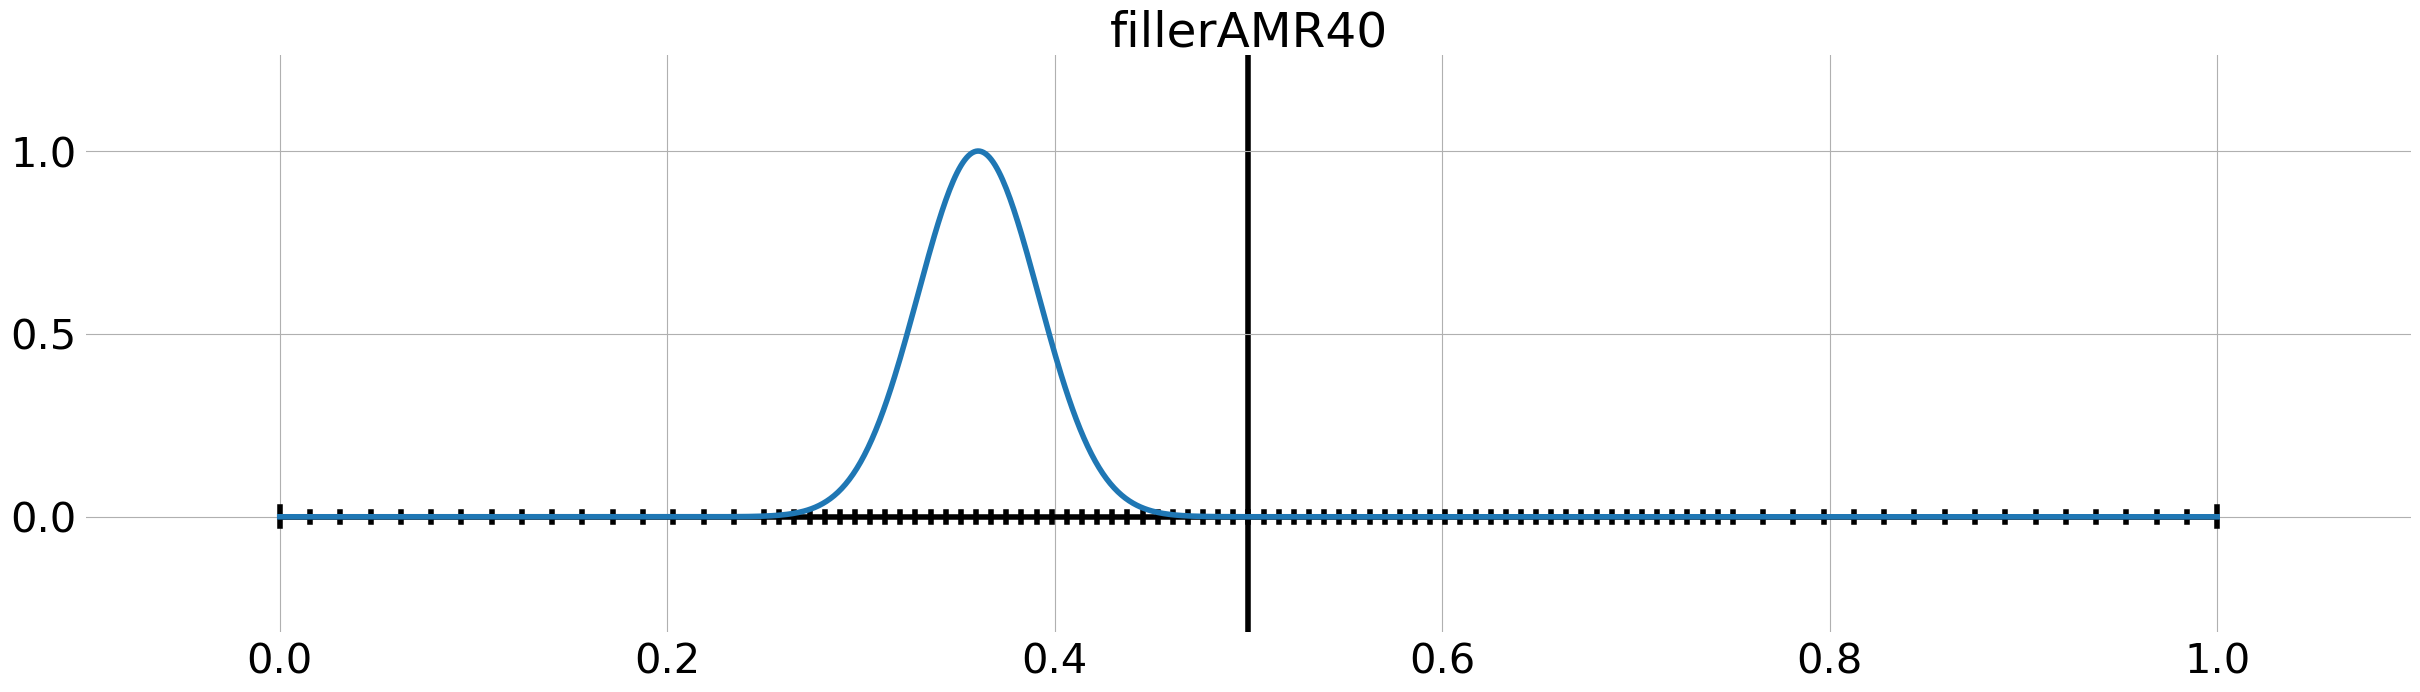

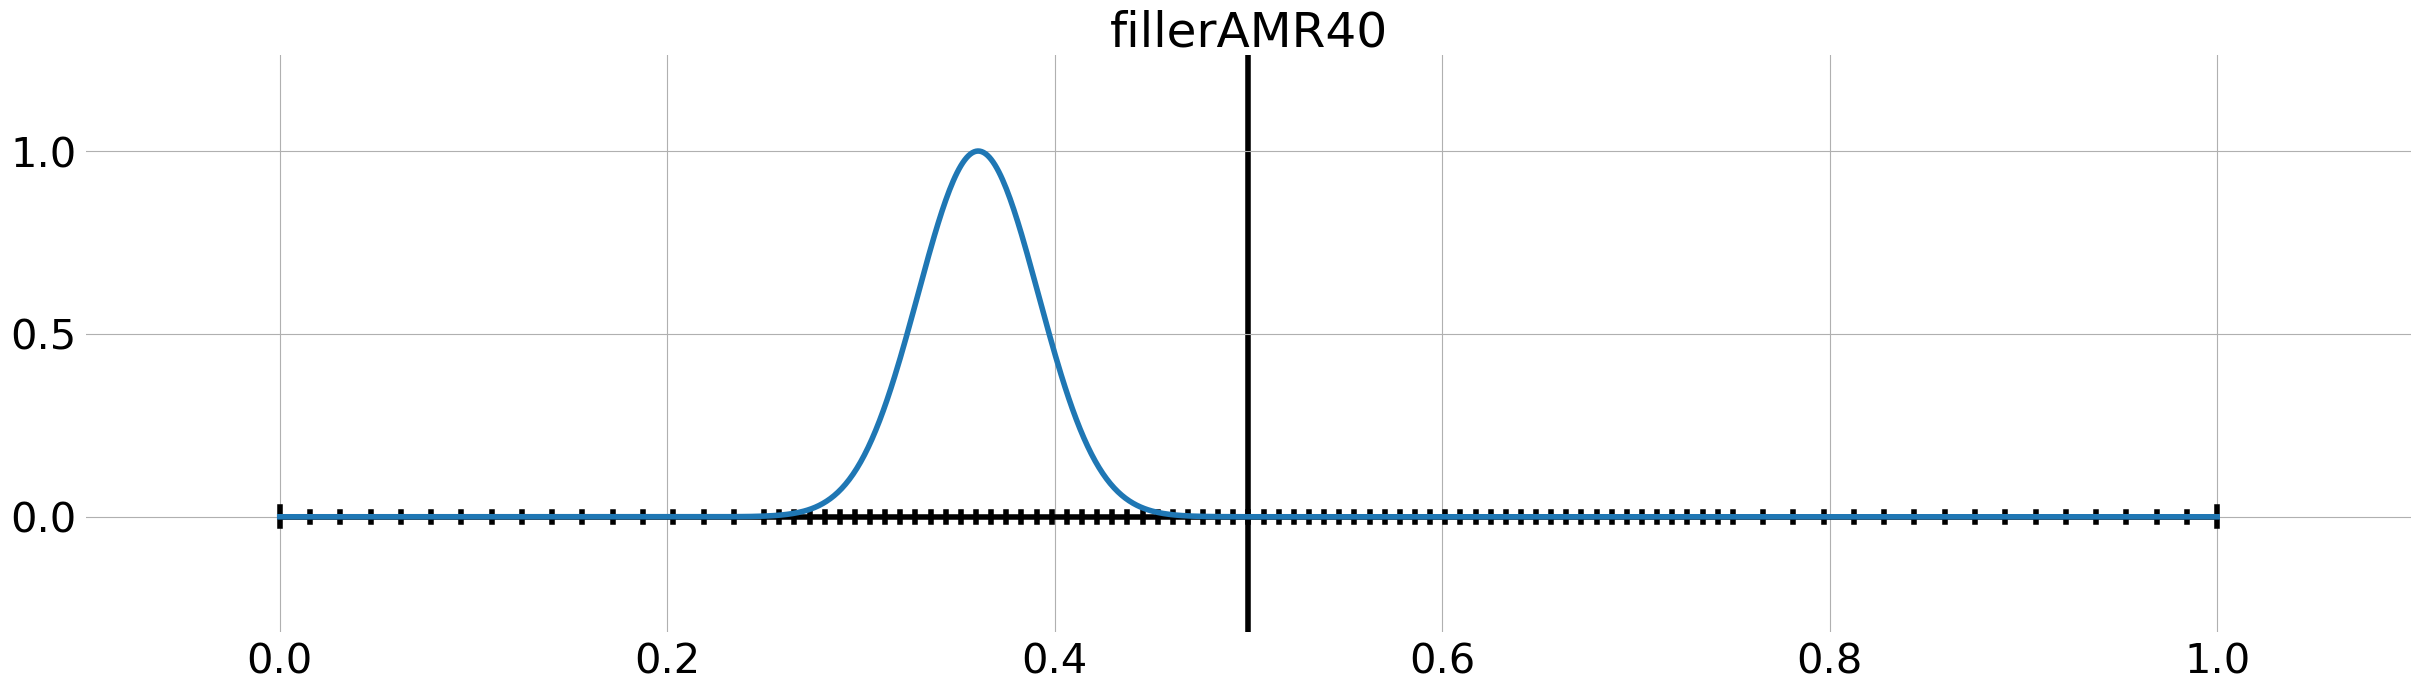

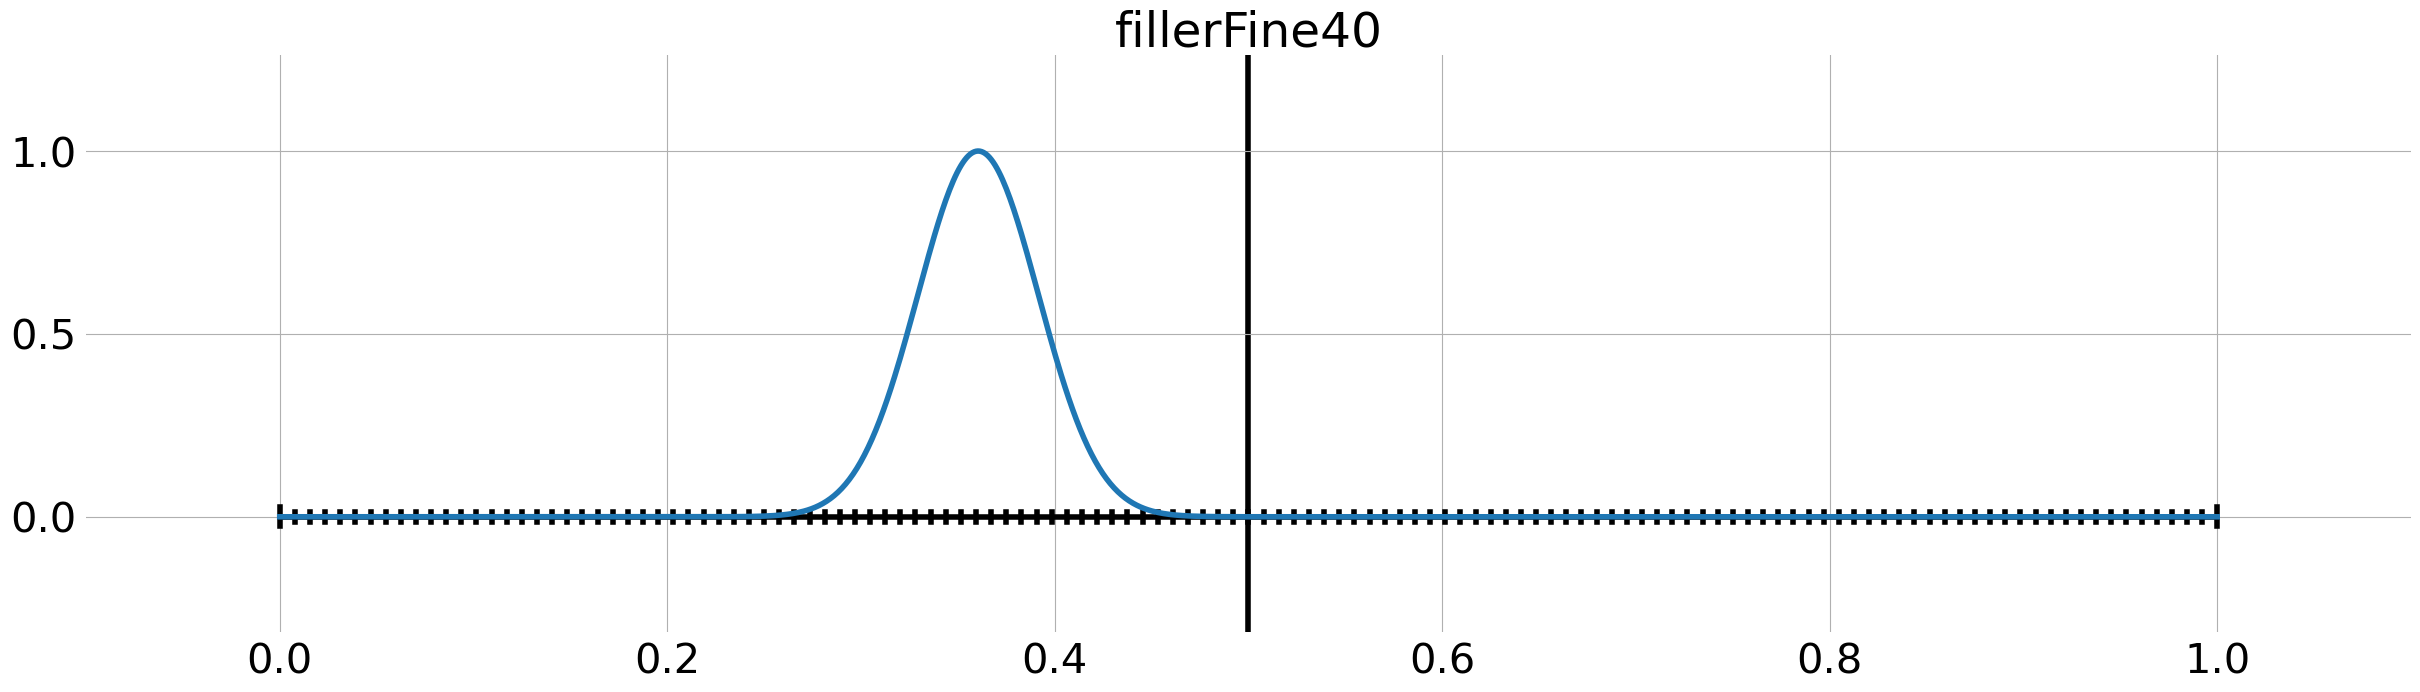

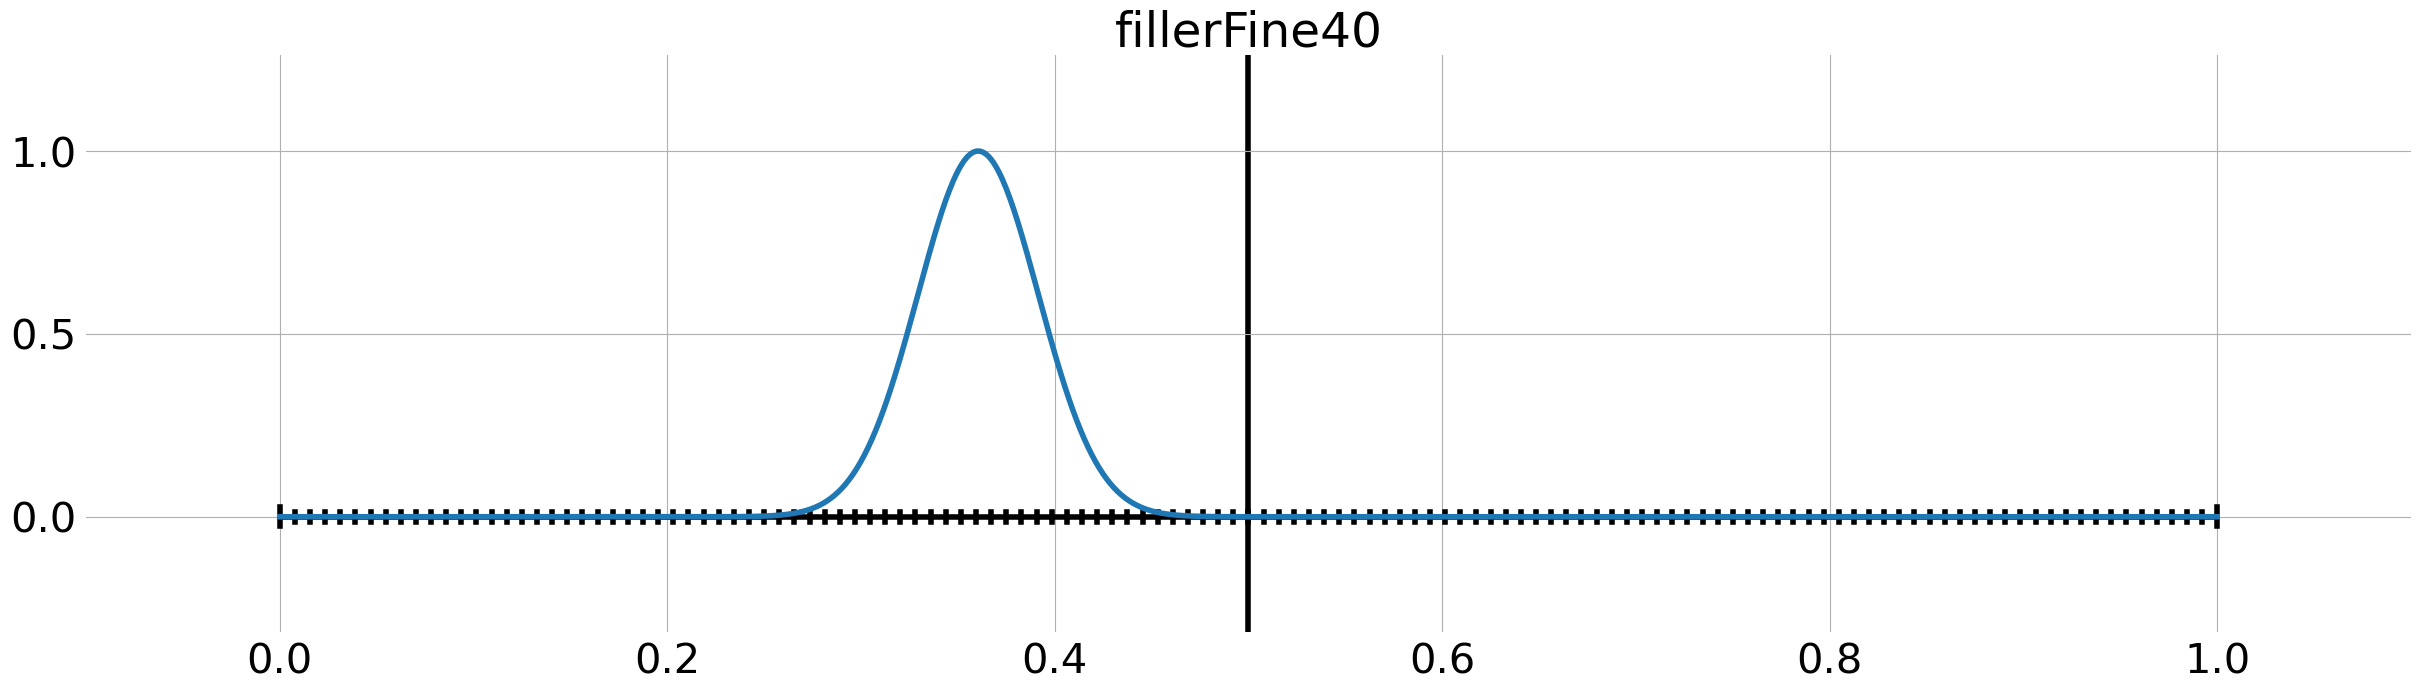

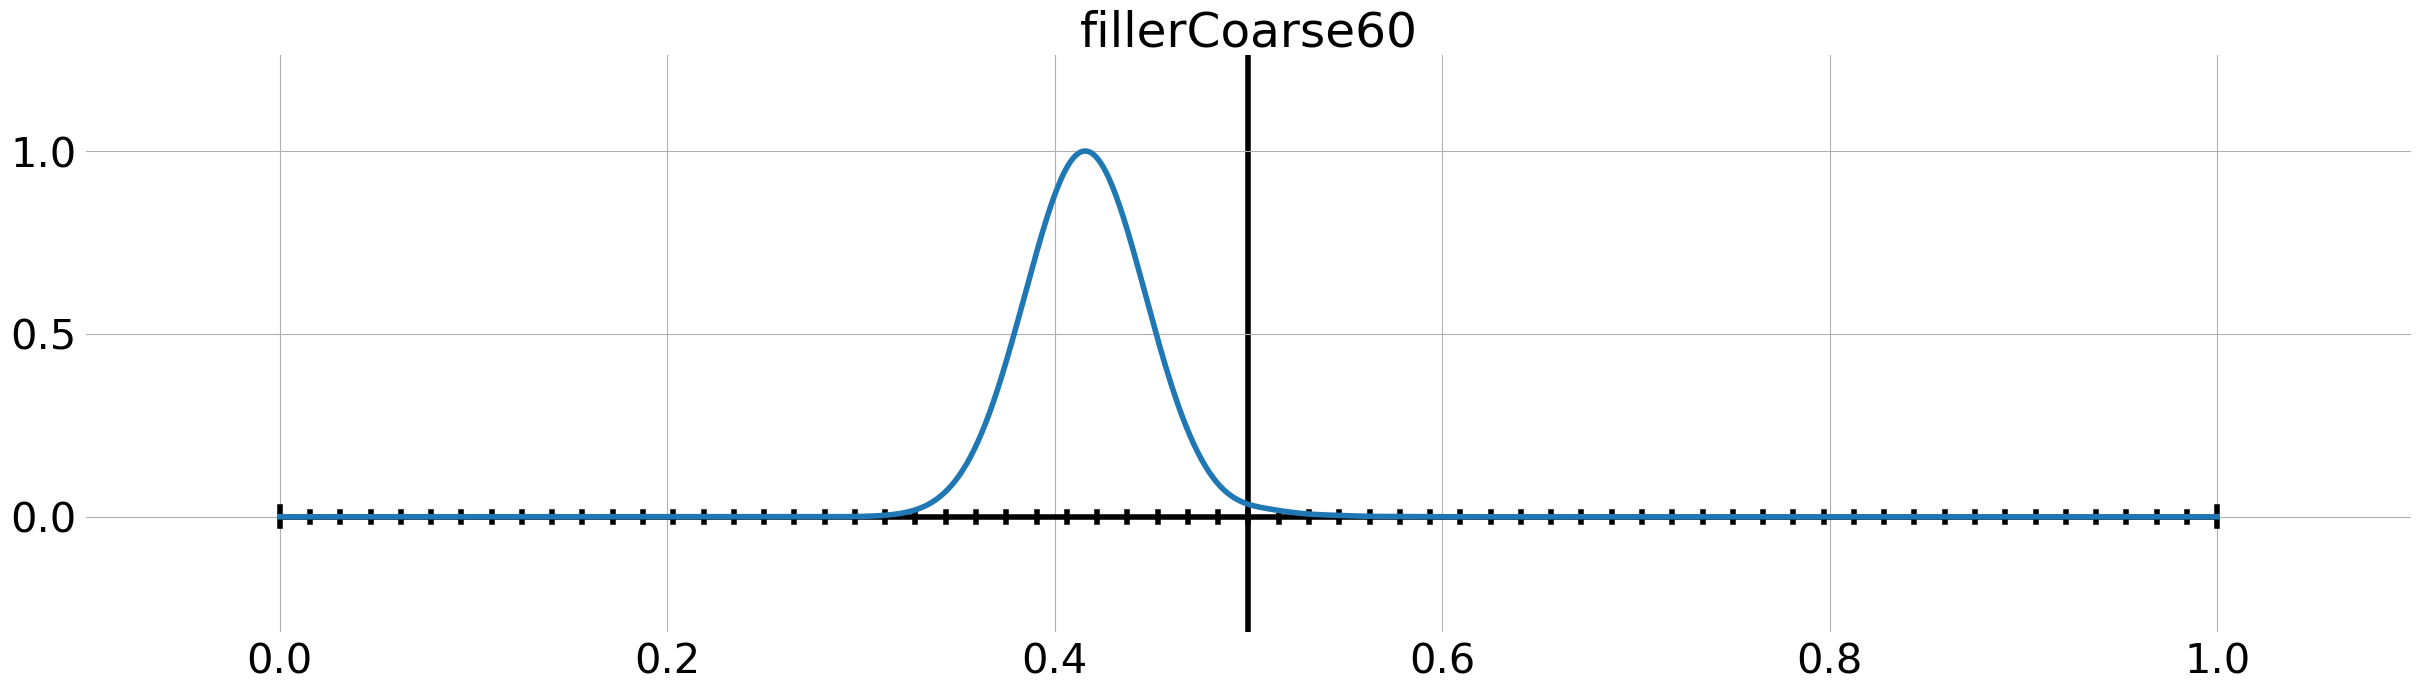

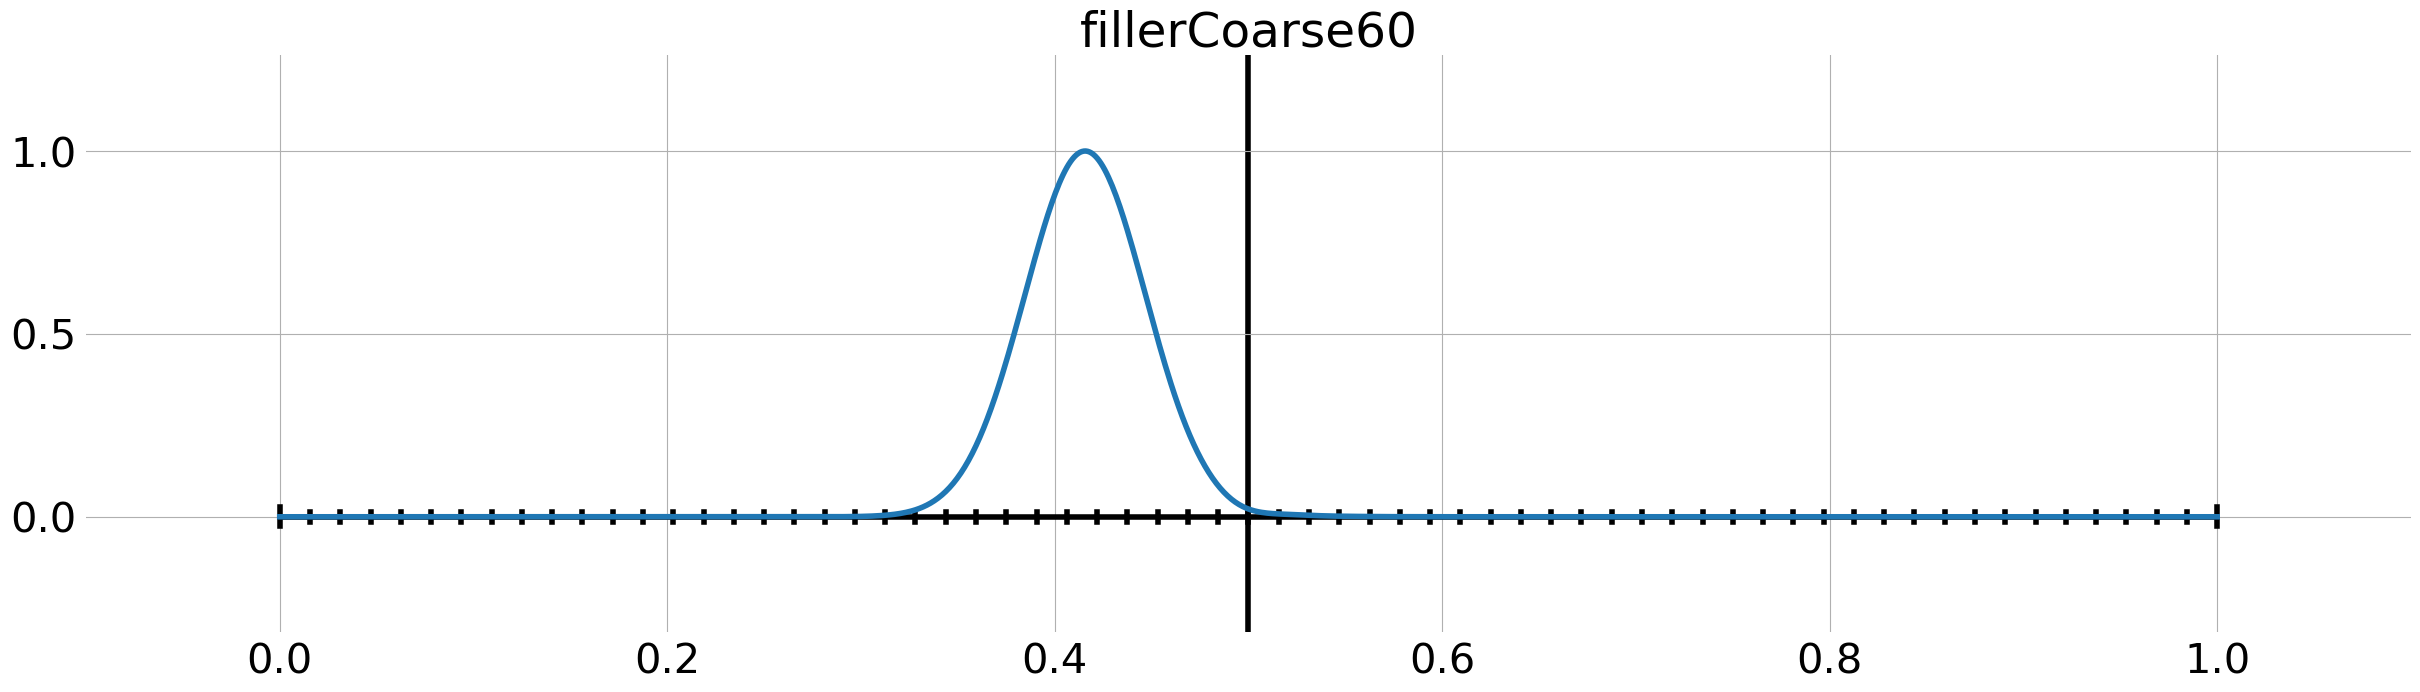

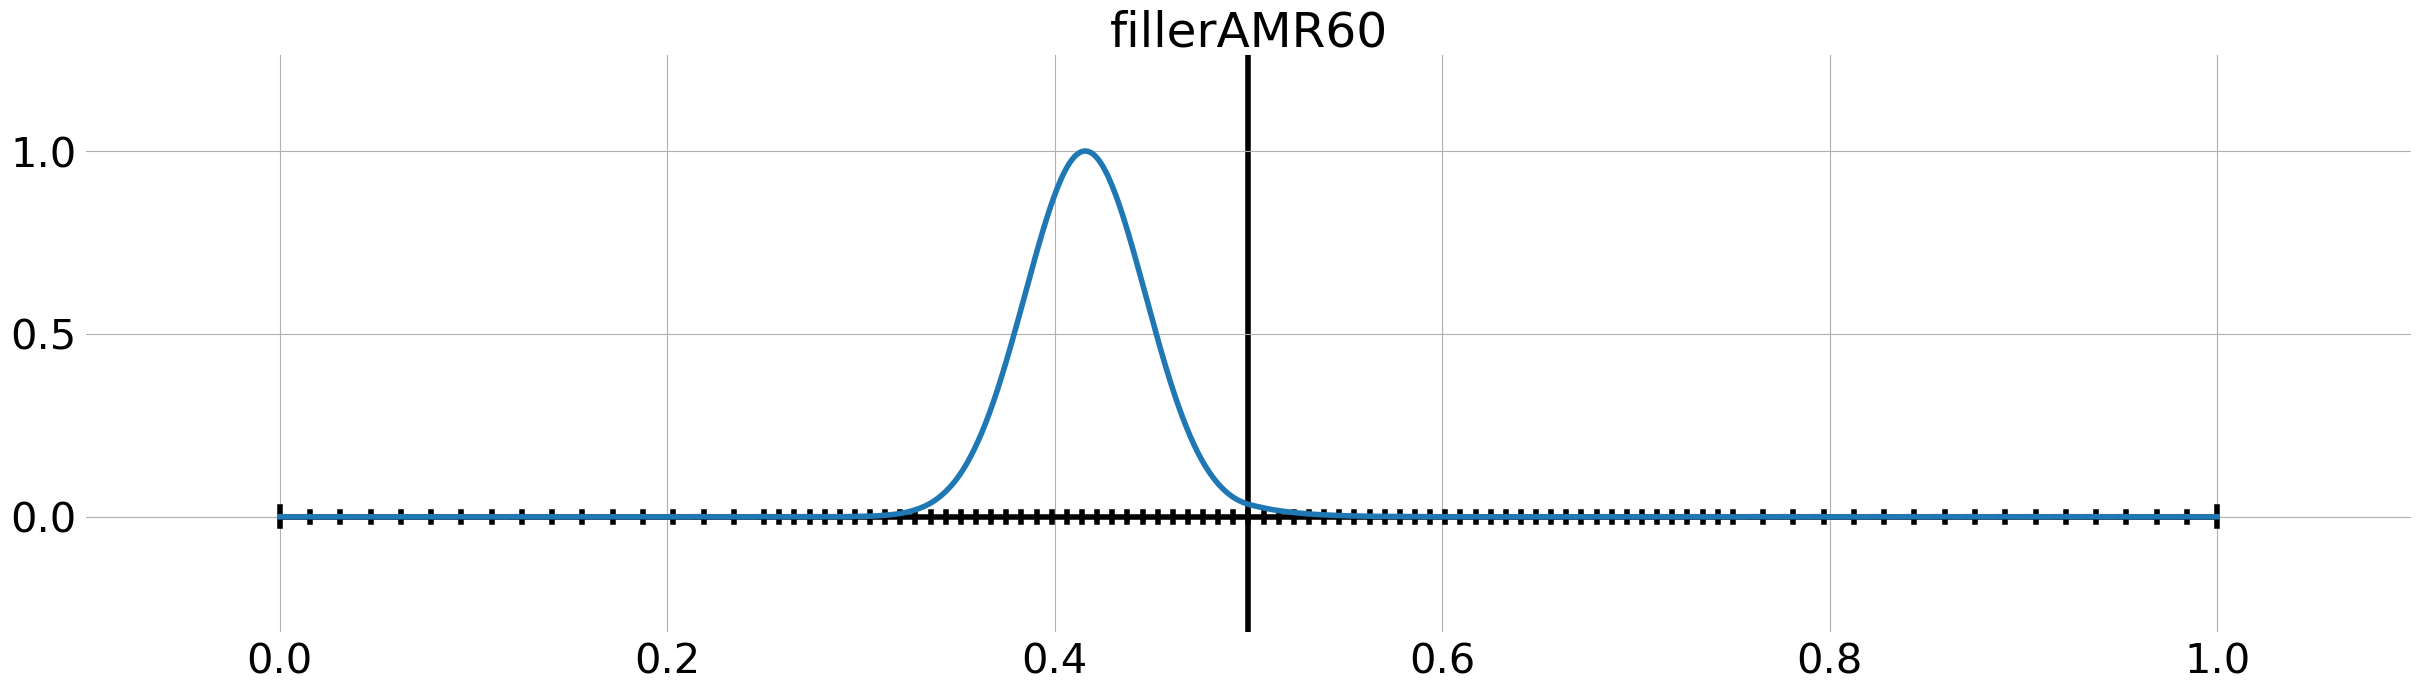

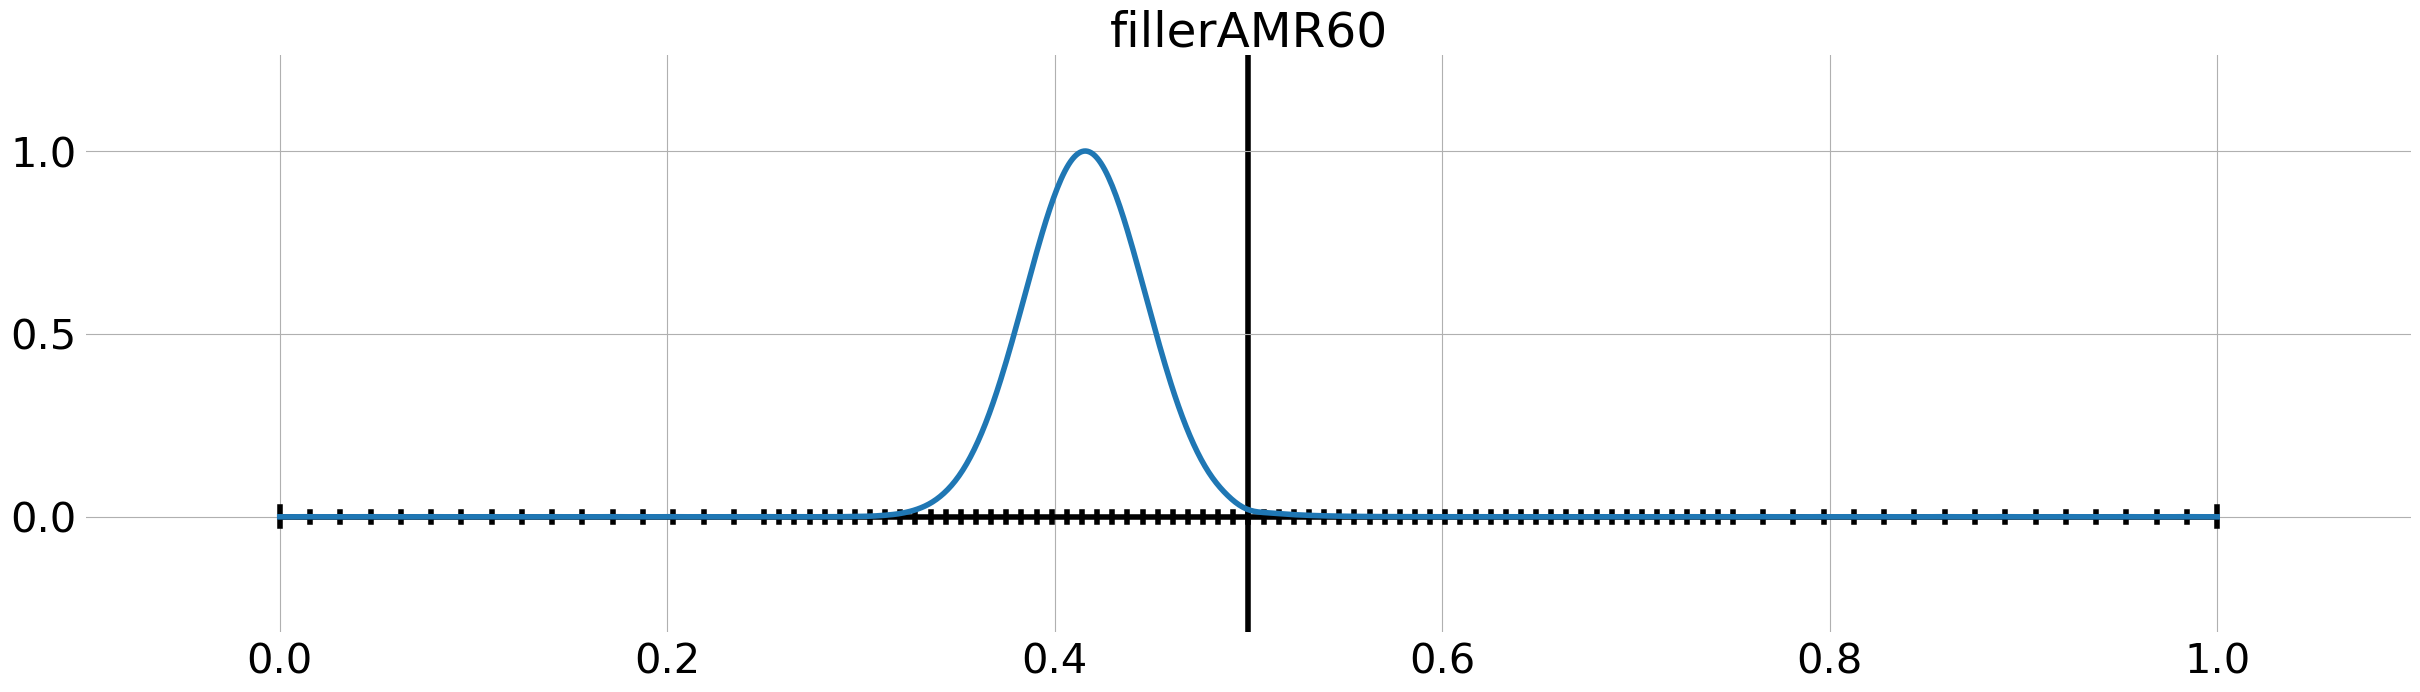

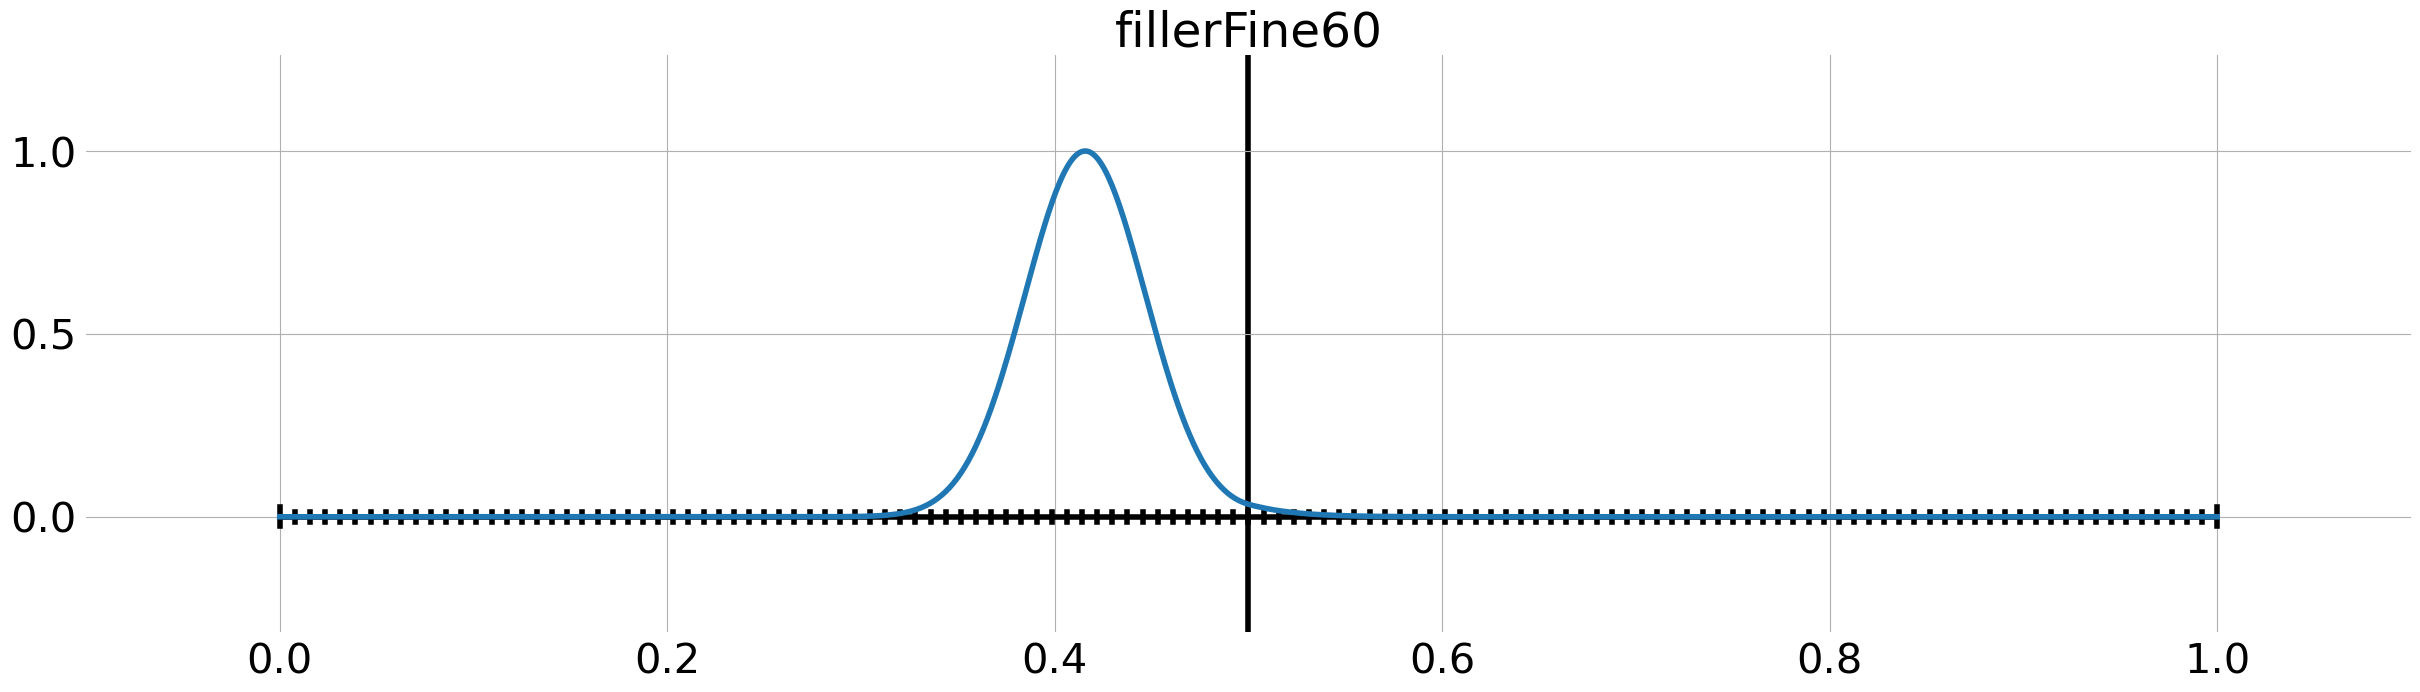

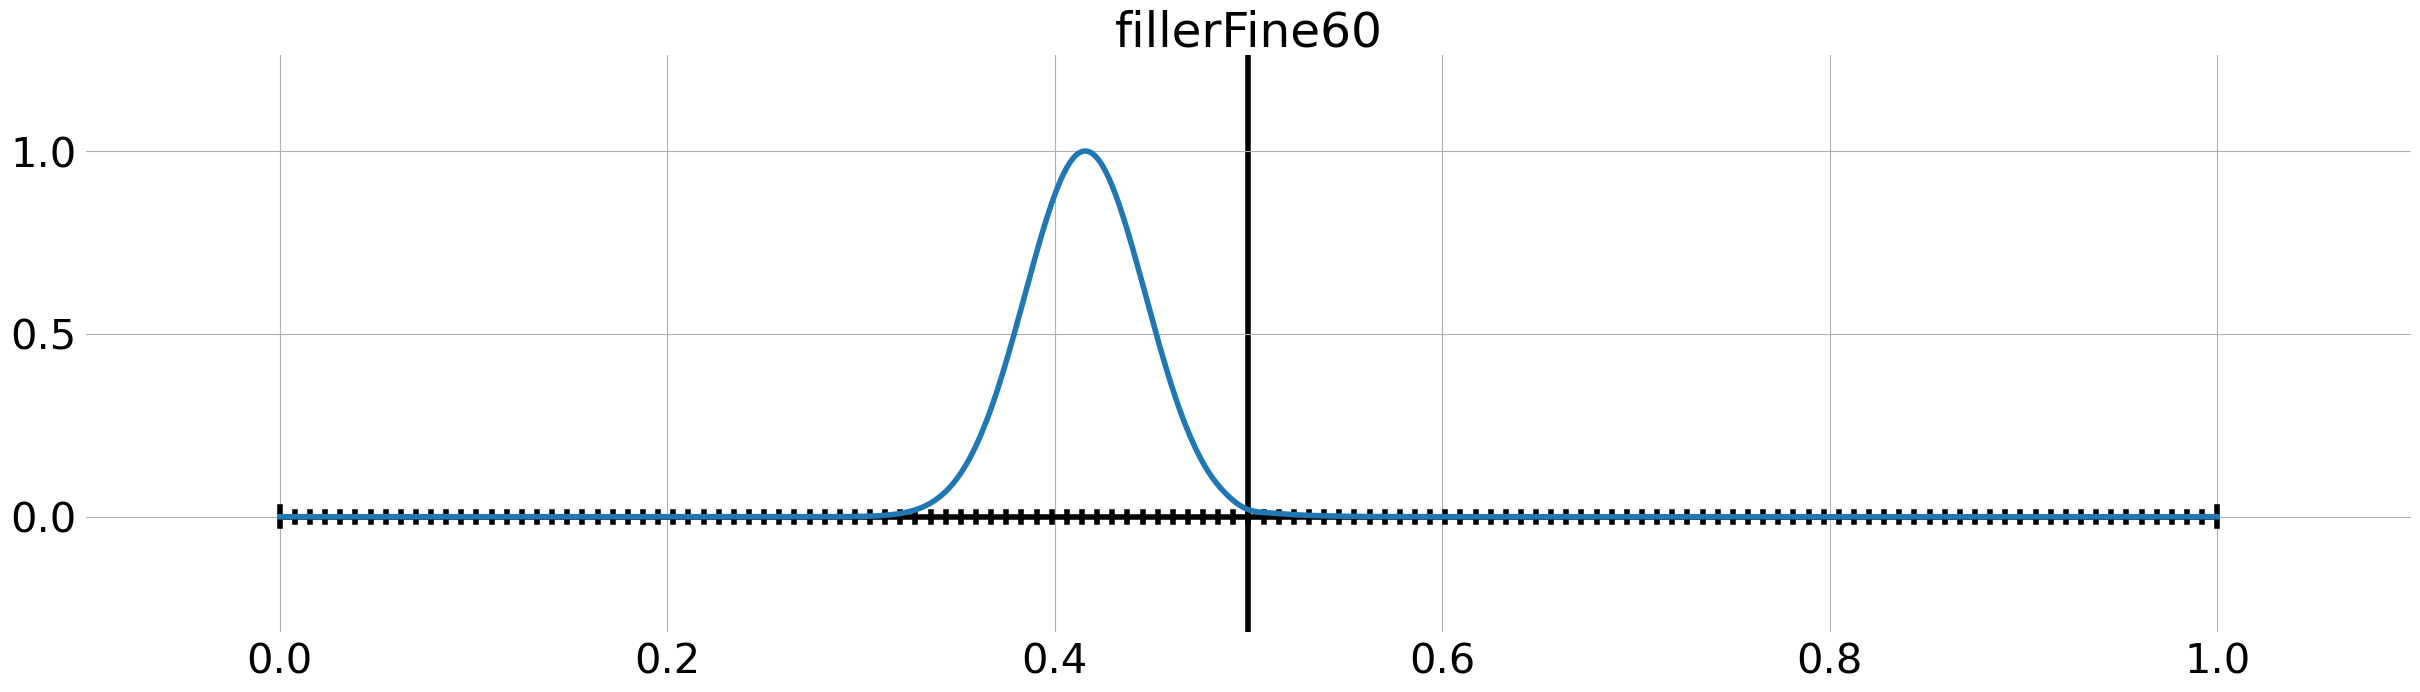

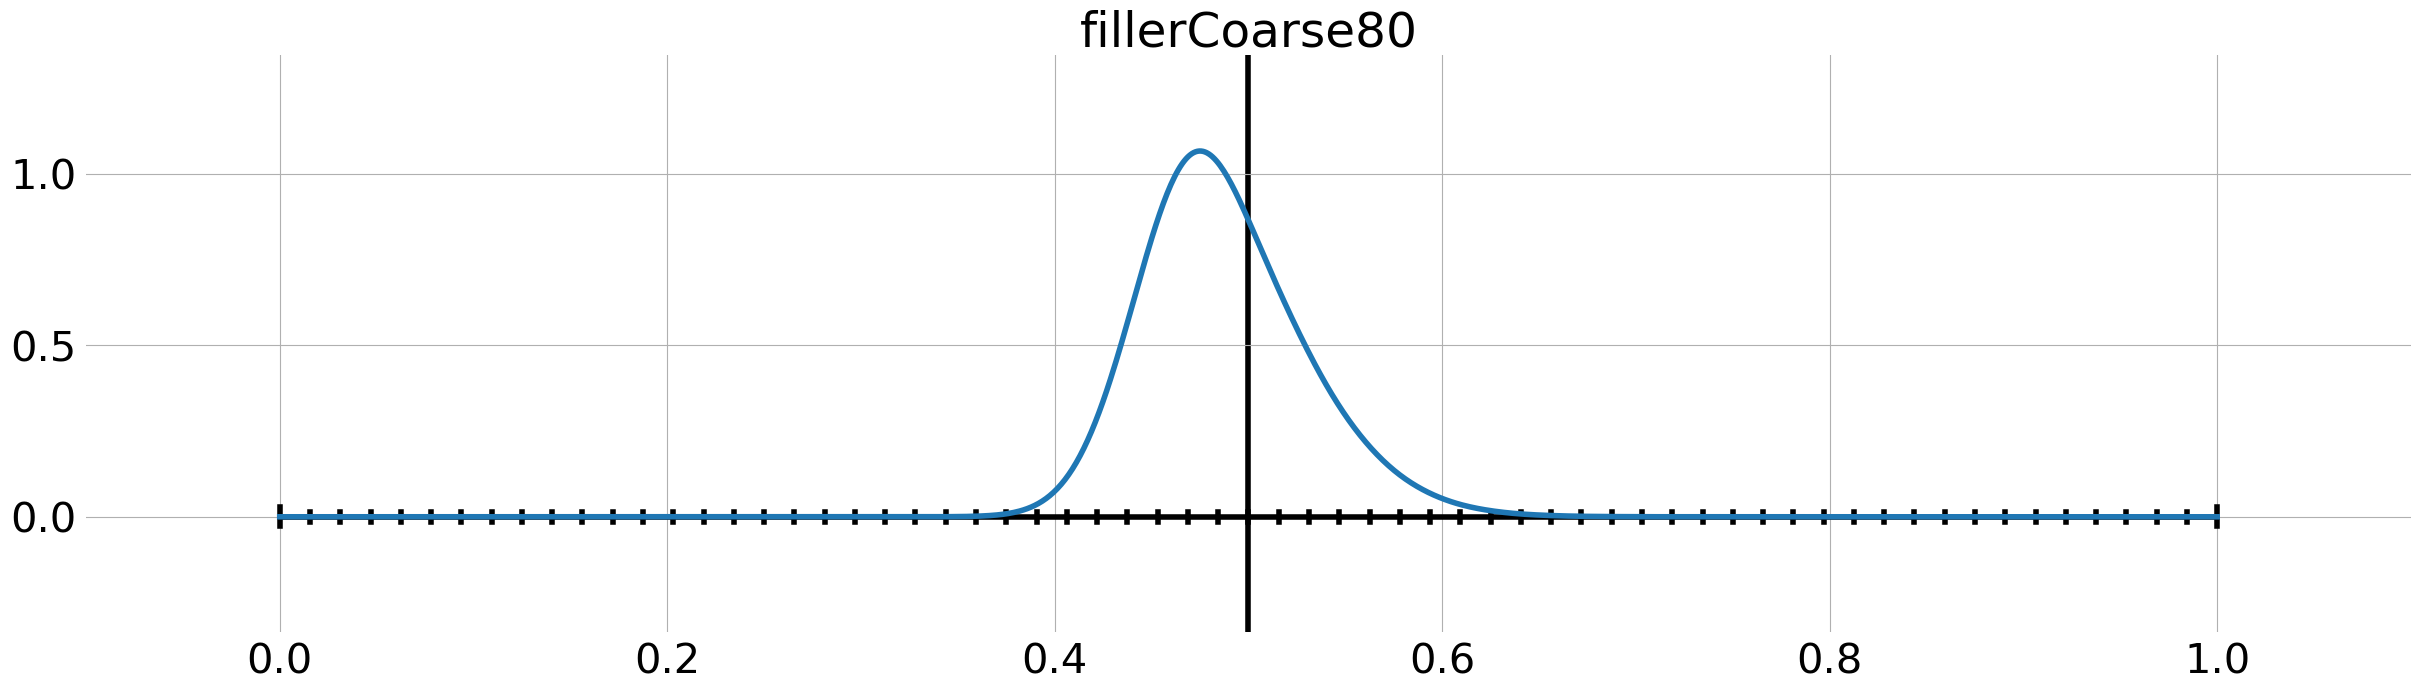

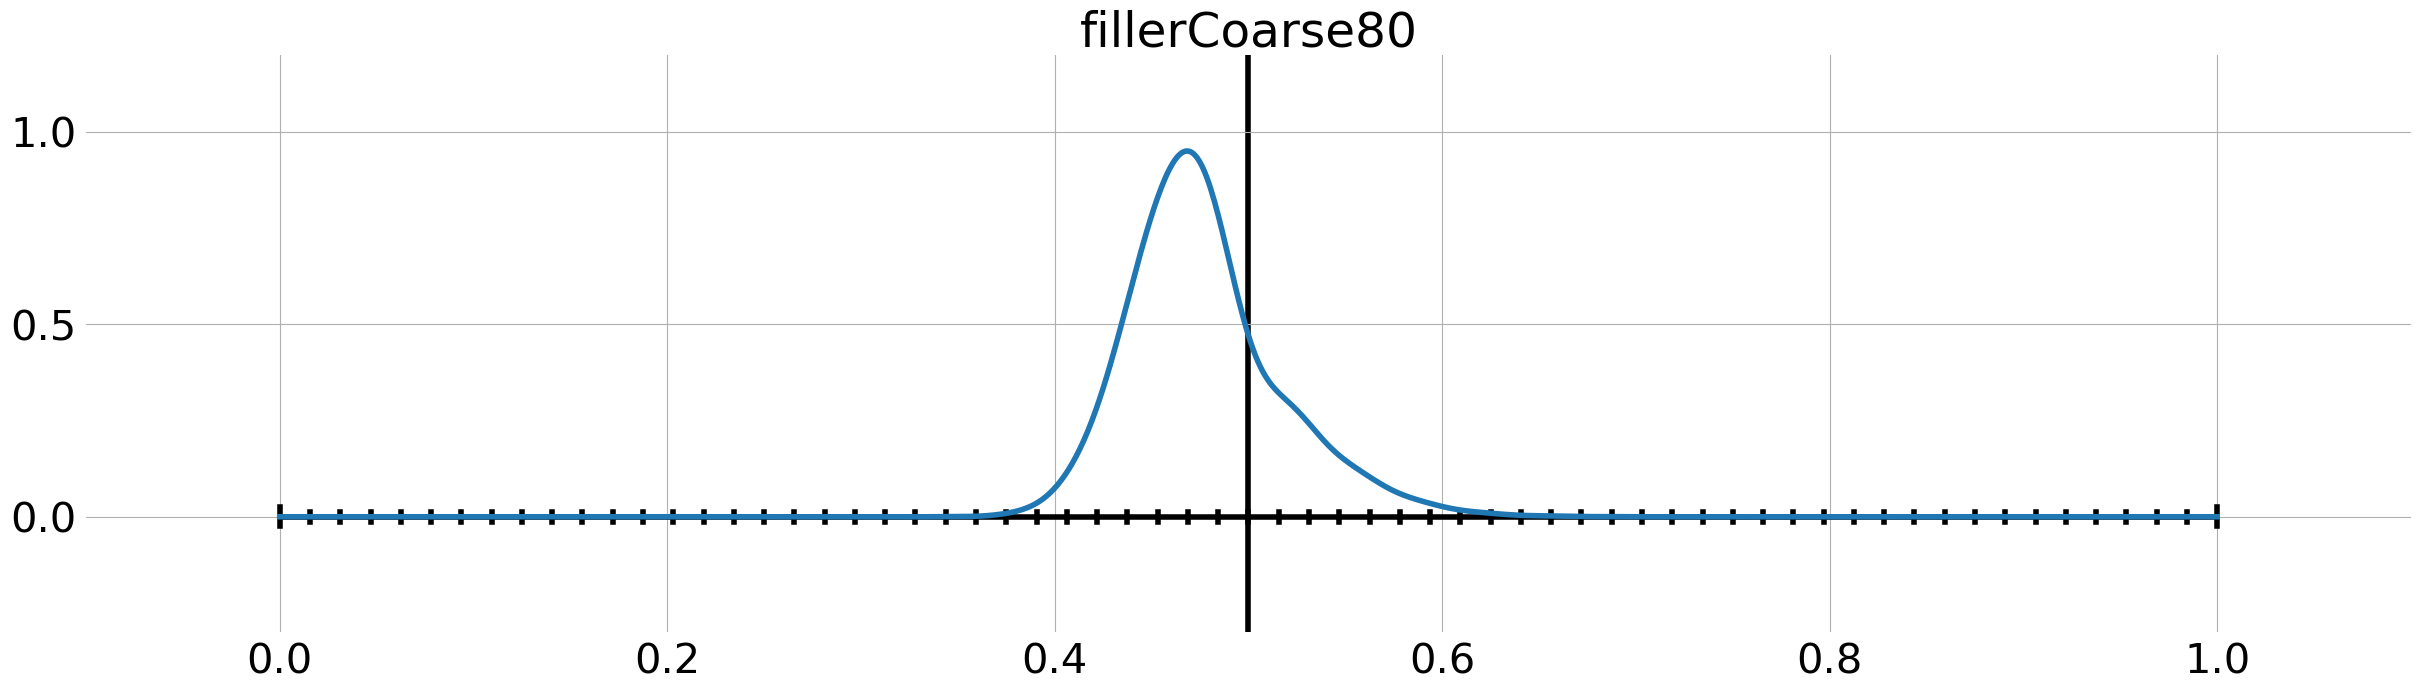

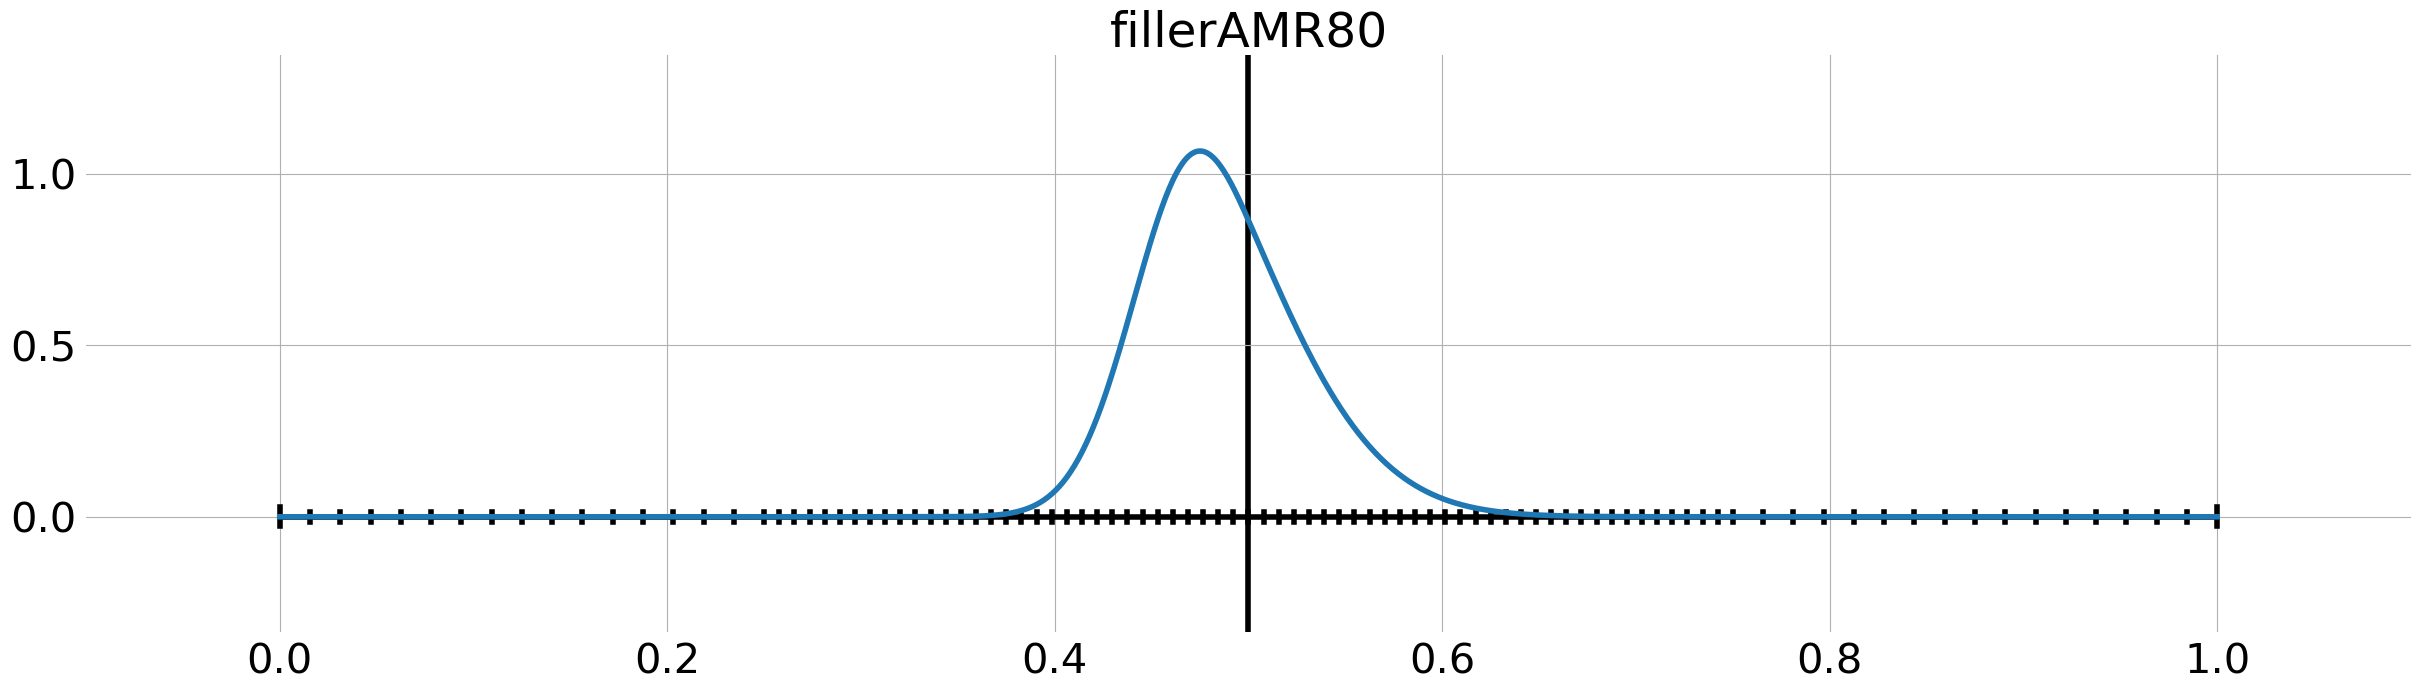

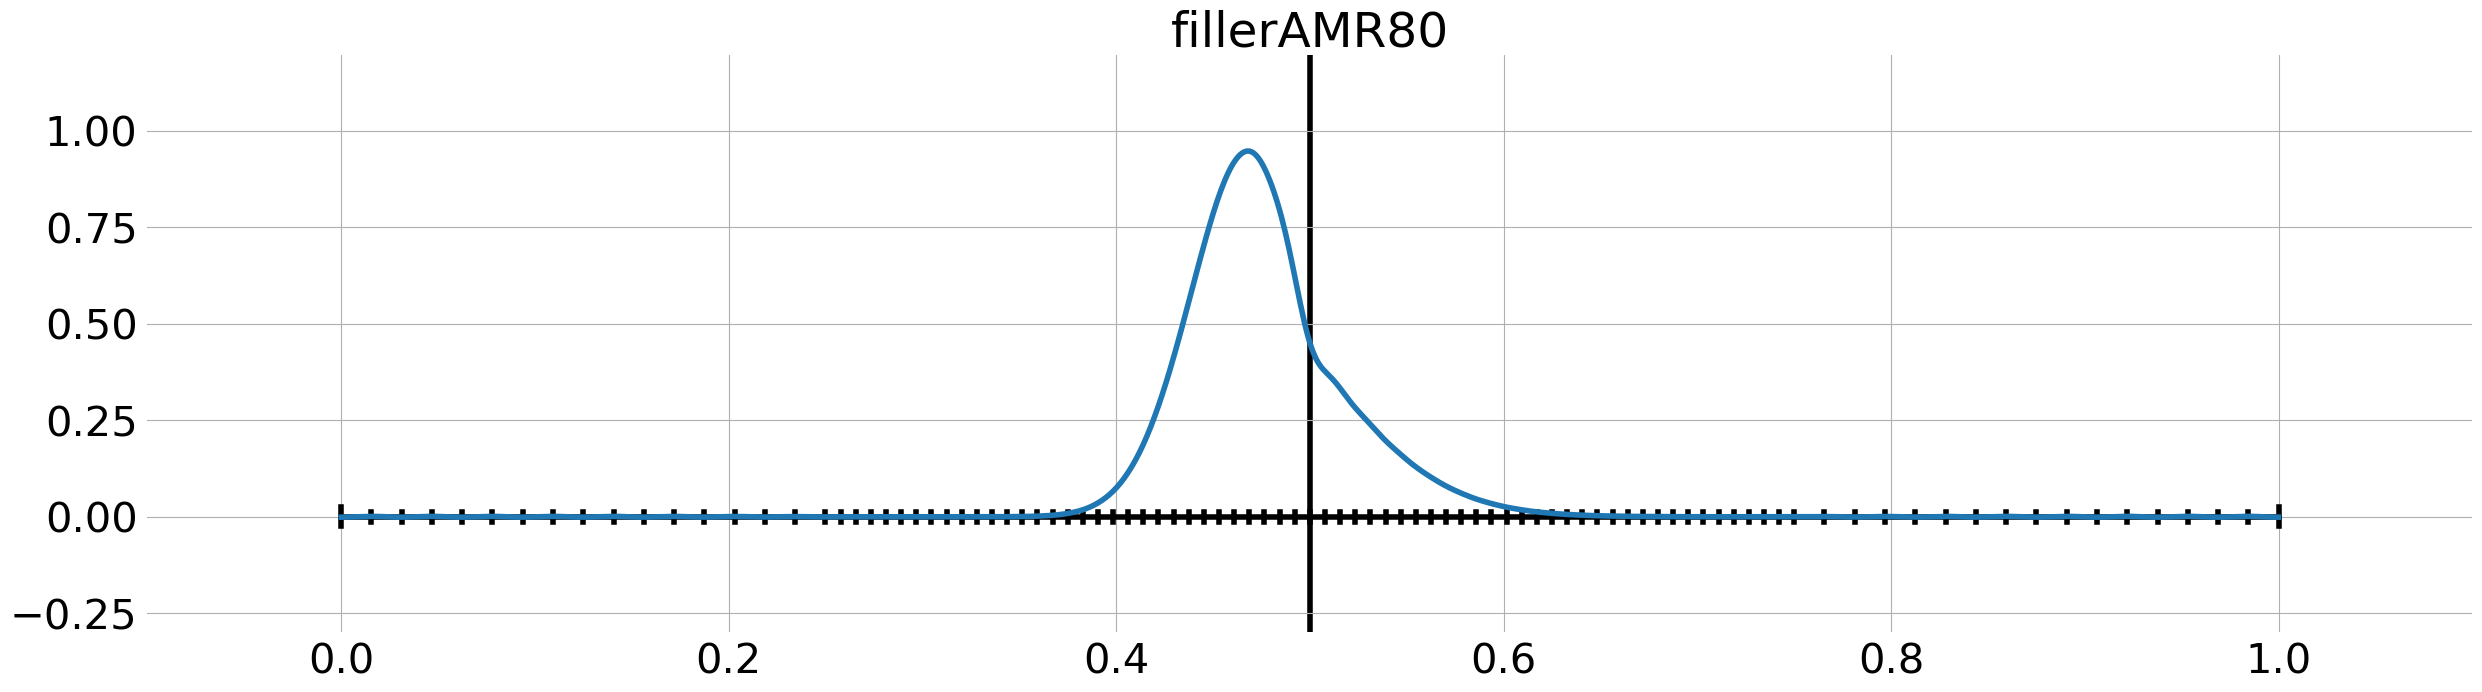

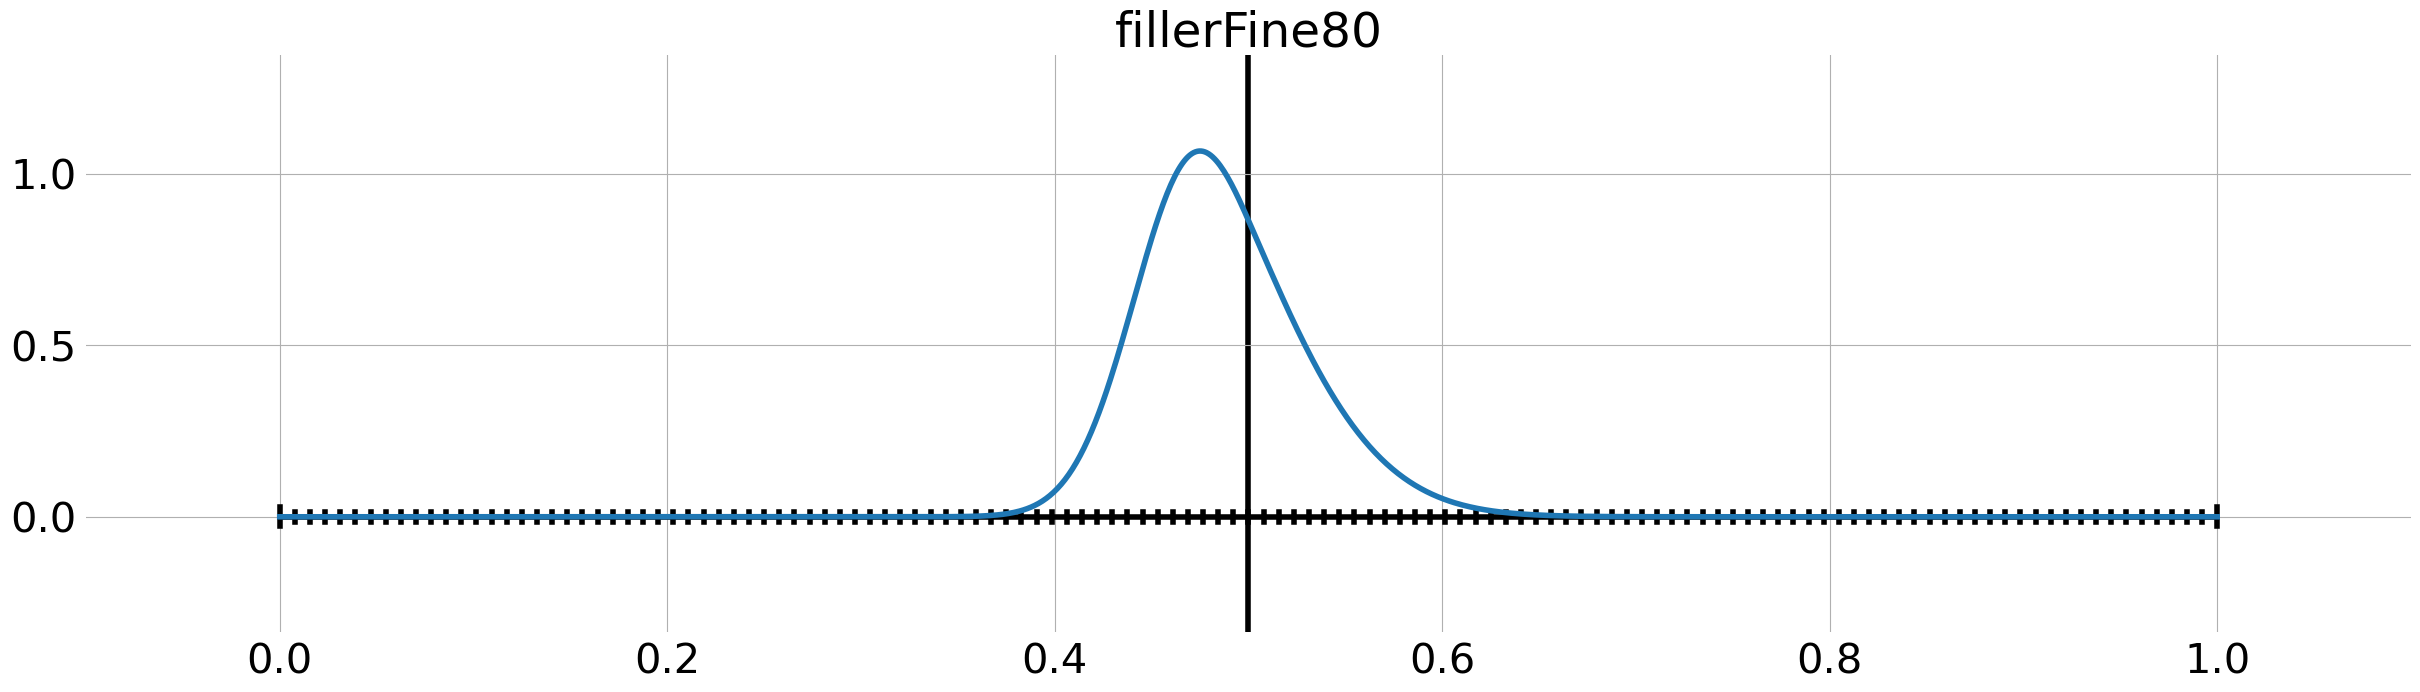

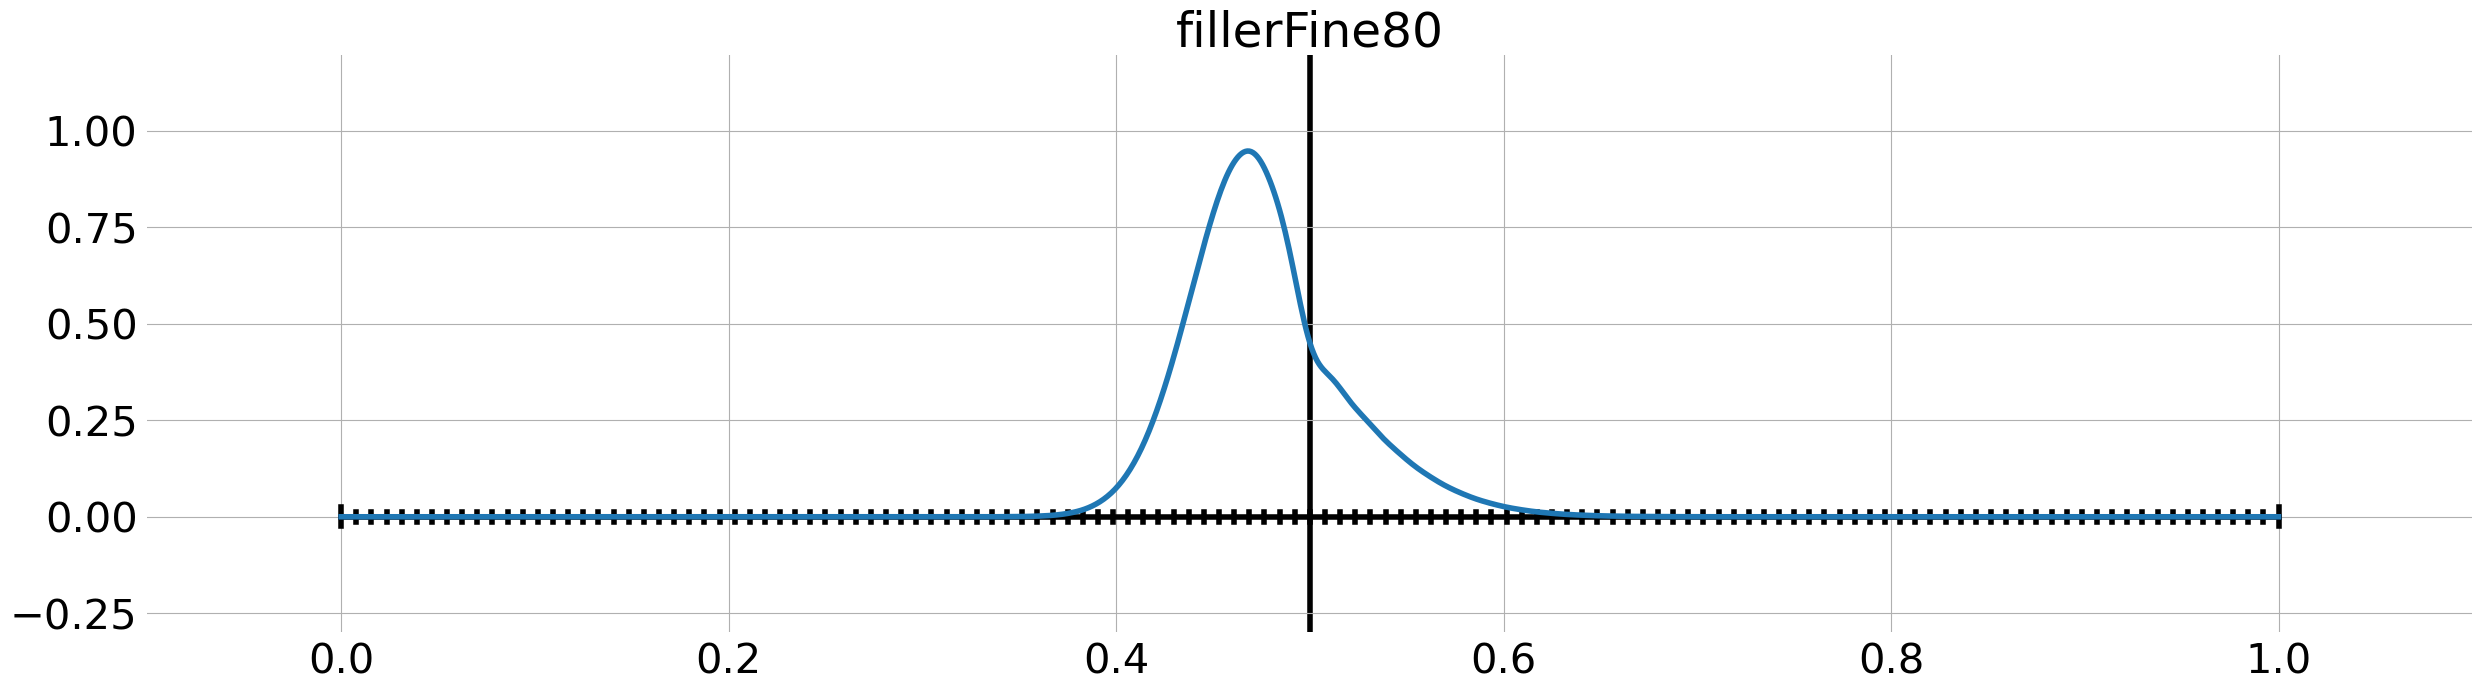

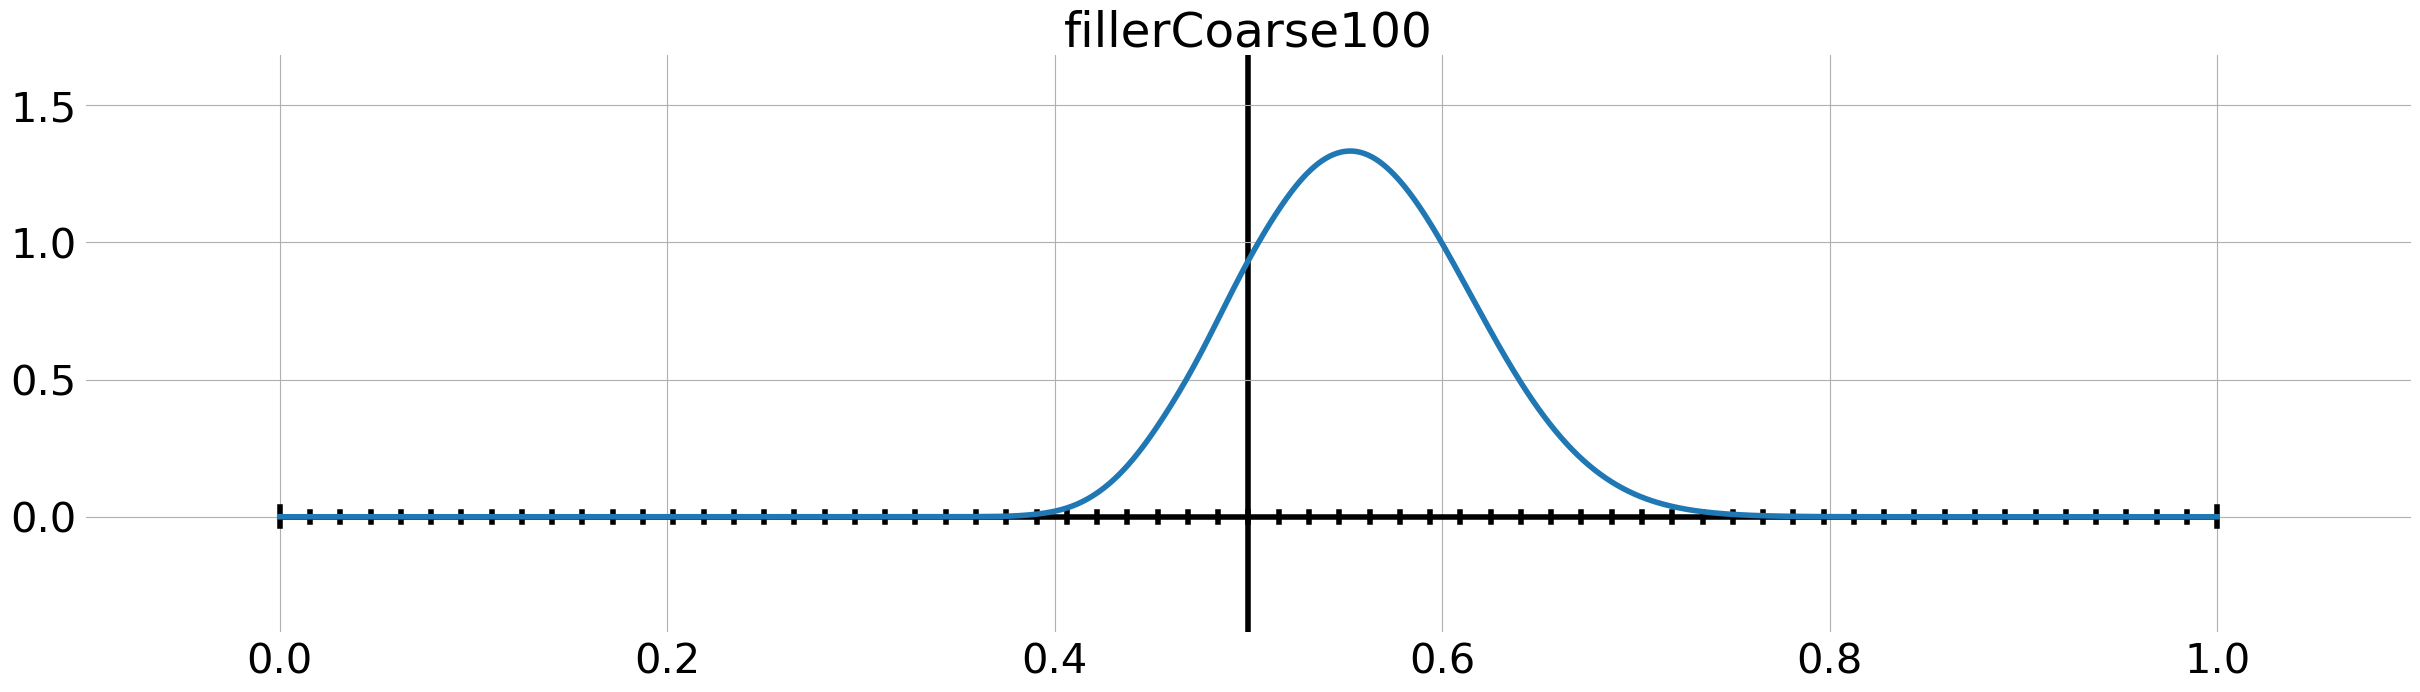

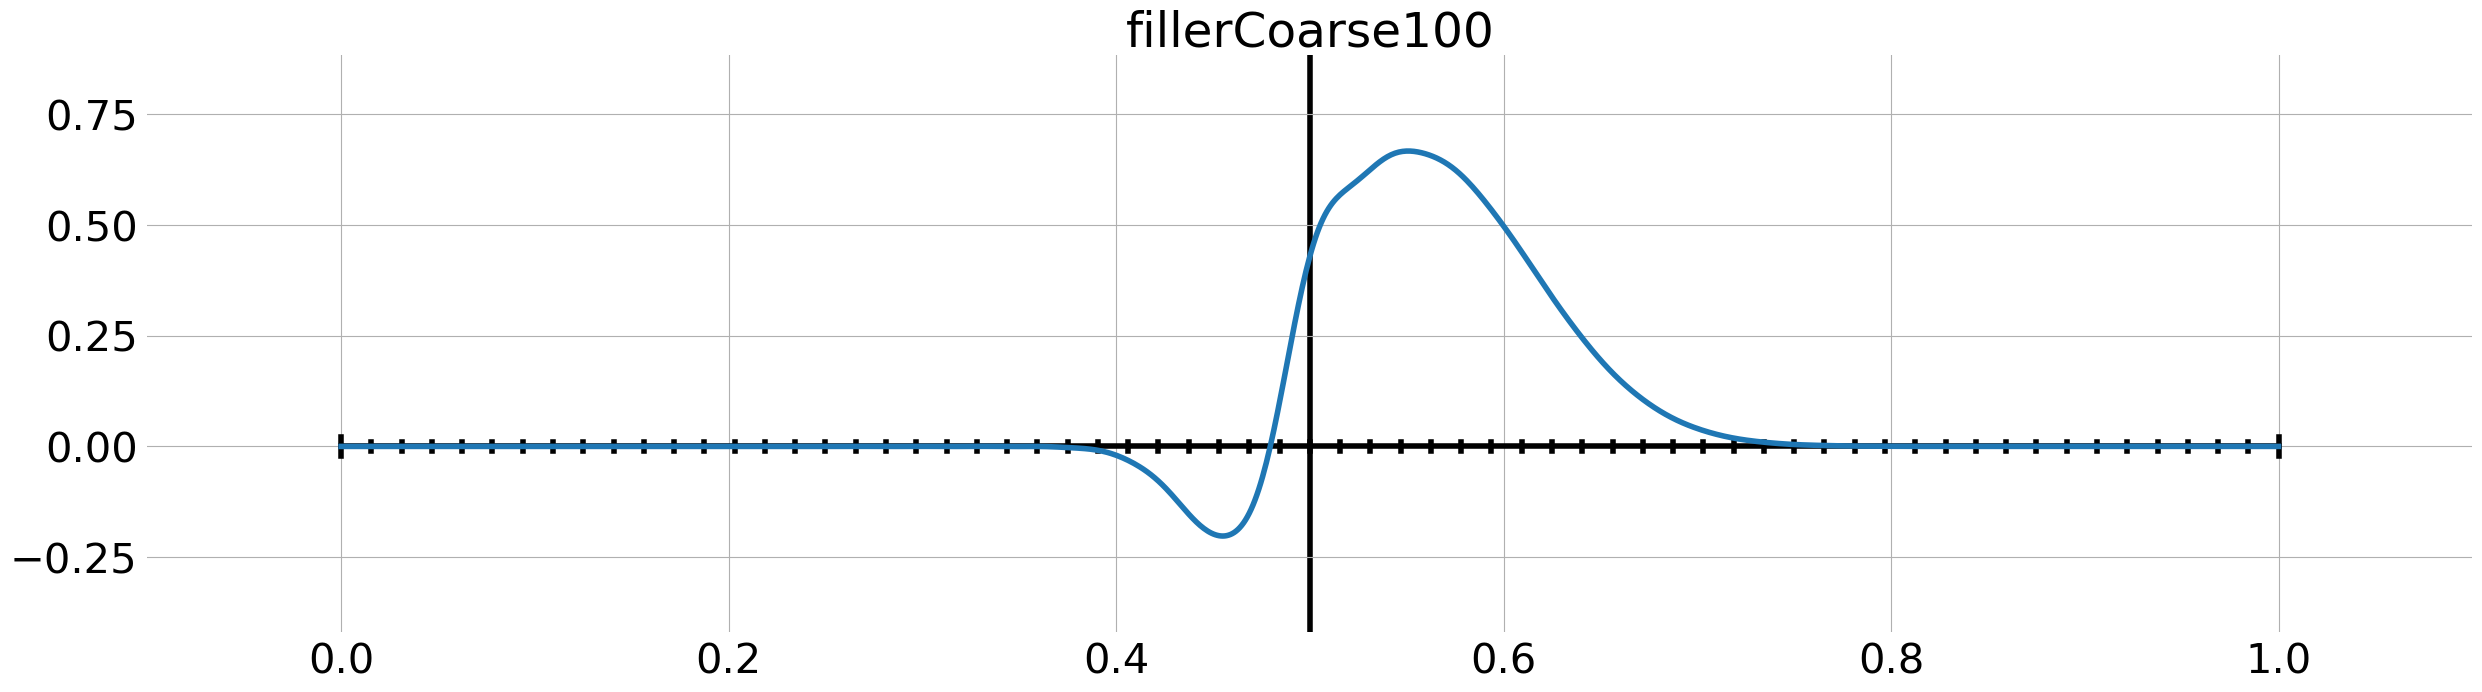

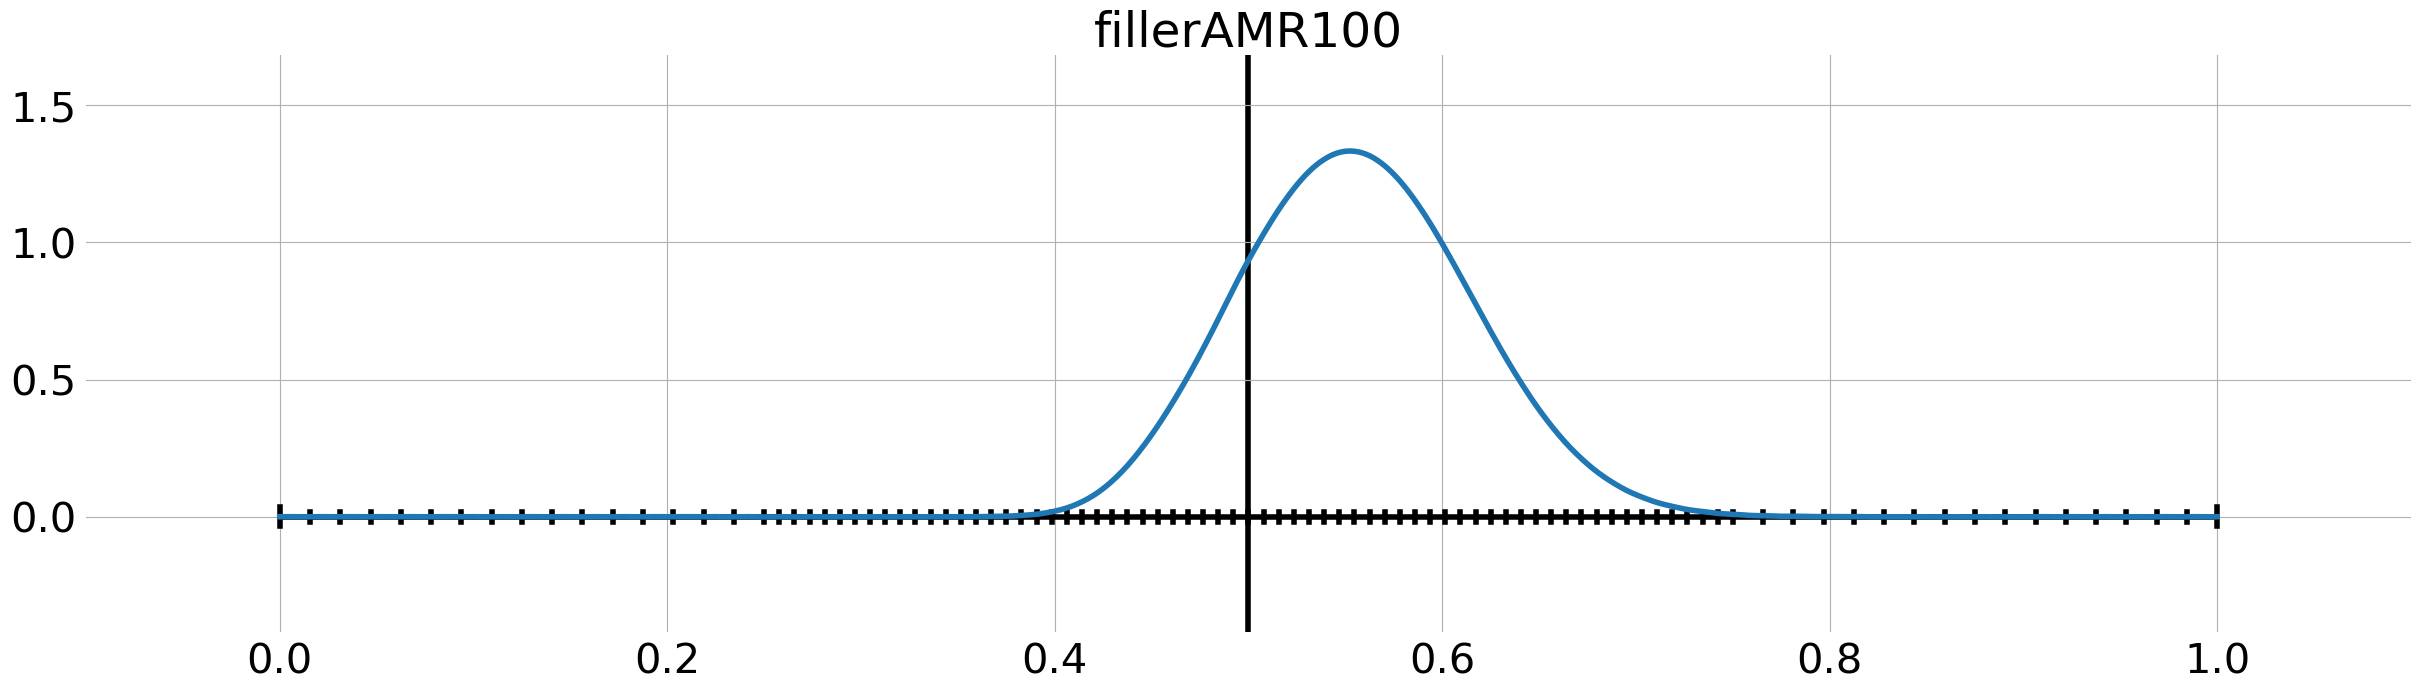

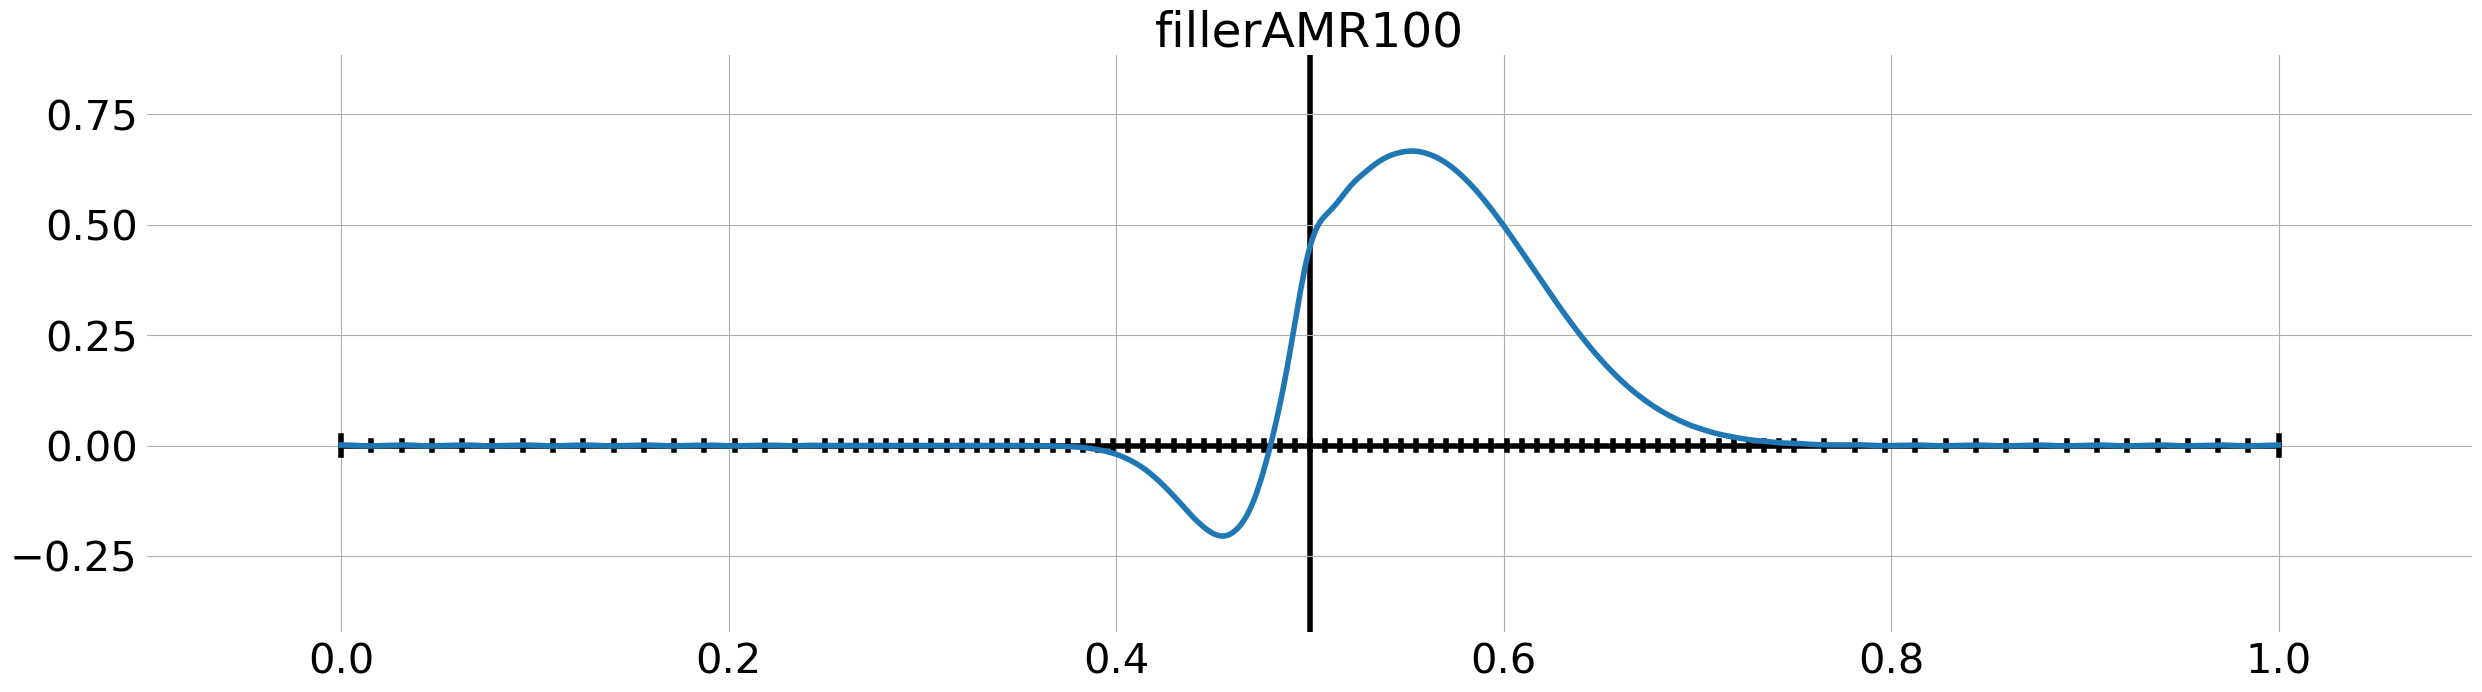

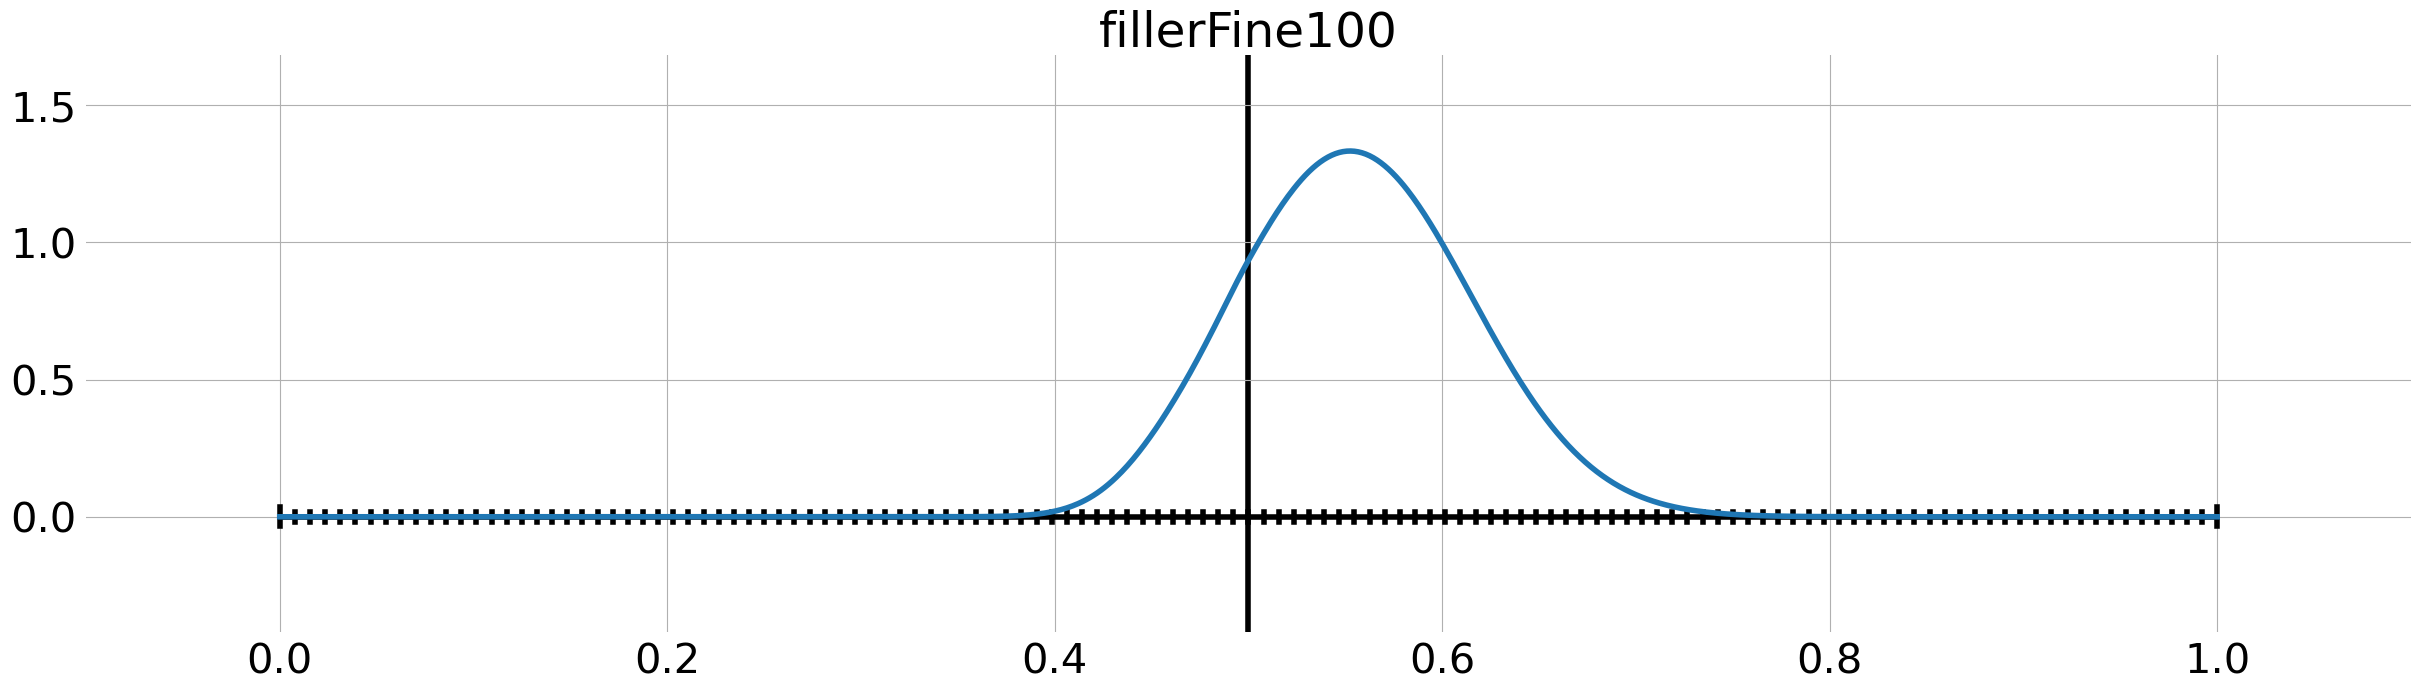

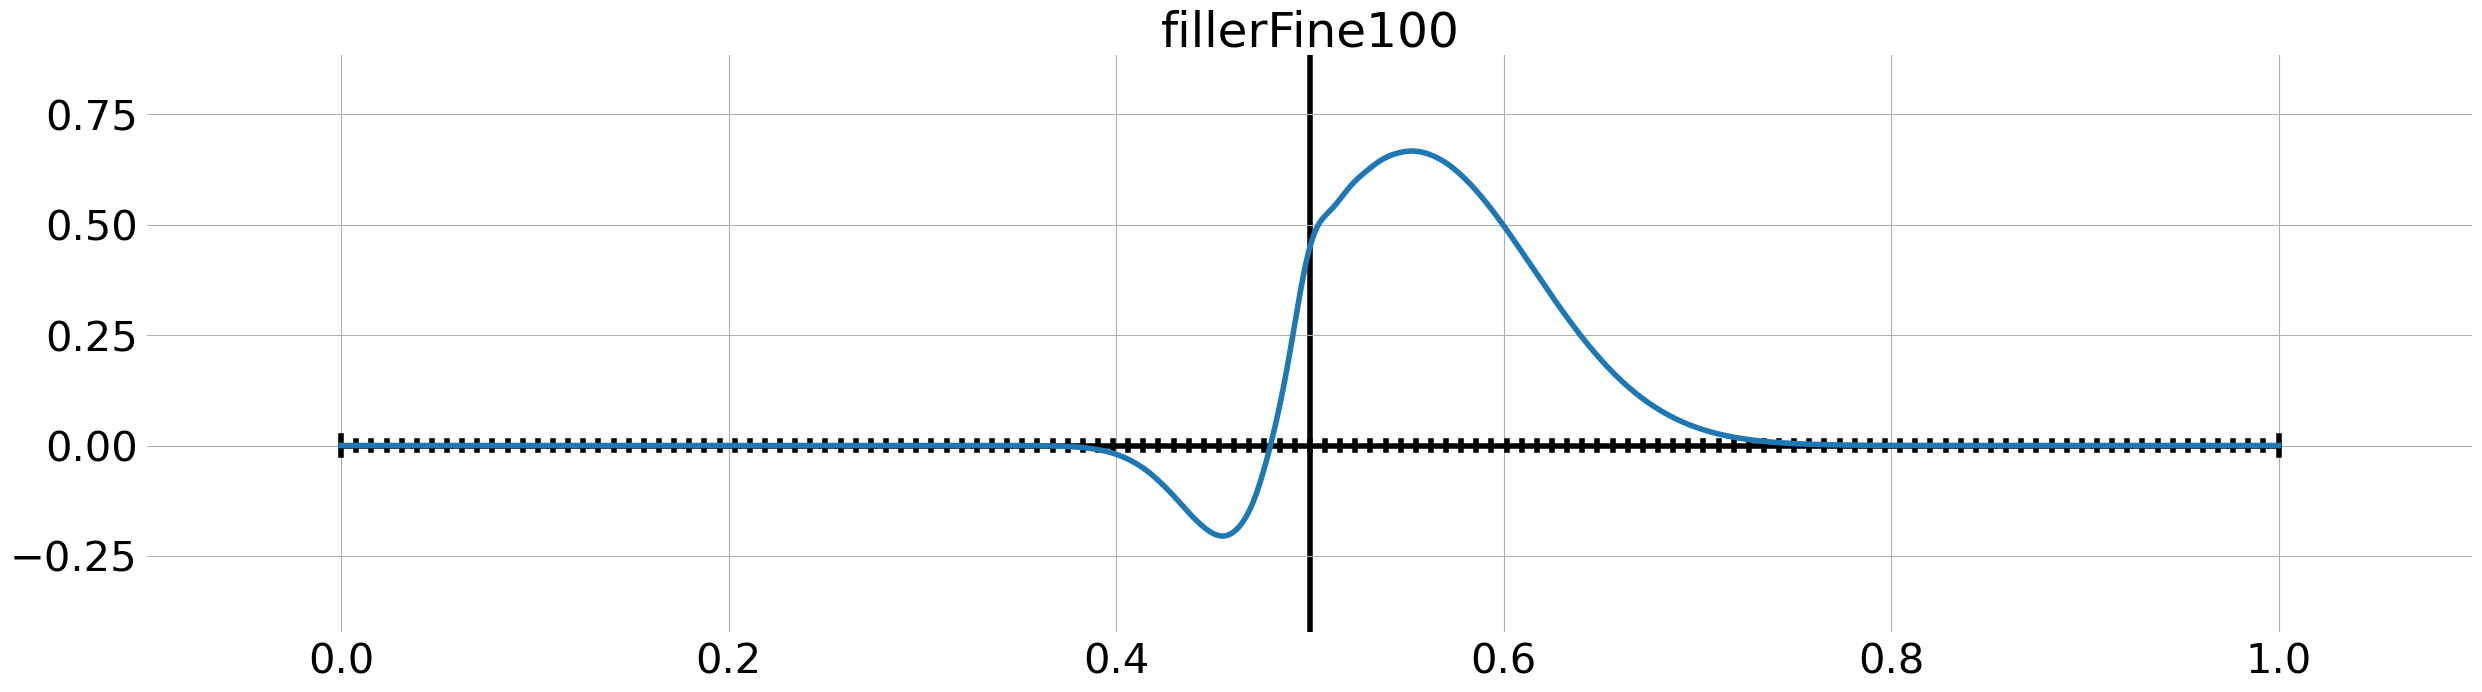

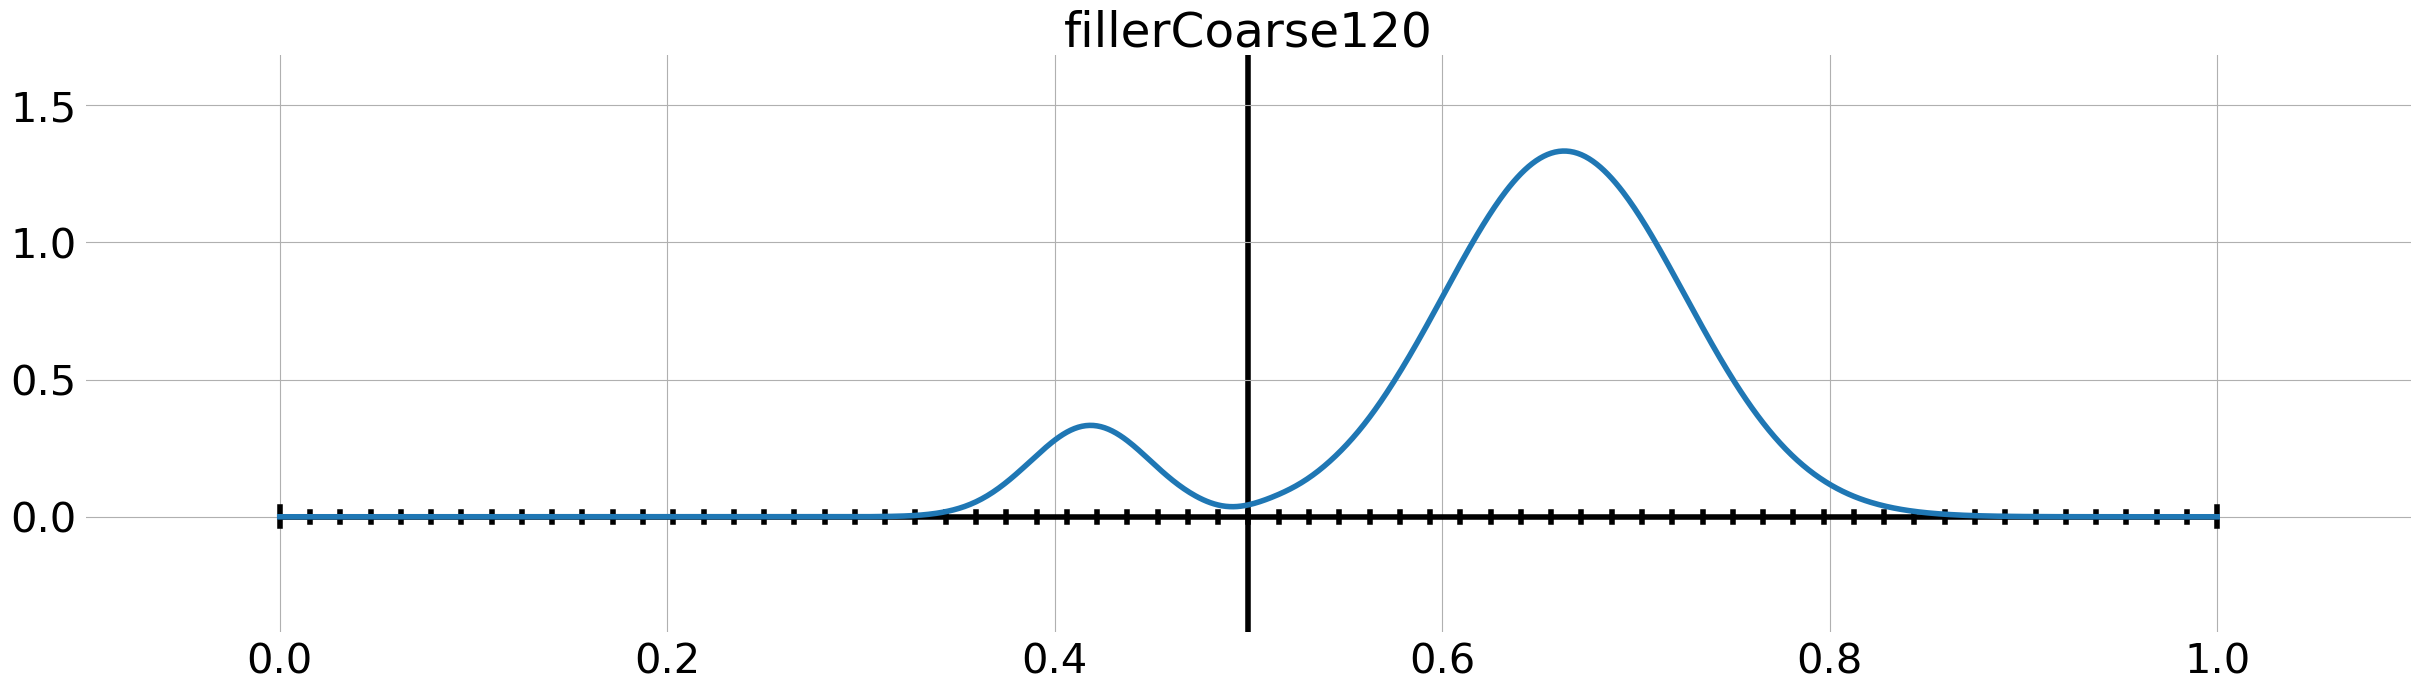

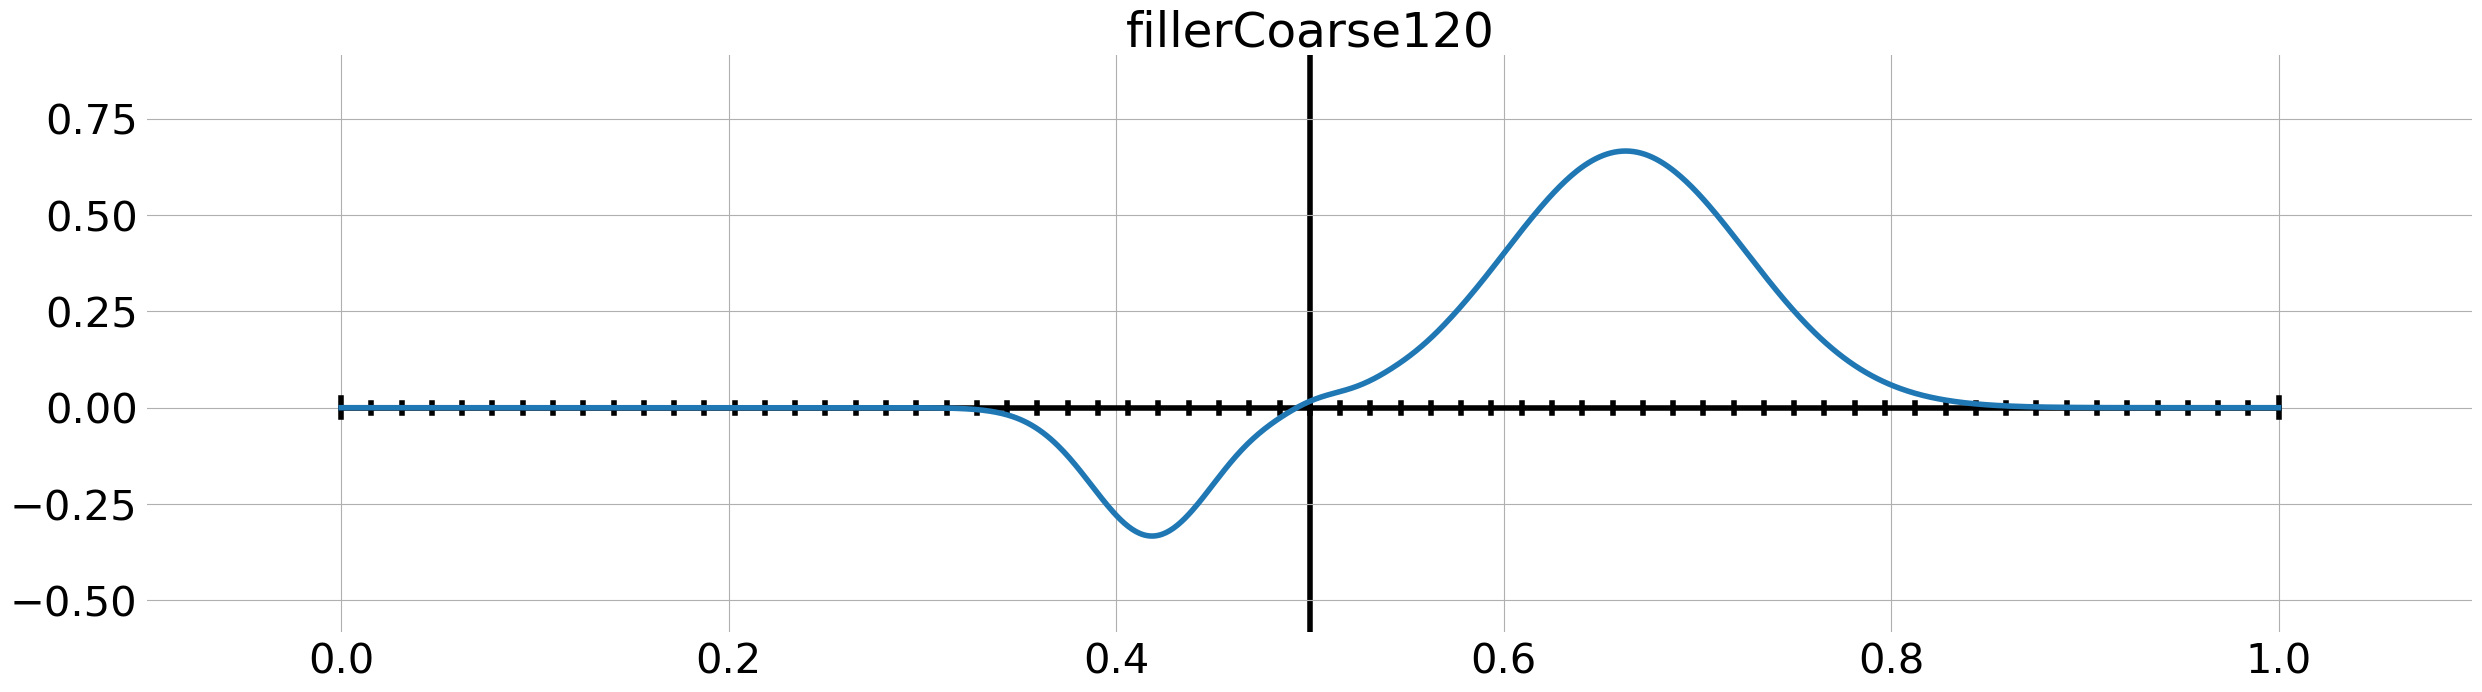

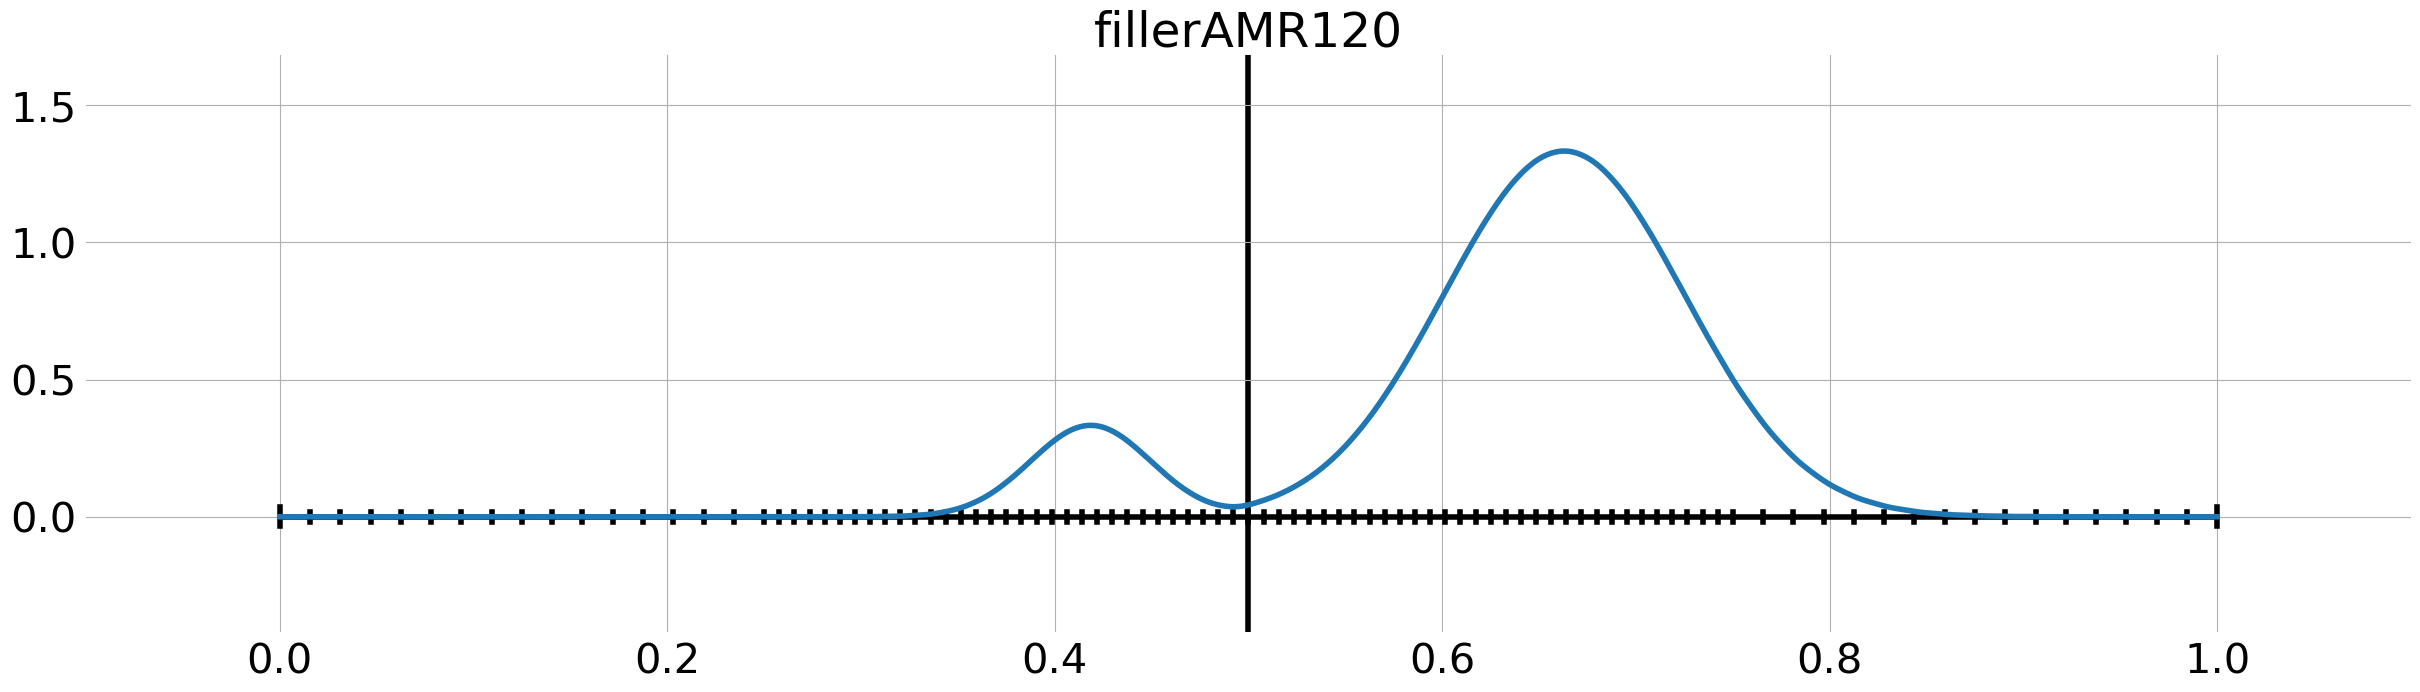

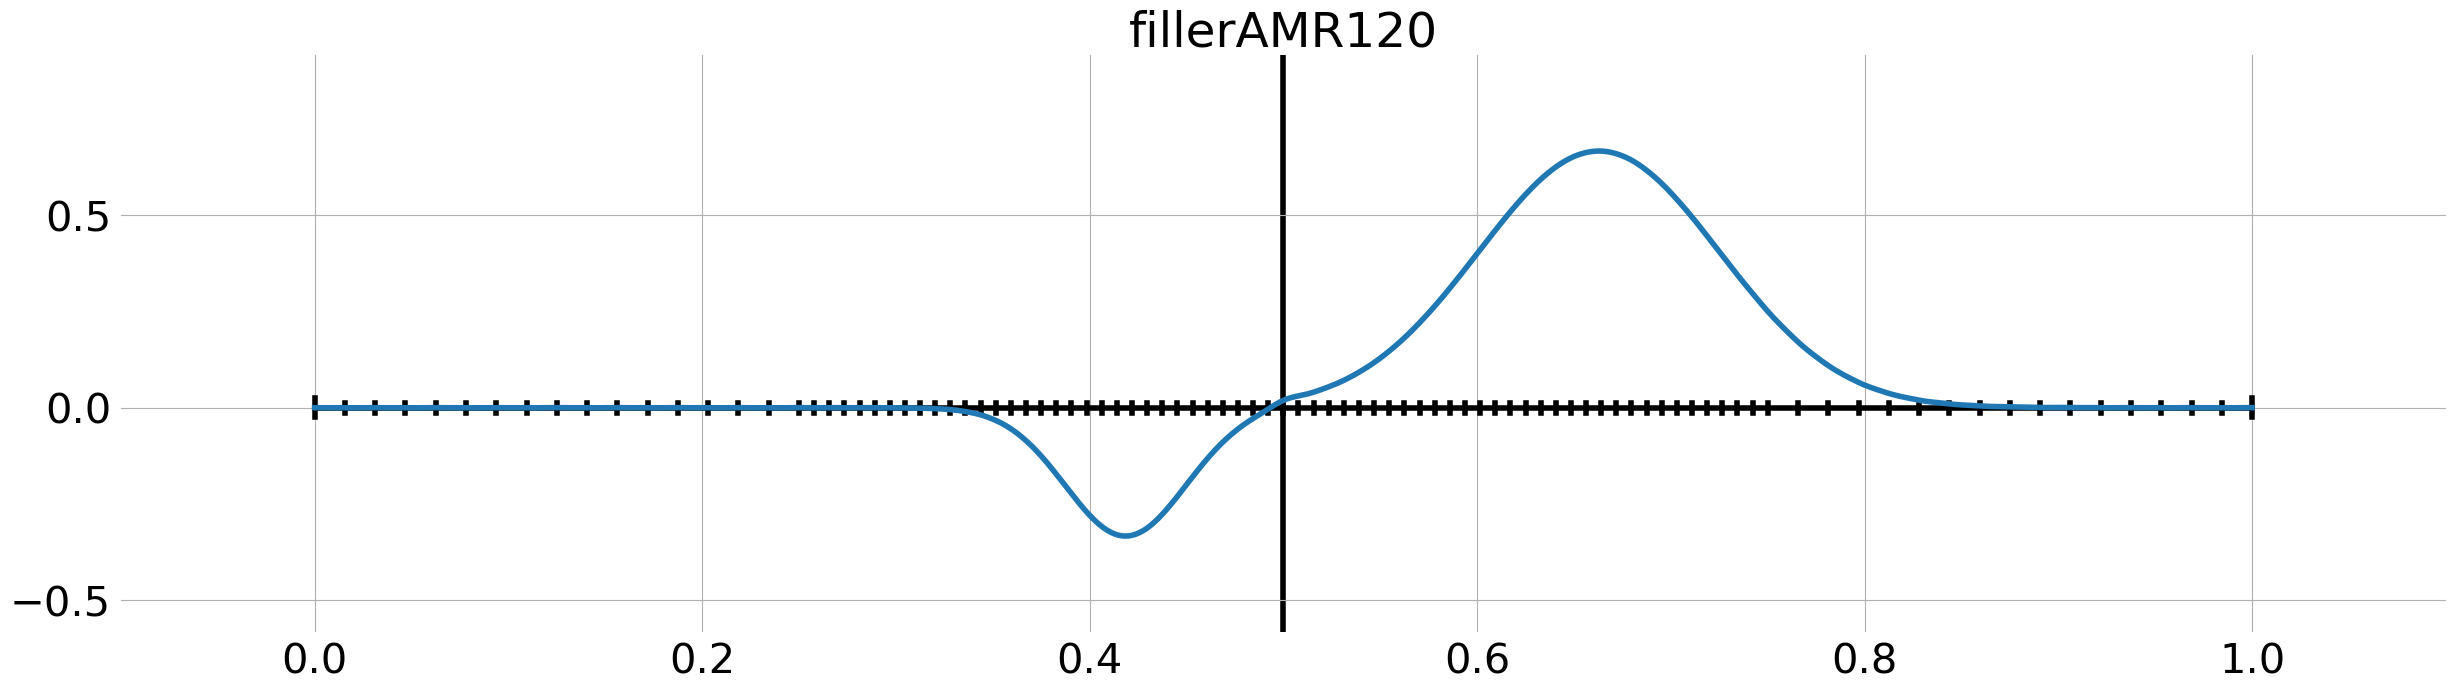

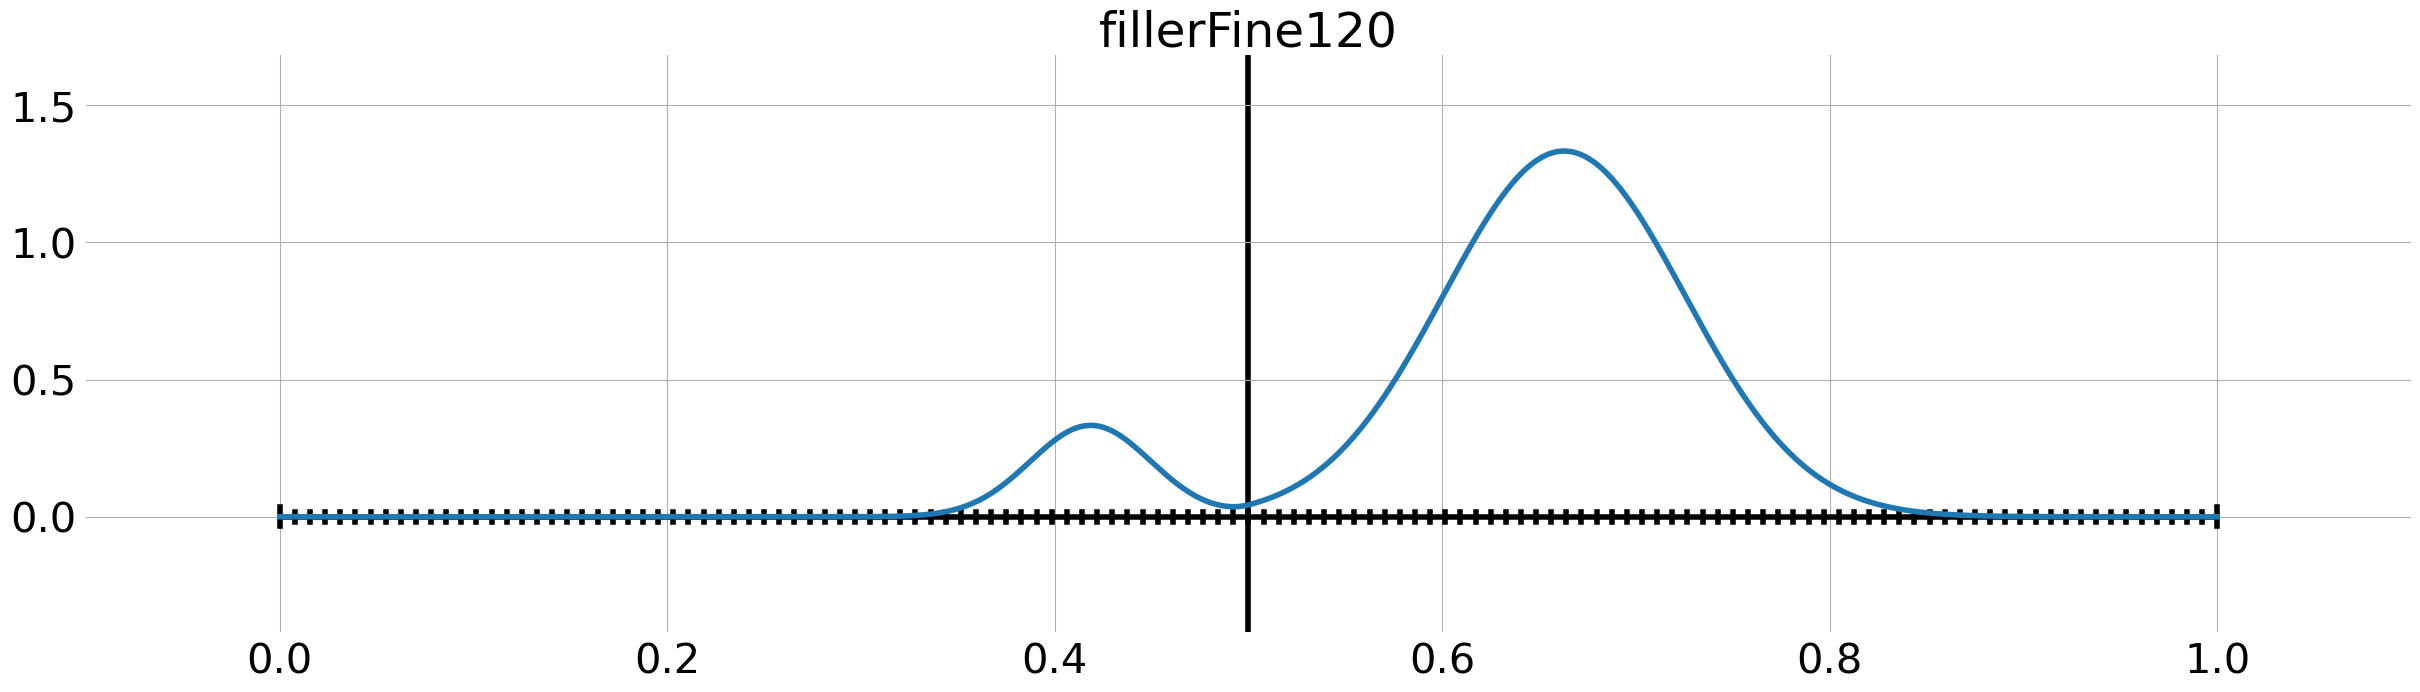

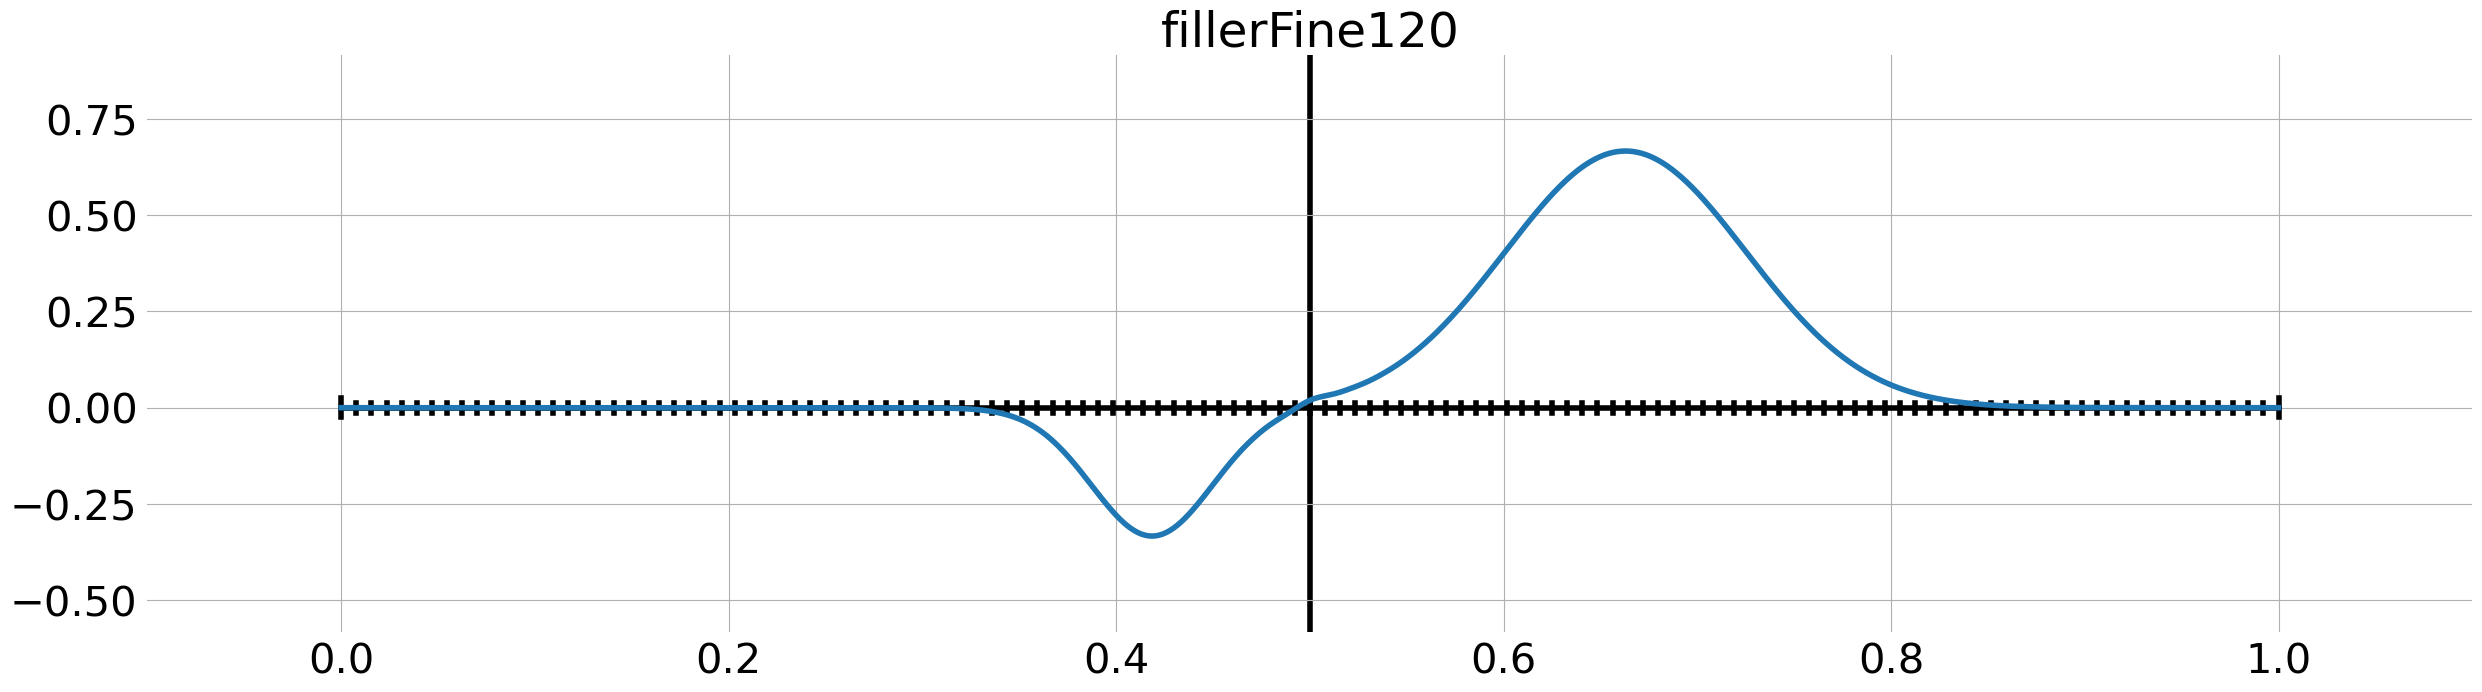

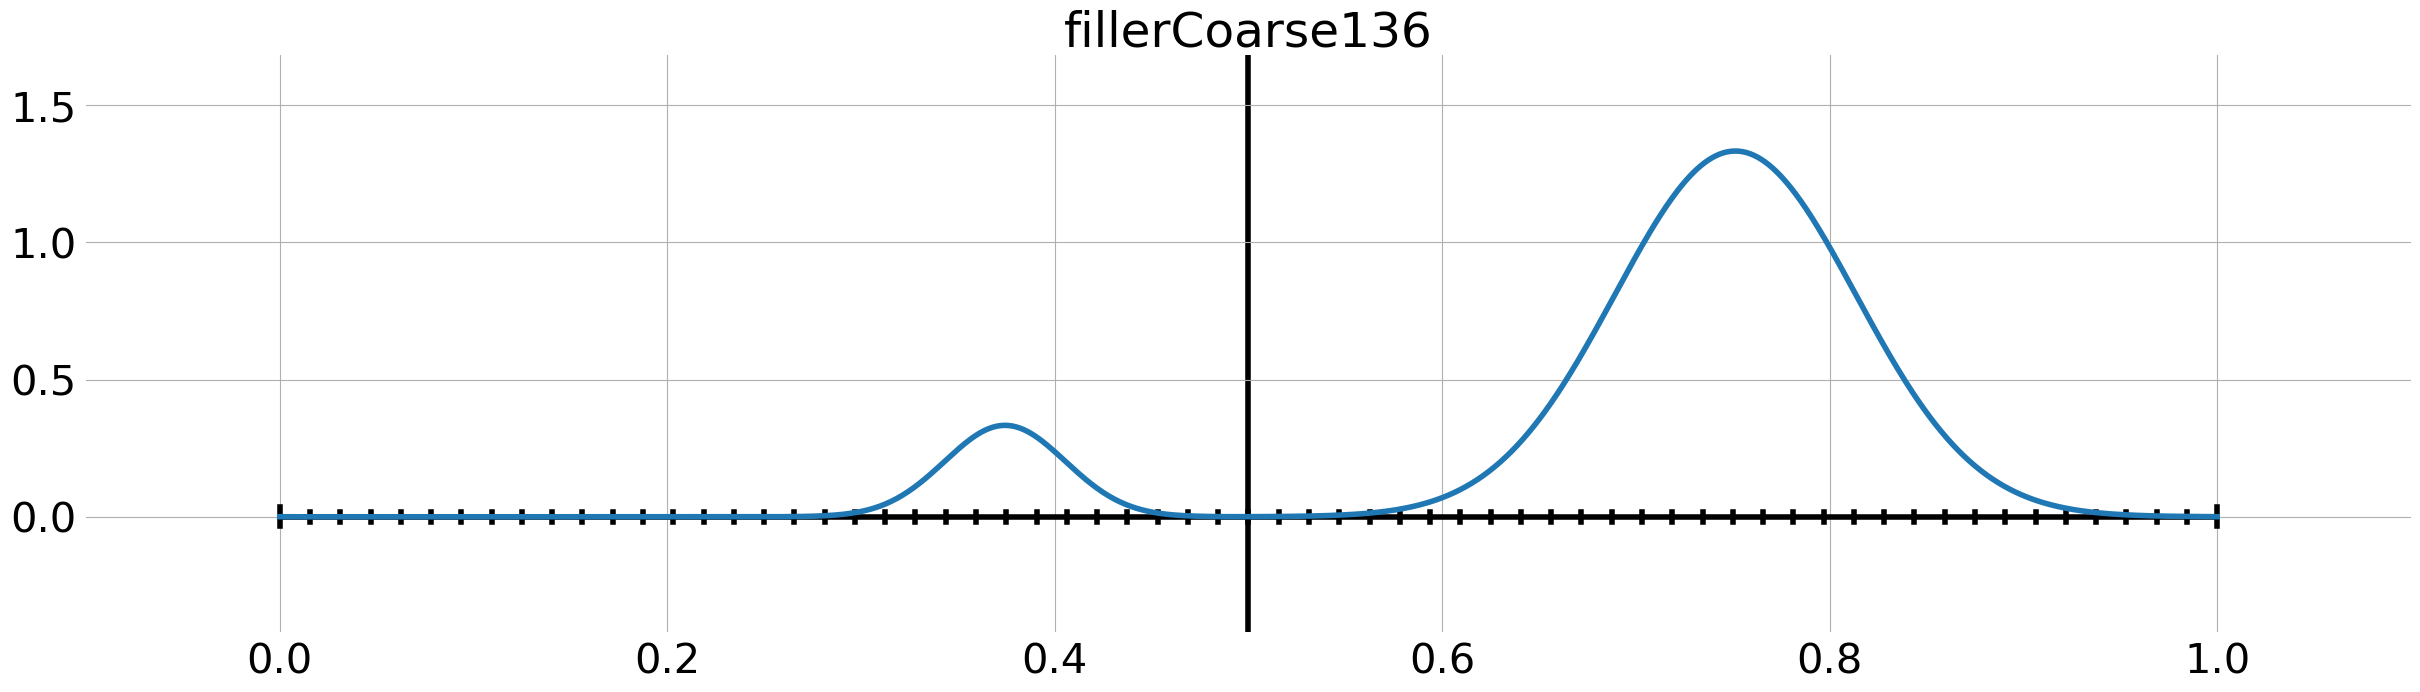

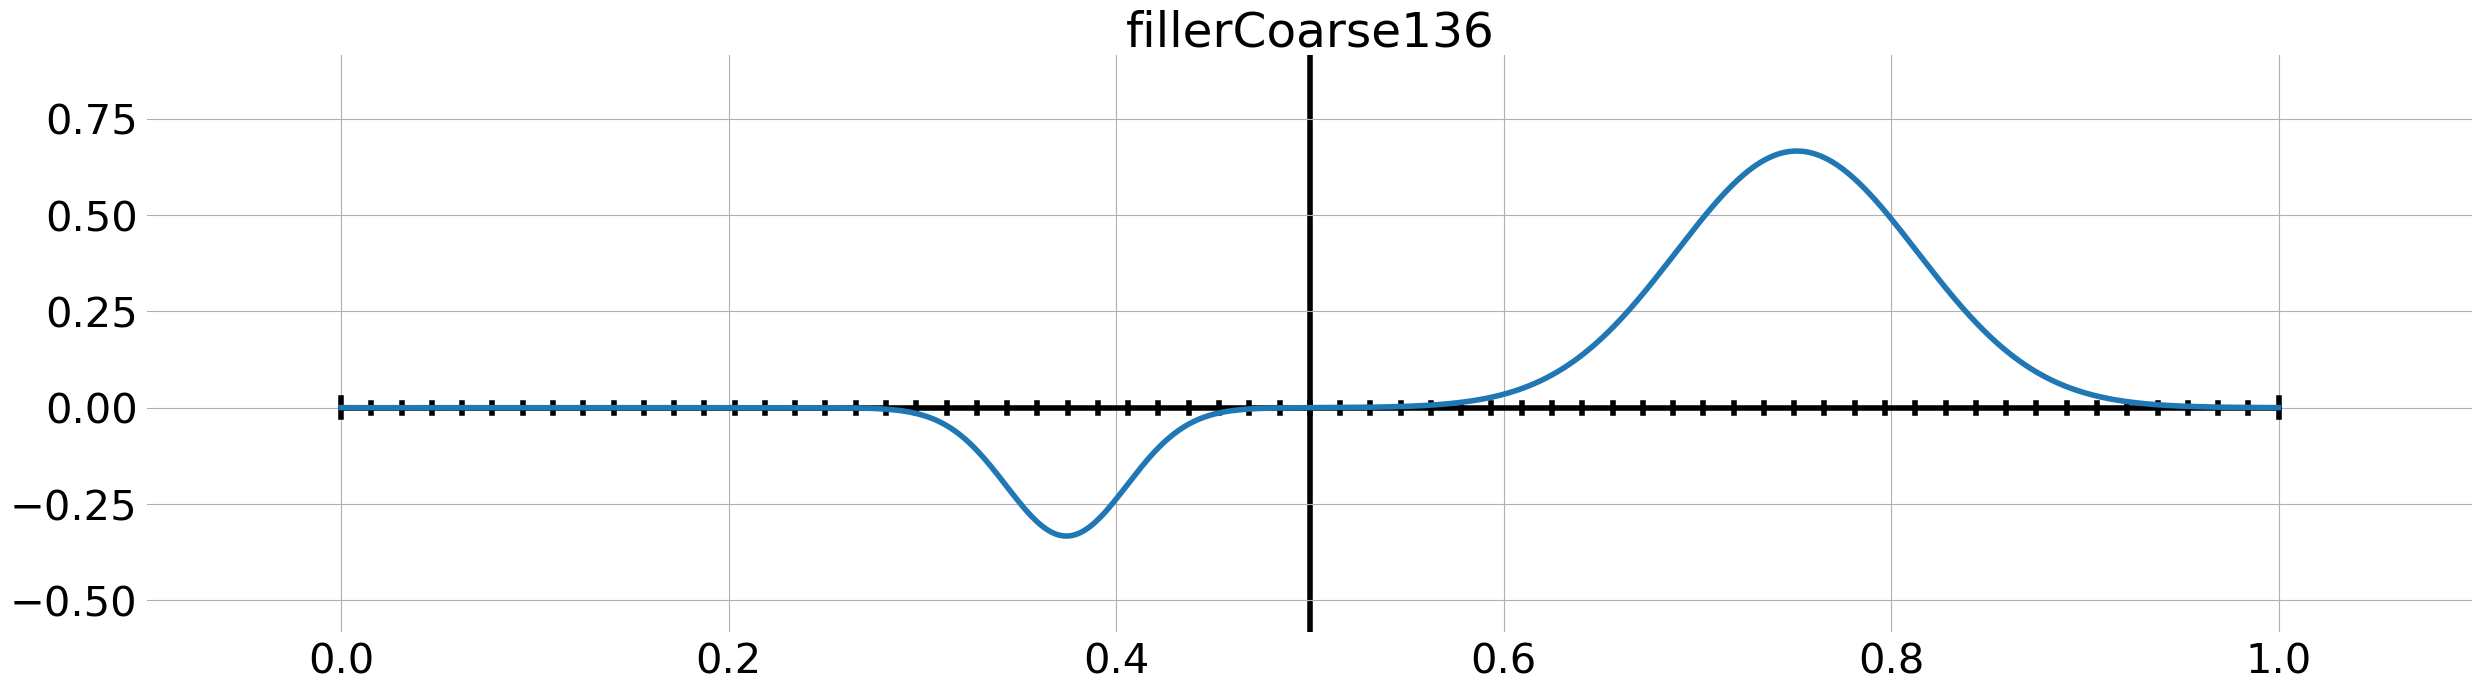

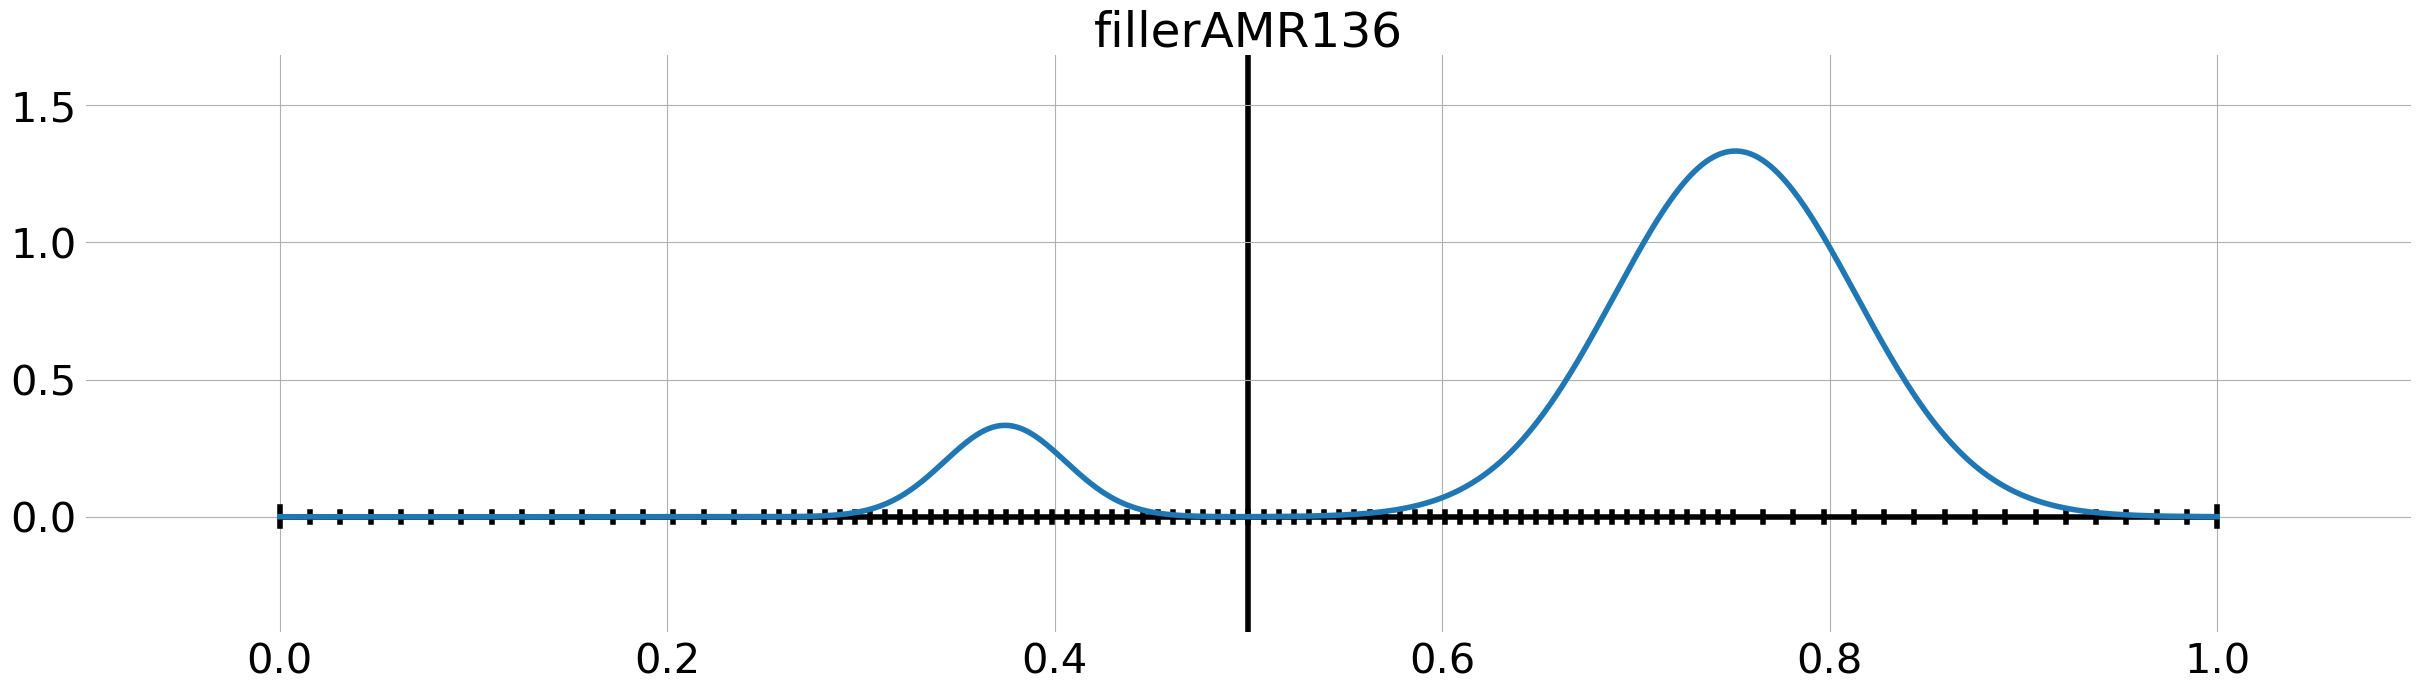

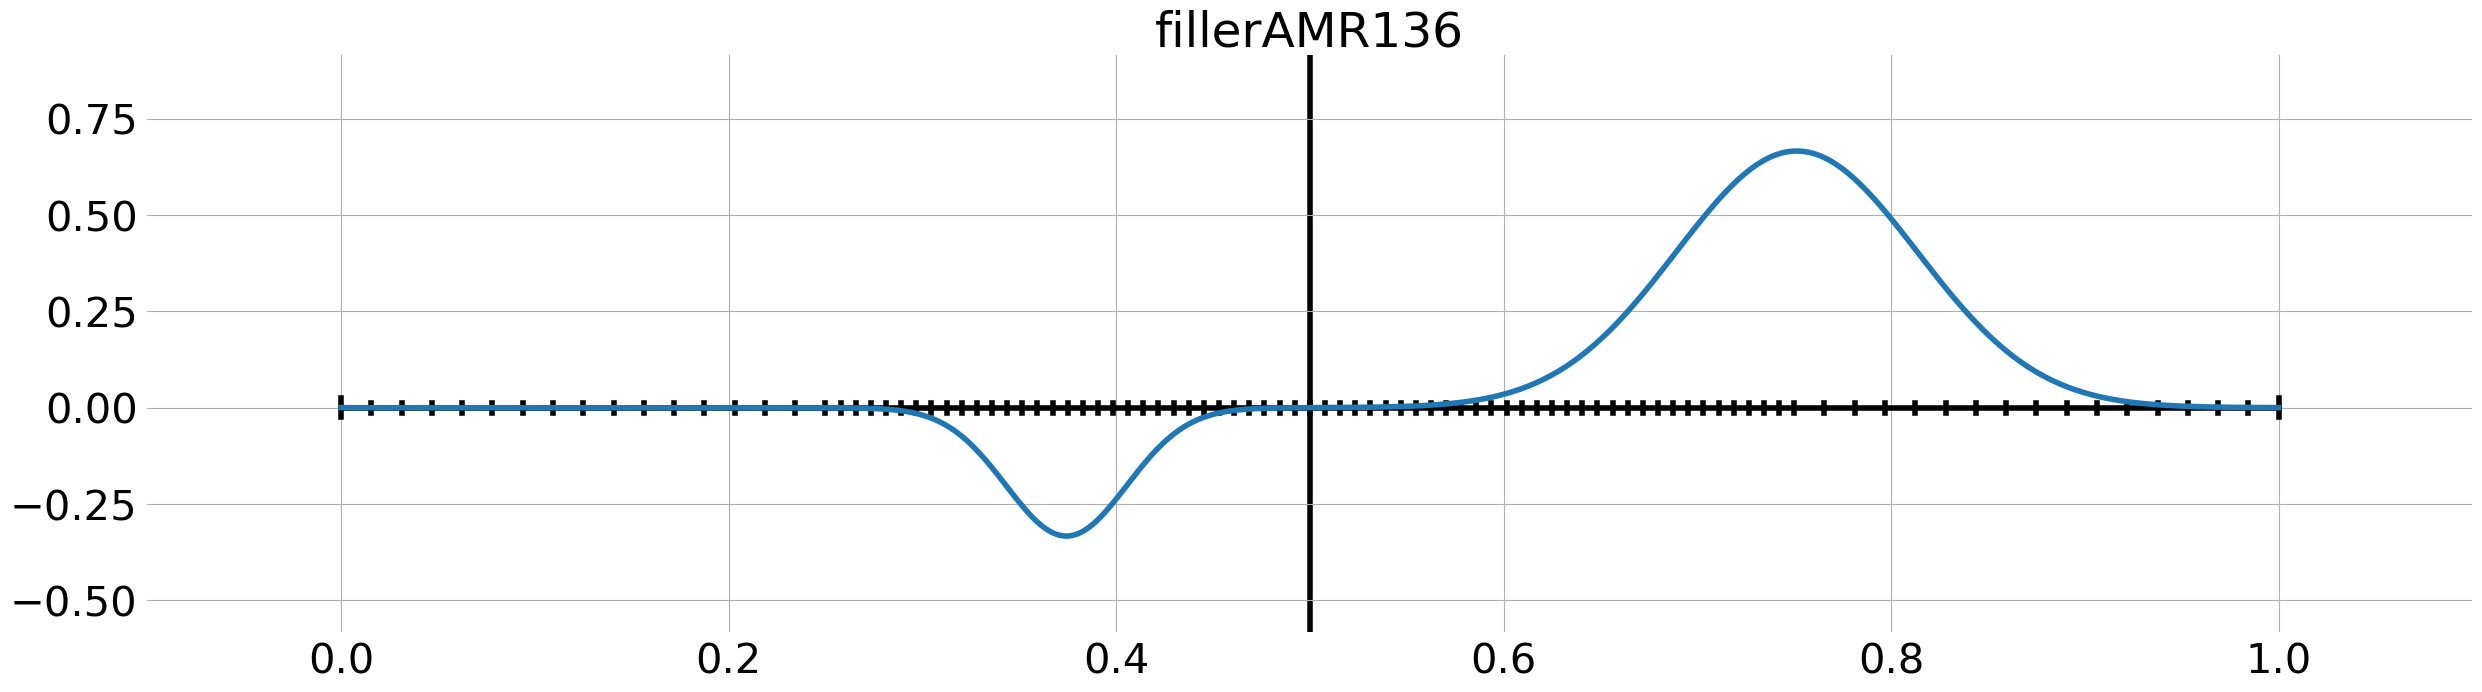

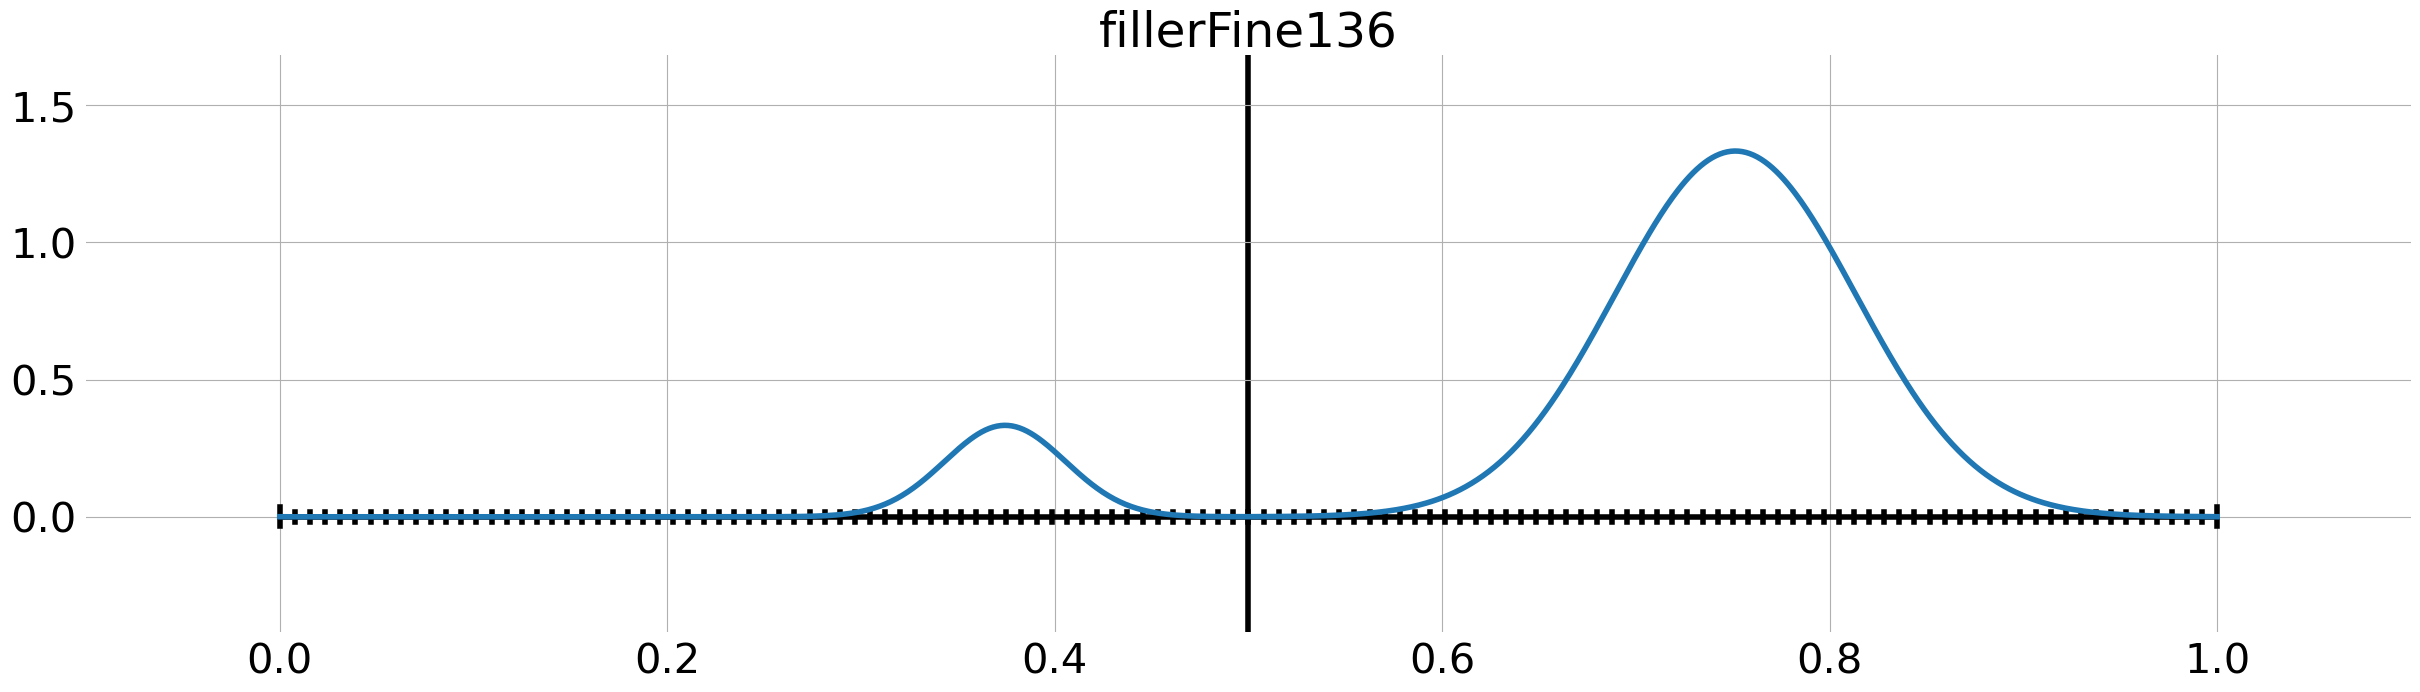

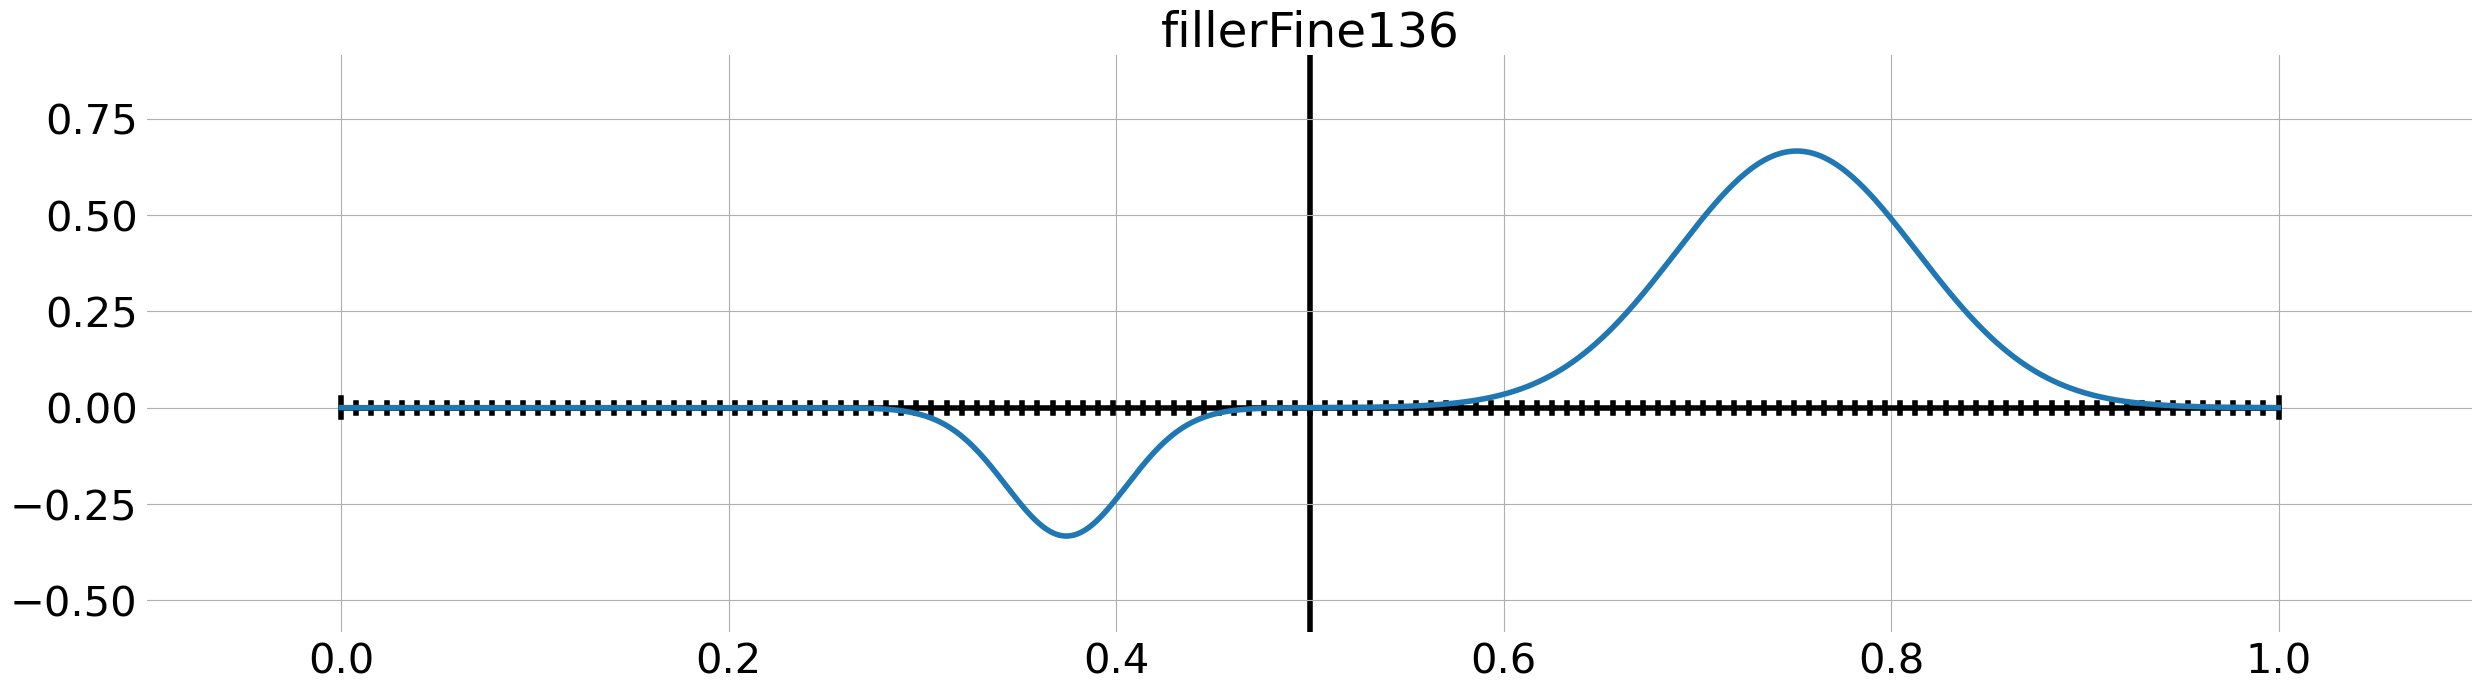

In [15]:
while (t <= t_f):
    t, nt = ST.CalcTime(omegaAMR, CFL, cMatAMR, nt = i)
#     t = (i * t_f) / (t_snaps - 1)
    print('BEFORE: t =', t)
    # Find initial waveform on coarse, fine, and AMR grids.
    waveInitC = wavesC @ FCoefsC
    waveInitF = wavesF @ FCoefsF
    waveInitAMR = restrictOp @ waveInitF

    # Find Fourier coefficients for initial condition on AMR grid.
    FCoefsAMR = FFTT.FourierCoefs(wavesAMR @ nullspace, waveInitAMR)

    wavePropC = WFT.WaveEq(omegaC, physicsC, WaveFunc, args, t, deriv = derivative, BooleAve = BooleAve, IRT = IRT, field = field)#FFTT.FourierCoefs(wavesC, wavePropC) # timePropOpC @ FCoefsC
    wavePropF = WFT.WaveEq(omegaF, physicsF, WaveFunc, args, t, deriv = derivative, BooleAve = BooleAve, IRT = IRT, field = field)

    # Find propagated coeficients on coarse and fine grid.
    FCoefsPropC = FFTT.FourierCoefs(wavesC, wavePropC) # FFTT.FourierCoefs(wavesC, wavePropC) # timePropOpC @ FCoefsC
    FCoefsPropF = FFTT.FourierCoefs(wavesF, wavePropF)

    # Find analytically propagated waveform on AMR grid.
    wavePropAMR = WFT.WaveEq(omegaAMR, physicsAMR, WaveFunc, args, t, deriv = derivative, BooleAve = BooleAve, IRT = IRT, field = field) # restrictOp @ wavesF @ FCoefsPropF

    # Find analytically propagated coefficients on AMR grid.
    FCoefsPropAMR = FFTT.FourierCoefs(wavesAMR @ nullspace, wavePropAMR)

    # Find numerically propagated coefficients on coarse, finea, and AMR grids.

    solverCoefsC = ST.RungeKutta(omegaC, physicsC, waveInitC, CFL, i, RK, order, deriv, ST.WaveEqRHS)
    solverCoefsF = ST.RungeKutta(omegaF, physicsF, waveInitF, CFL, i, RK, order, deriv, ST.WaveEqRHS)
    solverCoefsAMR = ST.RungeKutta(omegaAMR, physicsAMR, waveInitAMR, CFL, i, RK, order, deriv, ST.WaveEqRHS)

    solvPropC = wavesC @ solverCoefsC
    solvPropF = wavesF @ solverCoefsF
    solvPropAMF = wavesAMR @ nullspace @ solverCoefsAMR

    

    # TEST FOR EXACT GAUSSIAN AT NEW LOCATION.

    # Find theoretical propagated coefficients on coarse, fine, and AMR grid. (THIS CAN ONLY BE USED IF MATERIAL IS UNIFORM!)
    # FCoefsPropCTh = FFTT.PropRestrictWaves(omegaC, waveInitC, c * t)
    # FCoefsPropFTh = FFTT.PropRestrictWaves(omegaF, waveInitF, c * t)
    # FCoefsPropAMRTh = FFTT.PropRestrictWaves(omega, waveInitF, c * t)

    # solverCoefsC = ST.RungeKutta(omegaC, physicsC, wavesC, waveInitC, nt, CFL, RK, op = opC) # TimeIntegratorFunc(omegaC, wavesC, waveInitC, nt, cMatC, CFL, DiffFunc)
    # solverCoefsF = ST.RungeKutta(omegaF, physicsF, wavesF, waveInitF, nt, CFL, RK, op = opF) # TimeIntegratorFunc(omegaF, wavesF, waveInitF, nt, cMatF, CFL, DiffFunc)
    # solverCoefsAMR = ST.RungeKutta(omegaAMR, physicsAMR, wavesAMR @ nullspace, waveInitAMR, nt, CFL, RK, op = opAMR) # TimeIntegratorFunc(omegaAMR, wavesAMR @ nullspace, waveInitAMR, nt, cMat, CFL, DiffFunc, order = order)
    # solverCoefsC1 = np.asarray(np.append(solverCoefsC, solverCoefsC))

    # print('')
    # print(np.round(FCoefsPropCTh, 14))
    # print(np.round(FCoefsPropFTh, 14))
    # print(np.round(FCoefsPropAMRTh, 14))


    allCoefsC = FCoefsPropC#PT.Load(FCoefsC, FCoefsPropC)#, solverCoefsC)#, FCoefsPropCTh)
    allCoefsF = FCoefsPropF#PT.Load(FCoefsF, FCoefsPropF)#, solverCoefsF)#, FCoefsPropFTh)
    allCoefsAMR = nullspace @ FCoefsPropAMR#PT.Load(FCoefsAMR, FCoefsPropAMR)#, solverCoefsAMR)#, FCoefsPropAMRTh)


    # labels = ['Initial Wave', 'Method of Characteristics Propagated Wave']#, 'RK Propagated Wave']#, 'Rotation Matrix Propagated Wave']
    title = 'filler'
    if ((i % 20 == 0) or (t >= t_f)):
        # print('print t =', t)
        PT.PlotMixedWave(omegaC, physicsC, waves = [], FCoefs = allCoefsC, rescale = [6, 3], xGrid = True, yGrid = True, title = title + 'Coarse' + str(i), dpi = 400, plotCont = plotCont, enlarge = True)
        PT.PlotMixedWave(omegaAMR, physicsAMR, waves = [], FCoefs = allCoefsAMR, rescale = [6, 3], xGrid = True, yGrid = True, title = title + 'AMR' + str(i), dpi = 400, plotCont = plotCont, enlarge = True)#, labels = labels, title = 'AMR-Grid Mode Propagation', saveName = 'AMRHansMethod', dpi = 300)
        PT.PlotMixedWave(omegaF, physicsF, waves = [], FCoefs = allCoefsF, rescale = [6, 3], xGrid = True, yGrid = True, title = title + 'Fine' + str(i), dpi = 400, plotCont = plotCont, enlarge = True)#, labels = labels, title = 'Fine-Grid Mode Propagation', saveName = 'Fine', dpi = 300)
    
    
    EVecCAnal = np.append(EVecCAnal, 0.5 * sum(muepsC * wavePropC * wavePropC * hC))
    EVecFAnal = np.append(EVecFAnal, 0.5 * sum(muepsF * wavePropF * wavePropF * hF))
    EVecAMRAnal = np.append(EVecAMRAnal, 0.5 * sum(muepsAMR * wavePropAMR * wavePropAMR * hAMR))
    EVecCSolv = np.append(EVecCSolv, 0.5 * sum(muepsC * wavePropC * wavePropC * hC))
    EVecFSolv = np.append(EVecFSolv, 0.5 * sum(muepsF * wavePropF * wavePropF * hF))
    EVecAMRSolv = np.append(EVecAMRSolv, 0.5 * sum(muepsAMR * wavePropAMR * wavePropAMR * hAMR))
    ntVec = np.append(ntVec, i)
    # print('Energy Coarse:', EVecC)
    # print('Energy AMR:', EVecAMR)
    # print('Energy Fine:', EVecF)
    print('AFTER: t =', t)
    
    print('')
    i = i + 1
EVecCAnal = np.asarray(EVecCAnal)
EVecFAnal = np.asarray(EVecFAnal)
EVecAMRAnal = np.asarray(EVecAMRAnal)
EVecCSolv = np.asarray(EVecCSolv)
EVecFSolv = np.asarray(EVecFSolv)
EVecAMRSolv = np.asarray(EVecAMRSolv)
ntVec = np.asarray(ntVec)


In [16]:
coarse = True

energy = epsilons[0] * sigma * (np.pi**0.5) * np.ones(i, float)

dt = t / nt
print(t_f, t)
print(i, nt, len(EVecFSolv))


peakCrossing = 0.25 / (c1 * dt)

EDiffCAnal = abs(EVecCAnal - energy)
EDiffFAnal = abs(EVecFAnal - energy)
EDiffAMRAnal = abs(EVecAMRAnal - energy)

EDiffFAbs = abs(EVecFSolv - energy)
EDiffAMRAbs = abs(EVecAMRSolv - energy)

EDiffFRel = abs(EVecFSolv - EVecFAnal)
EDiffAMRRel = abs(EVecAMRSolv - EVecFAnal)

minY = np.min(EDiffCAnal)
print(minY)
maxY = np.max(EDiffCAnal)

if (minY > np.min(EDiffFAnal)):
    minY = np.min(EDiffFAnal)
if (minY > np.min(EDiffAMRAnal)):
    minY = np.min(EDiffAMRAnal)

if (maxY < np.max(EDiffFAnal)):
    maxY = np.max(EDiffFAnal)
if (maxY < np.max(EDiffAMRAnal)):
    maxY = np.max(EDiffAMRAnal)

vertX = np.asarray([peakCrossing, peakCrossing])
vertY = np.asarray([0, maxY])
print(peakCrossing, vertX, vertY)

0.375 0.3756504775053534
137 136 137
0.00019182709213639432
90.50966799187808 [90.50966799187808 90.50966799187808] [0.                    0.0005718851045538945]


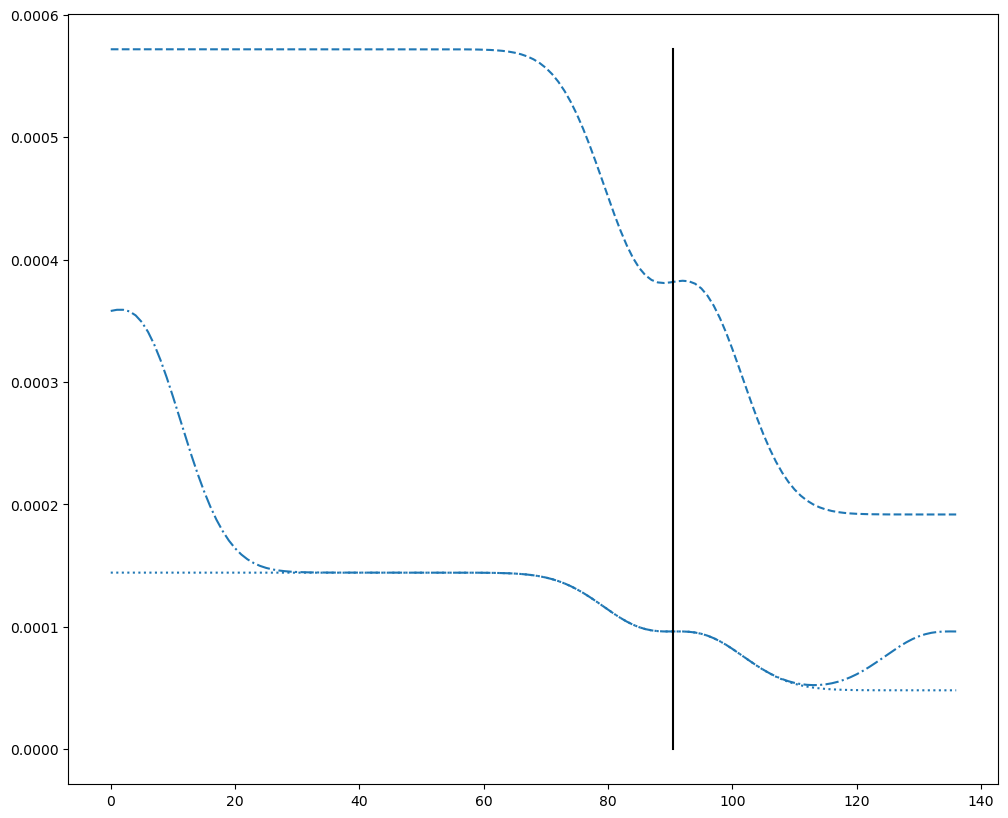

In [17]:
fig, ax = plt.subplots(figsize = [12, 10])
plt.plot(ntVec, EDiffCAnal, color = PT.ColorDefault(0), linestyle = '--', zorder = 0)
plt.plot(ntVec, EDiffAMRAnal, color = PT.ColorDefault(0), linestyle = '-.', zorder = 1)
plt.plot(ntVec, EDiffFAnal, color = PT.ColorDefault(0), linestyle = ':', zorder = 0)
plt.plot(vertX, vertY, color = PT.ColorDefault(0.5), linestyle = '-')
# plt.yscale('log')
plt.show()

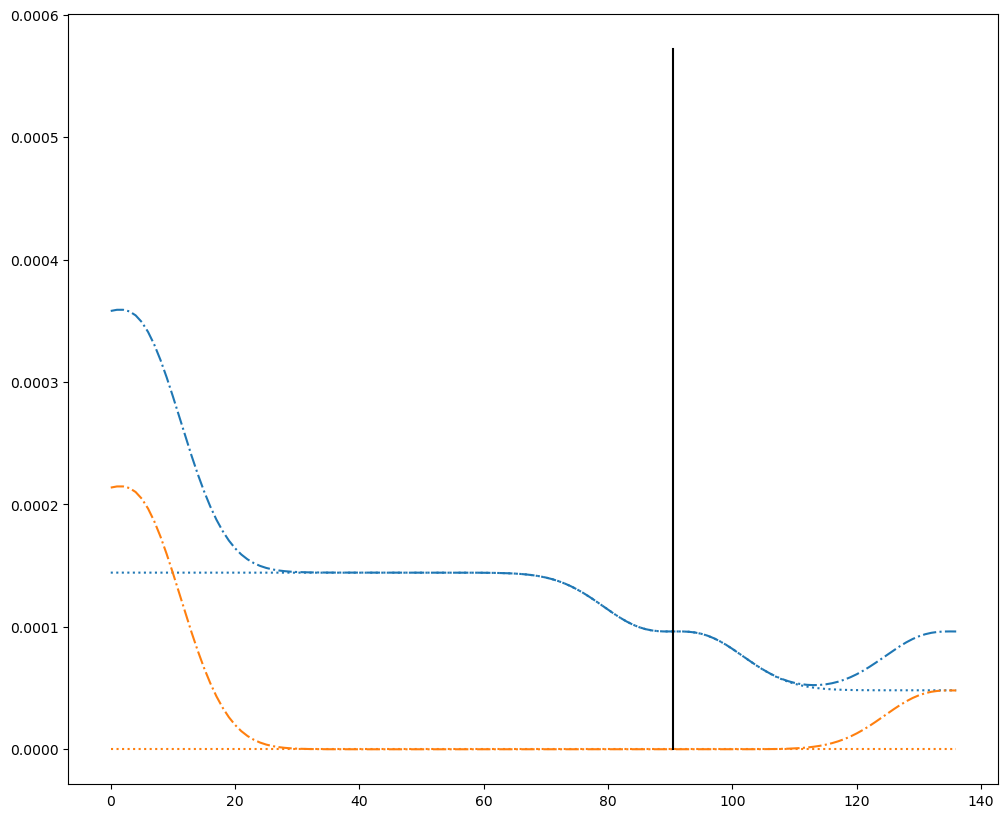

In [18]:
fig, ax = plt.subplots(figsize = [12, 10])
plt.plot(ntVec, EDiffAMRAbs, color = PT.ColorDefault(0), linestyle = '-.', zorder = 1)
plt.plot(ntVec, EDiffAMRRel, color = PT.ColorDefault(1), linestyle = '-.', zorder = 1)
plt.plot(ntVec, EDiffFAbs, color = PT.ColorDefault(0), linestyle = ':', zorder = 0)
plt.plot(ntVec, EDiffFRel, color = PT.ColorDefault(1), linestyle = ':', zorder = 0)
plt.plot(vertX, vertY, color = PT.ColorDefault(0.5), linestyle = '-')
# plt.yscale('log')
plt.show()

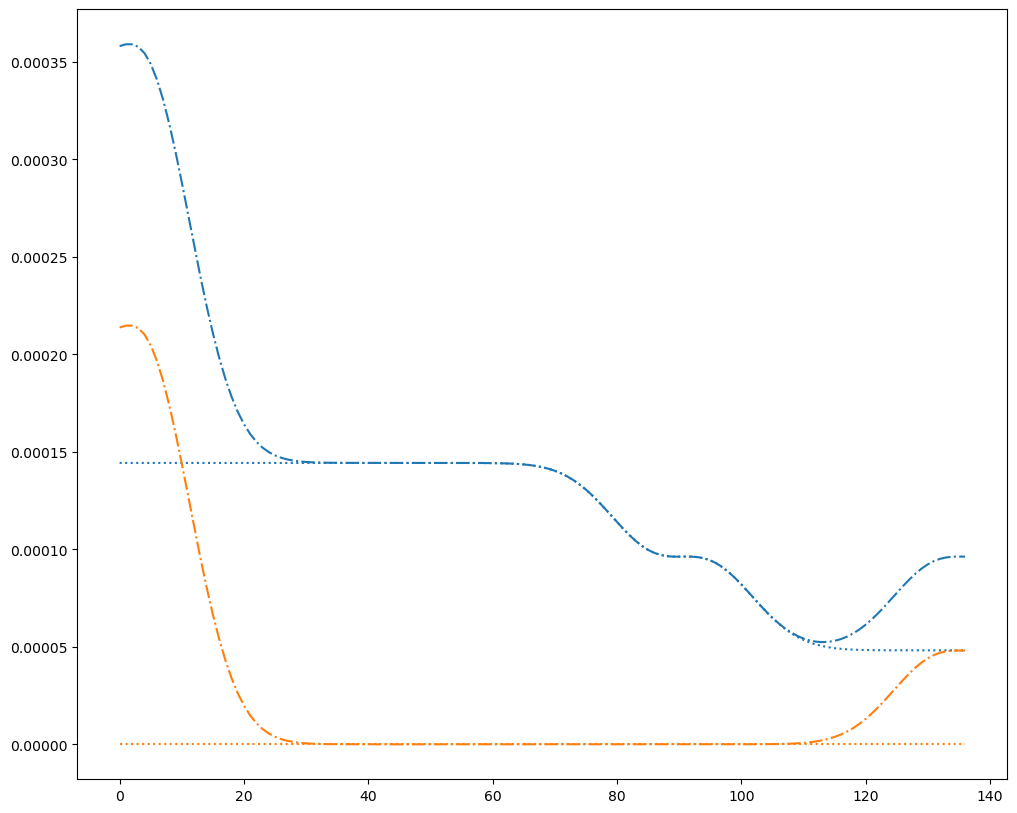

In [19]:
fig, ax = plt.subplots(figsize = [12, 10])
plt.plot(ntVec, EDiffAMRAbs, color = PT.ColorDefault(0), linestyle = '-.', zorder = 1)
plt.plot(ntVec, EDiffAMRRel, color = PT.ColorDefault(1), linestyle = '-.', zorder = 1)
plt.plot(ntVec, EDiffFAbs, color = PT.ColorDefault(0), linestyle = ':', zorder = 0)
plt.plot(ntVec, EDiffFRel, color = PT.ColorDefault(1), linestyle = ':', zorder = 0)
# plt.yscale('log')
plt.show()

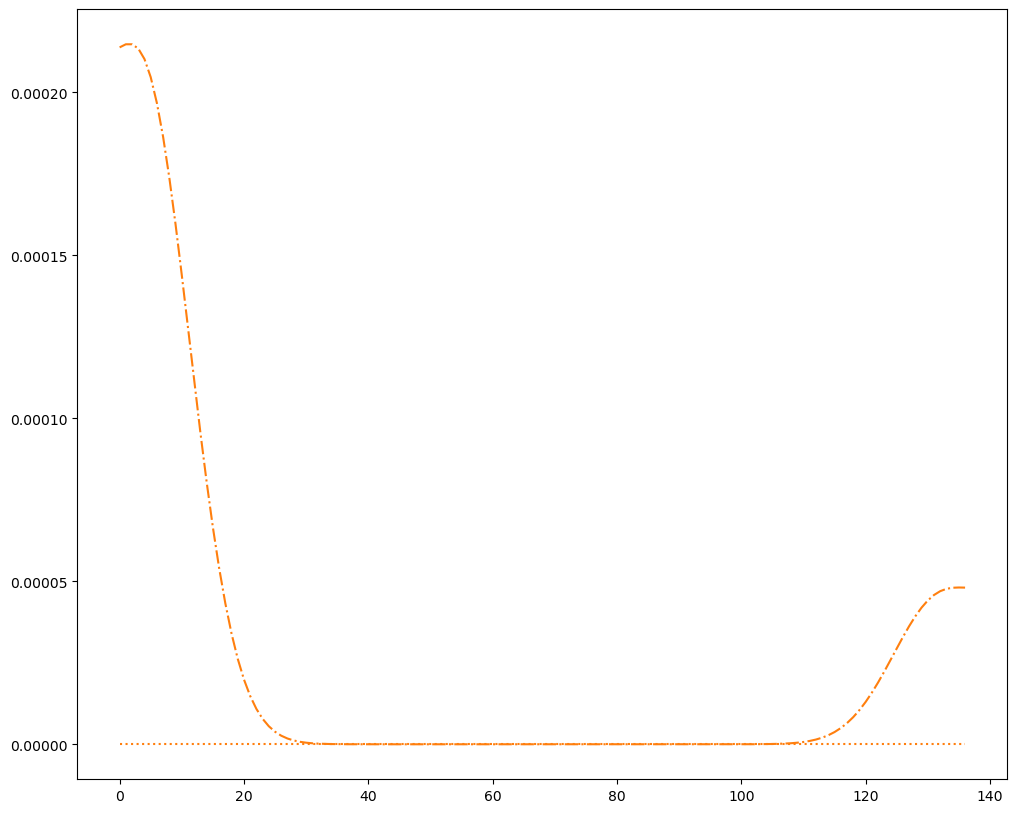

In [20]:
fig, ax = plt.subplots(figsize = [12, 10])
plt.plot(ntVec, EDiffAMRRel, color = PT.ColorDefault(1), linestyle = '-.', zorder = 1)
plt.plot(ntVec, EDiffFRel, color = PT.ColorDefault(1), linestyle = ':', zorder = 0)
# plt.yscale('log')
plt.show()

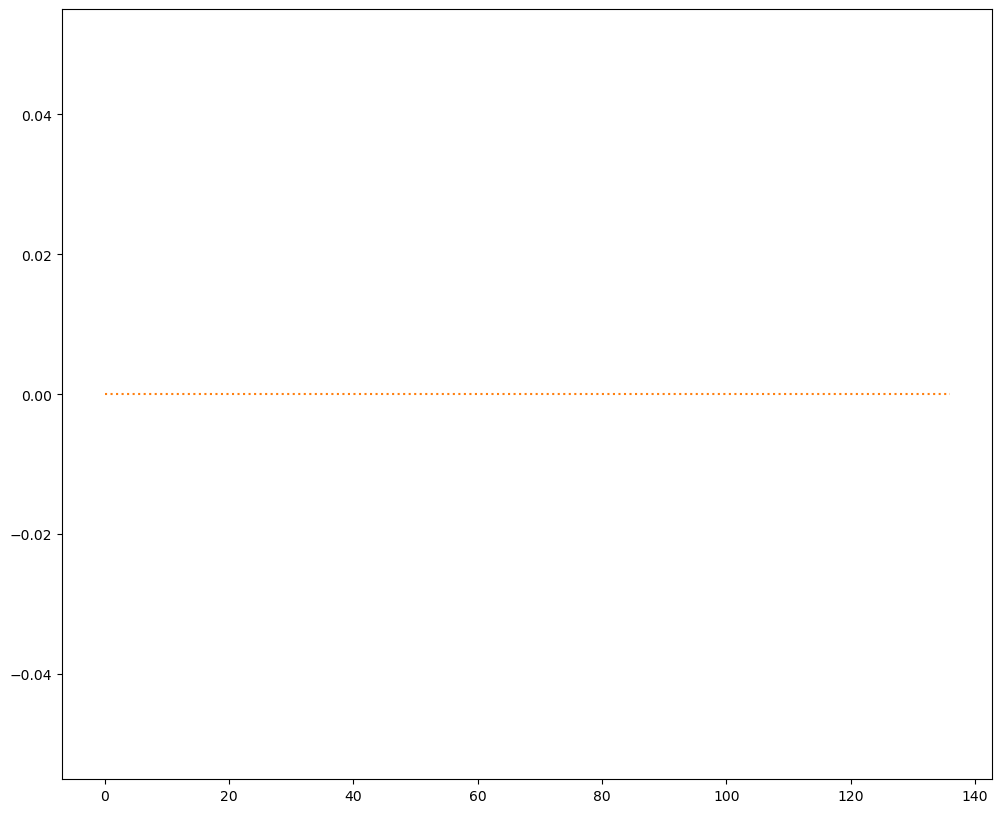

In [21]:
fig, ax = plt.subplots(figsize = [12, 10])
plt.plot(ntVec, EDiffFRel, color = PT.ColorDefault(1), linestyle = ':', zorder = 0)
# plt.yscale('log')
plt.show()

In [22]:
EDiffCAbs = abs(EVecCSolv - energy)
EDiffCRel = abs(EVecCSolv - EVecCAnal)

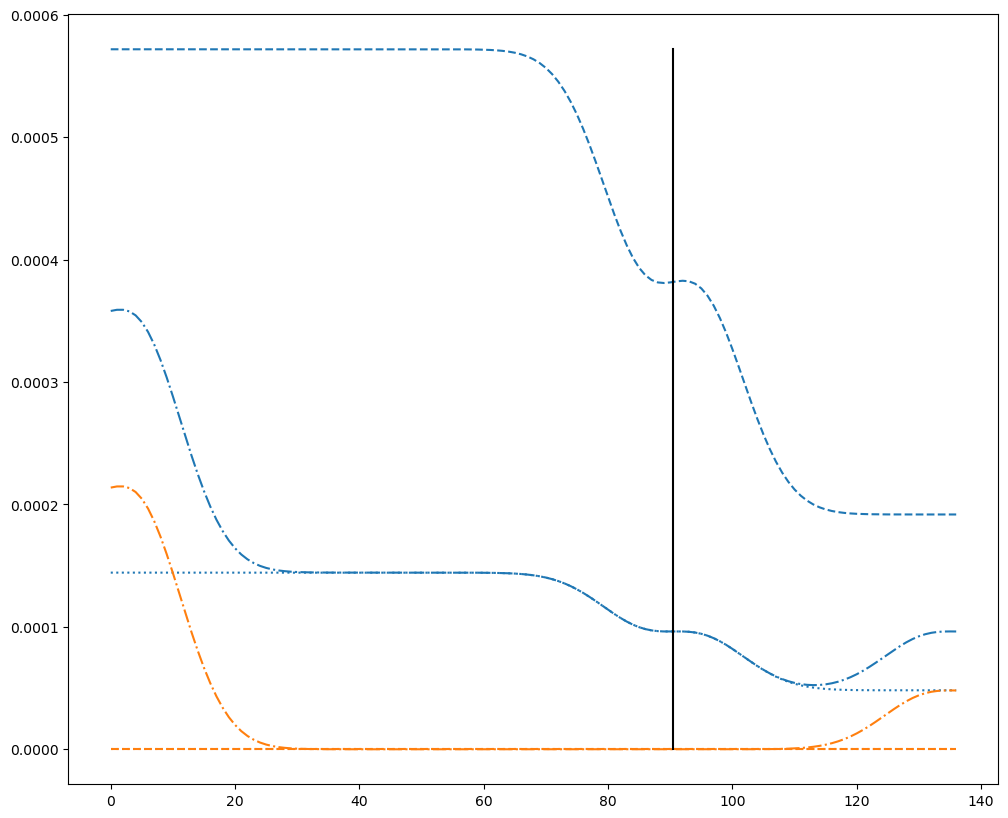

In [23]:
fig, ax = plt.subplots(figsize = [12, 10])
plt.plot(ntVec, EDiffCAbs, color = PT.ColorDefault(0), linestyle = '--', zorder = 0)
plt.plot(ntVec, EDiffCRel, color = PT.ColorDefault(1), linestyle = '--', zorder = 0)
plt.plot(ntVec, EDiffAMRAbs, color = PT.ColorDefault(0), linestyle = '-.', zorder = 1)
plt.plot(ntVec, EDiffAMRRel, color = PT.ColorDefault(1), linestyle = '-.', zorder = 1)
plt.plot(ntVec, EDiffFAbs, color = PT.ColorDefault(0), linestyle = ':', zorder = 0)
plt.plot(ntVec, EDiffFRel, color = PT.ColorDefault(1), linestyle = ':', zorder = 0)
plt.plot(vertX, vertY, color = PT.ColorDefault(0.5), linestyle = '-')
# plt.yscale('log')
plt.show()

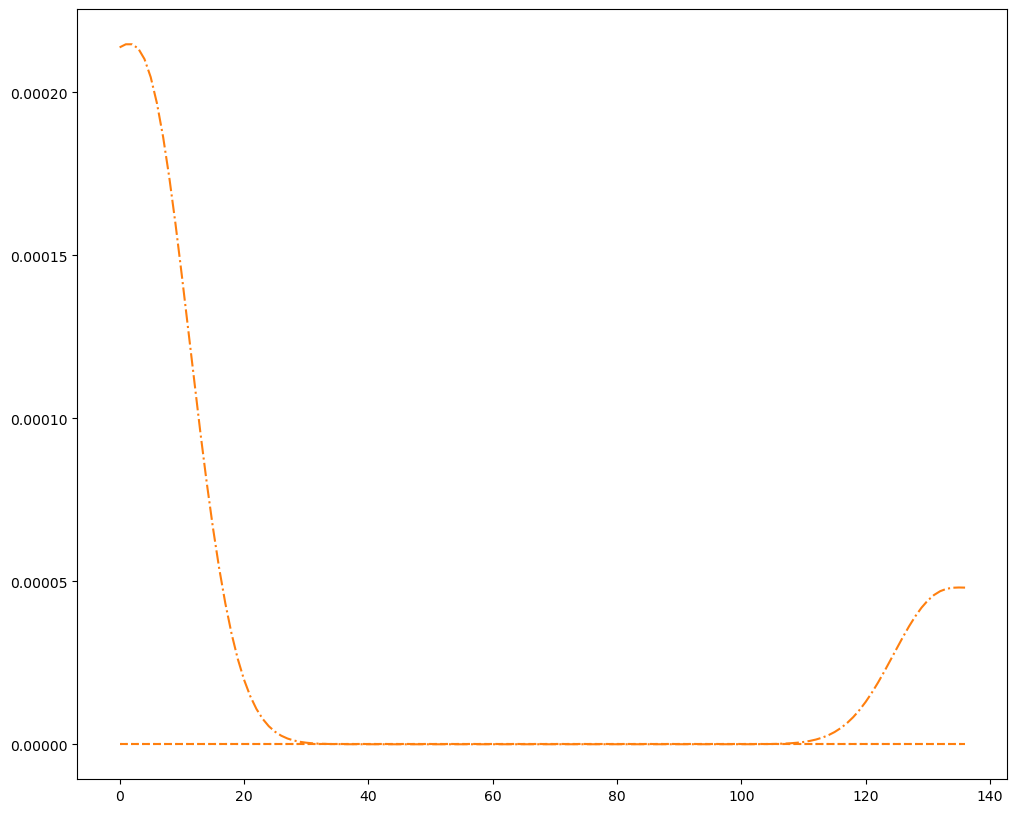

In [24]:
fig, ax = plt.subplots(figsize = [12, 10])
plt.plot(ntVec, EDiffAMRRel, color = PT.ColorDefault(1), linestyle = '-.', zorder = 1)
plt.plot(ntVec, EDiffCRel, color = PT.ColorDefault(1), linestyle = '--', zorder = 0)
plt.plot(ntVec, EDiffFRel, color = PT.ColorDefault(1), linestyle = ':', zorder = 0)
# plt.yscale('log')
plt.show()

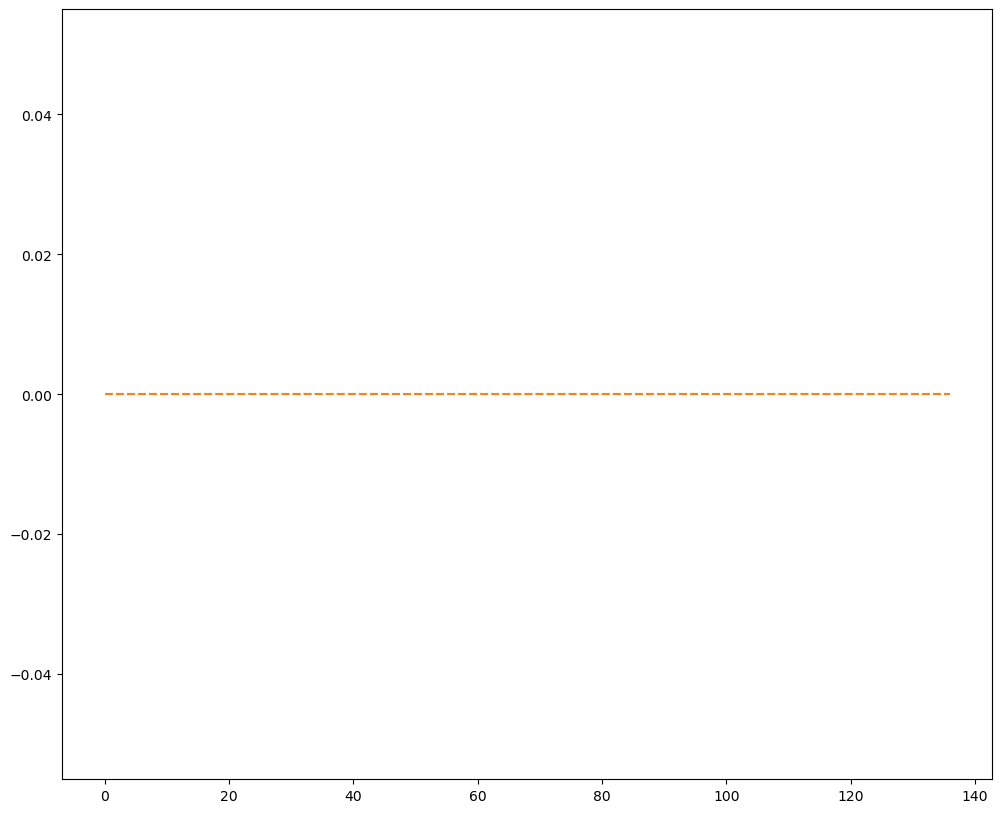

In [25]:
fig, ax = plt.subplots(figsize = [12, 10])
plt.plot(ntVec, EDiffCRel, color = PT.ColorDefault(1), linestyle = '--', zorder = 0)
plt.plot(ntVec, EDiffFRel, color = PT.ColorDefault(1), linestyle = ':', zorder = 0)
# plt.yscale('log')
plt.show()

In [54]:
print(EDiffCRel)
print(EDiffFRel)
print(EDiffAMRRel)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0.0002137827868835679      0.0002147339810312232      0.0002101939219156107      0.00019666403961069584     0.0001737419787078004      0.00014393132990853097     0.0001114097313671264      0.0000804438261027135      0.0000541514226537268      0.00003398323256340041     0.000019887073511679065    0.000010856746920556715    0.000005531519113380345    0.0000026314878161862176   0.000001169393039353317    0.0000004856247866336094   0.00000018853355682191264  0.00000006845058554694194  0.000000023249142666603717 0.000000007389357827014553 0.000000002198336603032036 0.000000000612

In [26]:
half = (i // 2) + 1

energy = energy[:half]
ntVec = ntVec[:half]

EVecCAnal = EVecCAnal[:half]
EVecCSolv = EVecCSolv[:half]
EVecFSolv = EVecFSolv[::2]
EVecAMRSolv = EVecAMRSolv[::2]

EDiffCAbs = abs(EVecCSolv - energy)
EDiffFAbs = EDiffFAbs[::2]
EDiffAMRAbs = EDiffAMRAbs[::2]

EDiffCRel = abs(EVecCSolv - EVecCAnal)
EDiffFRel = EDiffFRel[::2]
EDiffAMRRel = EDiffAMRRel[::2]



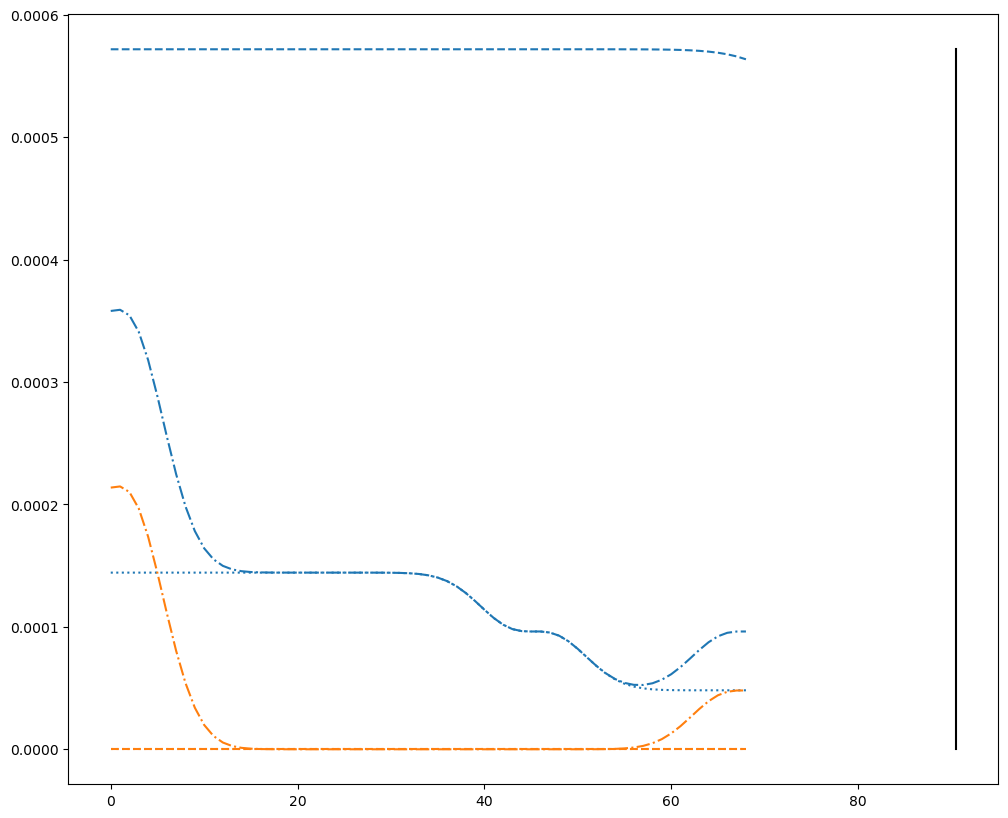

In [27]:
fig, ax = plt.subplots(figsize = [12, 10])
plt.plot(ntVec, EDiffCAbs, color = PT.ColorDefault(0), linestyle = '--', zorder = 0)
plt.plot(ntVec, EDiffCRel, color = PT.ColorDefault(1), linestyle = '--', zorder = 0)
plt.plot(ntVec, EDiffAMRAbs, color = PT.ColorDefault(0), linestyle = '-.', zorder = 1)
plt.plot(ntVec, EDiffAMRRel, color = PT.ColorDefault(1), linestyle = '-.', zorder = 1)
plt.plot(ntVec, EDiffFAbs, color = PT.ColorDefault(0), linestyle = ':', zorder = 0)
plt.plot(ntVec, EDiffFRel, color = PT.ColorDefault(1), linestyle = ':', zorder = 0)
plt.plot(vertX, vertY, color = PT.ColorDefault(0.5), linestyle = '-')
# plt.yscale('log')
plt.show()

In [28]:
X = []

for q in range(11):
    X = np.append(X, q)
half = (10 // 2) + 1
print(X)
print(X[::2])
print(X[:half])

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[ 0.  2.  4.  6.  8. 10.]
[0. 1. 2. 3. 4. 5.]


In [29]:
print(mu)

0.25
